In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io

# Google Sheet ID
sheet_id = "1o-25NB8GdPX07WEpnCoFNowdNw7ImsLnyuf9X2W0bPE"

# Worksheet / tab ID
gid = "2093870332"

# Create CSV export URL
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

# Load the Google Sheet into pandas using requests for better handling
try:
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for HTTP errors (4xx or 5xx)
    df = pd.read_csv(io.StringIO(response.text))
except requests.exceptions.RequestException as e:
    print(f"Error fetching data: {e}")
    print("Please ensure the Google Sheet is publicly accessible ('Anyone with the link can view').")
    df = pd.DataFrame() # Create an empty DataFrame to avoid further errors

# Display basic information
if not df.empty:
    print("IPL dataset loaded successfully!")
    print("Number of rows:", df.shape[0])
    print("Number of columns:", df.shape[1])

    # Display first 5 rows
    display(df.head())
else:
    print("Failed to load dataset.")

IPL dataset loaded successfully!
Number of rows: 1243
Number of columns: 31


,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
0,Indian Premier League,2008,1.0,18-04-2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,RE Koertzen,AM Saheba,VN Kulkarni,T20,20,6,male,club,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey..."
1,Indian Premier League,2008,2.0,19-04-2008,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,SL Shastri,RB Tiffin,MSS Ranawat,T20,20,6,male,club,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ..."
2,Indian Premier League,2008,3.0,19-04-2008,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,...,GA Pratapkumar,IL Howell,Unknown,T20,20,6,male,club,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm..."
3,Indian Premier League,2008,4.0,20-04-2008,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,...,K Hariharan,Asad Rauf,F Gomes,T20,20,6,male,club,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S..."
4,Indian Premier League,2008,5.0,20-04-2008,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,...,DJ Harper,AV Jayaprakash,SN Bandekar,T20,20,6,male,club,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli..."


In [ ]:
# ============================================
# STEP 2 — UNDERSTAND THE IPL DATASET
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\n" + "="*50)
print("COLUMN NAMES")
print("="*50)

for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\n" + "="*50)
print("DATA TYPES")
print("="*50)

print(df.dtypes)

print("\n" + "="*50)
print("FIRST 5 ROWS")
print("="*50)

display(df.head())

print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)

df.info()

Dataset Shape:
(1243, 31)

COLUMN NAMES
1. event_name
2. season
3. match_number
4. date
5. city
6. venue
7. team1
8. team2
9. toss_winner
10. toss_decision
11. team1_runs
12. team1_wickets
13. team2_runs
14. team2_wickets
15. winner
16. result_type
17. win_by_runs
18. win_by_wickets
19. player_of_match
20. match_referee
21. umpire1
22. umpire2
23. tv_umpire
24. reserve_umpire
25. match_type
26. overs_limit
27. balls_per_over
28. gender
29. team_type
30. team1_players
31. team2_players

DATA TYPES
event_name          object
season               int64
match_number       float64
date                object
city                object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
team1_runs           int64
team1_wickets        int64
team2_runs           int64
team2_wickets        int64
winner              object
result_type         object
win_by_runs          int64
win_by_wickets       int64
player_of_ma

,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
0,Indian Premier League,2008,1.0,18-04-2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,RE Koertzen,AM Saheba,VN Kulkarni,T20,20,6,male,club,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey..."
1,Indian Premier League,2008,2.0,19-04-2008,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,SL Shastri,RB Tiffin,MSS Ranawat,T20,20,6,male,club,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ..."
2,Indian Premier League,2008,3.0,19-04-2008,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,...,GA Pratapkumar,IL Howell,Unknown,T20,20,6,male,club,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm..."
3,Indian Premier League,2008,4.0,20-04-2008,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,...,K Hariharan,Asad Rauf,F Gomes,T20,20,6,male,club,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S..."
4,Indian Premier League,2008,5.0,20-04-2008,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,...,DJ Harper,AV Jayaprakash,SN Bandekar,T20,20,6,male,club,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli..."



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_name       1243 non-null   object 
 1   season           1243 non-null   int64  
 2   match_number     1169 non-null   float64
 3   date             1243 non-null   object 
 4   city             1243 non-null   object 
 5   venue            1243 non-null   object 
 6   team1            1243 non-null   object 
 7   team2            1243 non-null   object 
 8   toss_winner      1243 non-null   object 
 9   toss_decision    1243 non-null   object 
 10  team1_runs       1243 non-null   int64  
 11  team1_wickets    1243 non-null   int64  
 12  team2_runs       1243 non-null   int64  
 13  team2_wickets    1243 non-null   int64  
 14  winner           1218 non-null   object 
 15  result_type      1243 non-null   object 
 16  win_by_runs      1243 non-null   int64 

In [ ]:
# ============================================
# STEP 3 — DATA QUALITY CHECK
# ============================================

print("="*50)
print("MISSING VALUES")
print("="*50)

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing_Values": missing_values.values,
    "Missing_Percentage": (missing_values.values / len(df) * 100).round(2)
})

display(missing_table[missing_table["Missing_Values"] > 0])


print("\n" + "="*50)
print("DUPLICATE ROWS")
print("="*50)

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)


print("\n" + "="*50)
print("UNIQUE VALUES IN IMPORTANT COLUMNS")
print("="*50)

important_columns = [
    "season",
    "match_number",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "winner",
    "result_type"
]

for col in important_columns:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].unique())


print("\n" + "="*50)
print("MATCH NUMBER — N/A CHECK")
print("="*50)

if "match_number" in df.columns:
    na_match_numbers = df["match_number"].isna().sum()
    print("Actual missing match_number values:", na_match_numbers)

    print("\nMatch number value counts:")
    print(df["match_number"].value_counts(dropna=False).tail(15))

MISSING VALUES


,Column,Missing_Values,Missing_Percentage
2,match_number,74,5.95
14,winner,25,2.01
18,player_of_match,9,0.72



DUPLICATE ROWS
Number of duplicate rows: 0

UNIQUE VALUES IN IMPORTANT COLUMNS

season:
[2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023 2024 2025 2026]

match_number:
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 48. 49. 50. 51. 52. 53. 54. 55.
 56. nan 47. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71.
 72.]

team1:
['Royal Challengers Bangalore' 'Kings XI Punjab' 'Delhi Daredevils'
 'Kolkata Knight Riders' 'Mumbai Indians' 'Rajasthan Royals'
 'Deccan Chargers' 'Chennai Super Kings' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Gujarat Lions'
 'Rising Pune Supergiants' 'Rising Pune Supergiant' 'Delhi Capitals'
 'Punjab Kings' 'Lucknow Super Giants' 'Gujarat Titans'
 'Royal Challengers Bengaluru']

team2:
['Kolkata Knight Riders' 'Chennai Super Kings' 'Rajasthan Royals'
 'Deccan Char

In [ ]:
# ============================================
# STEP 4 — INVESTIGATE MISSING VALUES
# ============================================

print("="*50)
print("MATCHES WITH MISSING WINNER")
print("="*50)

missing_winner = df[df["winner"].isna()]

display(
    missing_winner[
        ["season", "match_number", "team1", "team2",
         "result_type", "winner", "player_of_match"]
    ]
)

print("\nNumber of matches with missing winner:",
      len(missing_winner))


print("\n" + "="*50)
print("MATCHES WITH MISSING PLAYER OF MATCH")
print("="*50)

missing_pom = df[df["player_of_match"].isna()]

display(
    missing_pom[
        ["season", "match_number", "team1", "team2",
         "result_type", "winner", "player_of_match"]
    ]
)

print("\nNumber of matches with missing Player of Match:",
      len(missing_pom))

MATCHES WITH MISSING WINNER


,season,match_number,team1,team2,result_type,winner,player_of_match
66,2009,10.0,Kolkata Knight Riders,Rajasthan Royals,tie,NaN,YK Pathan
130,2010,16.0,Chennai Super Kings,Kings XI Punjab,tie,NaN,J Theron
241,2011,68.0,Delhi Daredevils,Pune Warriors,no result,NaN,NaN
328,2013,7.0,Sunrisers Hyderabad,Royal Challengers Bangalore,tie,NaN,GH Vihari
342,2013,21.0,Royal Challengers Bangalore,Delhi Daredevils,tie,NaN,V Kohli
416,2014,19.0,Kolkata Knight Riders,Rajasthan Royals,tie,NaN,JP Faulkner
475,2015,18.0,Rajasthan Royals,Kings XI Punjab,tie,NaN,SE Marsh
485,2015,29.0,Royal Challengers Bangalore,Rajasthan Royals,no result,NaN,NaN
511,2015,55.0,Royal Challengers Bangalore,Delhi Daredevils,no result,NaN,NaN
610,2017,35.0,Gujarat Lions,Mumbai Indians,tie,NaN,KH Pandya



Number of matches with missing winner: 25

MATCHES WITH MISSING PLAYER OF MATCH


,season,match_number,team1,team2,result_type,winner,player_of_match
241,2011,68.0,Delhi Daredevils,Pune Warriors,no result,NaN,NaN
485,2015,29.0,Royal Challengers Bangalore,Rajasthan Royals,no result,NaN,NaN
511,2015,55.0,Royal Challengers Bangalore,Delhi Daredevils,no result,NaN,NaN
744,2019,49.0,Royal Challengers Bangalore,Rajasthan Royals,no result,NaN,NaN
994,2023,45.0,Lucknow Super Giants,Chennai Super Kings,no result,NaN,NaN
1138,2025,44.0,Punjab Kings,Kolkata Knight Riders,no result,NaN,NaN
1149,2025,55.0,Delhi Capitals,Sunrisers Hyderabad,no result,NaN,NaN
1152,2025,58.0,Punjab Kings,Delhi Capitals,no result,NaN,NaN
1180,2026,12.0,Kolkata Knight Riders,Punjab Kings,no result,NaN,NaN



Number of matches with missing Player of Match: 9


In [ ]:
# ============================================
# STEP 5 — CHECK DUPLICATE MATCHES
# ============================================

print("="*50)
print("DUPLICATE ROW CHECK")
print("="*50)

duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate rows found:")
    display(df[df.duplicated(keep=False)])
else:
    print("\nNo duplicate rows found.")

DUPLICATE ROW CHECK
Total duplicate rows: 0

No duplicate rows found.


In [ ]:
# ============================================
# STEP 6 — CHECK DATA TYPES
# ============================================

print("="*50)
print("CURRENT DATA TYPES")
print("="*50)

dtype_table = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null_Count": df.notna().sum().values
})

display(dtype_table)

print("\n" + "="*50)
print("DATE COLUMN CHECK")
print("="*50)

if "date" in df.columns:
    print("Current data type of date:", df["date"].dtype)
    print("\nSample date values:")
    print(df["date"].head())

CURRENT DATA TYPES


,Column,Data_Type,Non_Null_Count
0,event_name,object,1243
1,season,int64,1243
2,match_number,float64,1169
3,date,object,1243
4,city,object,1243
5,venue,object,1243
6,team1,object,1243
7,team2,object,1243
8,toss_winner,object,1243
9,toss_decision,object,1243



DATE COLUMN CHECK
Current data type of date: object

Sample date values:
0    18-04-2008
1    19-04-2008
2    19-04-2008
3    20-04-2008
4    20-04-2008
Name: date, dtype: object


In [ ]:
# ============================================
# STEP 7 — CHECK DATA CONSISTENCY
# ============================================

columns_to_check = [
    "season",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "winner",
    "result_type"
]

for col in columns_to_check:
    if col in df.columns:
        print("\n" + "="*50)
        print(f"UNIQUE VALUES — {col}")
        print("="*50)

        print("Number of unique values:", df[col].nunique(dropna=True))
        print(df[col].dropna().unique())


UNIQUE VALUES — season
Number of unique values: 19
[2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023 2024 2025 2026]

UNIQUE VALUES — team1
Number of unique values: 19
['Royal Challengers Bangalore' 'Kings XI Punjab' 'Delhi Daredevils'
 'Kolkata Knight Riders' 'Mumbai Indians' 'Rajasthan Royals'
 'Deccan Chargers' 'Chennai Super Kings' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Gujarat Lions'
 'Rising Pune Supergiants' 'Rising Pune Supergiant' 'Delhi Capitals'
 'Punjab Kings' 'Lucknow Super Giants' 'Gujarat Titans'
 'Royal Challengers Bengaluru']

UNIQUE VALUES — team2
Number of unique values: 19
['Kolkata Knight Riders' 'Chennai Super Kings' 'Rajasthan Royals'
 'Deccan Chargers' 'Royal Challengers Bangalore' 'Kings XI Punjab'
 'Delhi Daredevils' 'Mumbai Indians' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Rising Pune Supergiants'
 'Gujarat Lions' 'Rising Pune Supergiant' 'Delhi Capitals' 'Punjab Kings'
 'Gujarat T

In [ ]:
# ============================================
# STEP 8 — CHECK TEAM NAME CONSISTENCY
# ============================================

team_columns = ["team1", "team2", "toss_winner", "winner"]

for col in team_columns:
    if col in df.columns:
        print("\n" + "="*50)
        print(f"TEAM NAMES — {col}")
        print("="*50)

        teams = (
            df[col]
            .dropna()
            .astype(str)
            .str.strip()
            .sort_values()
            .unique()
        )

        for team in teams:
            print(team)

        print("\nTotal unique values:", len(teams))


TEAM NAMES — team1
Chennai Super Kings
Deccan Chargers
Delhi Capitals
Delhi Daredevils
Gujarat Lions
Gujarat Titans
Kings XI Punjab
Kochi Tuskers Kerala
Kolkata Knight Riders
Lucknow Super Giants
Mumbai Indians
Pune Warriors
Punjab Kings
Rajasthan Royals
Rising Pune Supergiant
Rising Pune Supergiants
Royal Challengers Bangalore
Royal Challengers Bengaluru
Sunrisers Hyderabad

Total unique values: 19

TEAM NAMES — team2
Chennai Super Kings
Deccan Chargers
Delhi Capitals
Delhi Daredevils
Gujarat Lions
Gujarat Titans
Kings XI Punjab
Kochi Tuskers Kerala
Kolkata Knight Riders
Lucknow Super Giants
Mumbai Indians
Pune Warriors
Punjab Kings
Rajasthan Royals
Rising Pune Supergiant
Rising Pune Supergiants
Royal Challengers Bangalore
Royal Challengers Bengaluru
Sunrisers Hyderabad

Total unique values: 19

TEAM NAMES — toss_winner
Chennai Super Kings
Deccan Chargers
Delhi Capitals
Delhi Daredevils
Gujarat Lions
Gujarat Titans
Kings XI Punjab
Kochi Tuskers Kerala
Kolkata Knight Riders
Lucknow Su

In [ ]:
# ============================================
# STEP 9 — CREATE CLEAN DATASET
# ============================================

# Keep the original dataset unchanged
ipl_clean = df.copy()

# Remove extra spaces from column names
ipl_clean.columns = ipl_clean.columns.str.strip()

# Remove leading/trailing spaces from text columns
text_columns = ipl_clean.select_dtypes(include="object").columns

for col in text_columns:
    ipl_clean[col] = ipl_clean[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("Clean dataset created successfully!")

print("\nOriginal dataset shape:", df.shape)
print("Clean dataset shape:", ipl_clean.shape)

print("\nFirst 5 rows of clean dataset:")
display(ipl_clean.head())

Clean dataset created successfully!

Original dataset shape: (1243, 31)
Clean dataset shape: (1243, 31)

First 5 rows of clean dataset:


,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
0,Indian Premier League,2008,1.0,18-04-2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,RE Koertzen,AM Saheba,VN Kulkarni,T20,20,6,male,club,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey..."
1,Indian Premier League,2008,2.0,19-04-2008,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,SL Shastri,RB Tiffin,MSS Ranawat,T20,20,6,male,club,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ..."
2,Indian Premier League,2008,3.0,19-04-2008,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,...,GA Pratapkumar,IL Howell,Unknown,T20,20,6,male,club,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm..."
3,Indian Premier League,2008,4.0,20-04-2008,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,...,K Hariharan,Asad Rauf,F Gomes,T20,20,6,male,club,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S..."
4,Indian Premier League,2008,5.0,20-04-2008,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,...,DJ Harper,AV Jayaprakash,SN Bandekar,T20,20,6,male,club,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli..."


In [ ]:
# ============================================
# STEP 10 — CLEAN THE DATE COLUMN
# ============================================

# Convert date column to datetime
ipl_clean["date"] = pd.to_datetime(
    ipl_clean["date"],
    errors="coerce"
)

print("="*50)
print("DATE COLUMN")
print("="*50)

print("Data type:", ipl_clean["date"].dtype)

print("\nMissing/invalid dates:", ipl_clean["date"].isna().sum())

print("\nDate range:")
print("First match:", ipl_clean["date"].min())
print("Last match:", ipl_clean["date"].max())

print("\nSample dates:")
display(ipl_clean[["date"]].head())

DATE COLUMN
Data type: datetime64[ns]

Missing/invalid dates: 0

Date range:
First match: 2008-04-18 00:00:00
Last match: 2026-05-31 00:00:00

Sample dates:


/tmp/ipykernel_2666/2002088258.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ipl_clean["date"] = pd.to_datetime(


,date
0,2008-04-18
1,2008-04-19
2,2008-04-19
3,2008-04-20
4,2008-04-20


In [ ]:
# ============================================
# STEP 11 — HANDLE MISSING VALUES
# ============================================

# IMPORTANT:
# Do NOT fill match_number.
# Missing/N/A match numbers are meaningful in this IPL dataset.

# Fill missing winner values with "No Winner"
ipl_clean["winner"] = ipl_clean["winner"].fillna("No Winner")

# Fill missing Player of Match values with "Not Awarded"
ipl_clean["player_of_match"] = (
    ipl_clean["player_of_match"]
    .fillna("Not Awarded")
)

print("="*50)
print("MISSING VALUES AFTER HANDLING")
print("="*50)

missing_after = ipl_clean.isnull().sum()

display(
    pd.DataFrame({
        "Column": missing_after.index,
        "Missing_Values": missing_after.values
    }).query("Missing_Values > 0")
)

print("\nImportant:")
print("match_number missing values were intentionally preserved.")

MISSING VALUES AFTER HANDLING


,Column,Missing_Values
2,match_number,74



Important:
match_number missing values were intentionally preserved.


In [ ]:
# ============================================
# STEP 12 — VALIDATE CLEAN DATASET
# ============================================

print("="*50)
print("CLEAN DATASET VALIDATION")
print("="*50)

print("Rows:", ipl_clean.shape[0])
print("Columns:", ipl_clean.shape[1])

print("\nDuplicate rows:", ipl_clean.duplicated().sum())

print("\nMissing values:")
missing = ipl_clean.isnull().sum()
display(
    pd.DataFrame({
        "Column": missing.index,
        "Missing_Values": missing.values
    }).query("Missing_Values > 0")
)

print("\nDate data type:", ipl_clean["date"].dtype)

print("\nMissing match_number values:",
      ipl_clean["match_number"].isna().sum())

print("\nClean dataset preview:")
display(ipl_clean.head())

CLEAN DATASET VALIDATION
Rows: 1243
Columns: 31

Duplicate rows: 0

Missing values:


,Column,Missing_Values
2,match_number,74



Date data type: datetime64[ns]

Missing match_number values: 74

Clean dataset preview:


,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
0,Indian Premier League,2008,1.0,2008-04-18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,RE Koertzen,AM Saheba,VN Kulkarni,T20,20,6,male,club,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey..."
1,Indian Premier League,2008,2.0,2008-04-19,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,SL Shastri,RB Tiffin,MSS Ranawat,T20,20,6,male,club,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ..."
2,Indian Premier League,2008,3.0,2008-04-19,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,...,GA Pratapkumar,IL Howell,Unknown,T20,20,6,male,club,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm..."
3,Indian Premier League,2008,4.0,2008-04-20,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,...,K Hariharan,Asad Rauf,F Gomes,T20,20,6,male,club,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S..."
4,Indian Premier League,2008,5.0,2008-04-20,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,...,DJ Harper,AV Jayaprakash,SN Bandekar,T20,20,6,male,club,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli..."


In [ ]:
# ============================================
# STEP 13 — CREATE MATCH STAGE
# ============================================

# Create a new column without changing match_number
ipl_clean["match_stage"] = np.where(
    ipl_clean["match_number"].isna(),
    "Playoff / Knockout",
    "League"
)

print("="*50)
print("MATCH STAGE DISTRIBUTION")
print("="*50)

stage_counts = ipl_clean["match_stage"].value_counts()

display(stage_counts.to_frame("Number_of_Matches"))

print("\nPercentage of matches:")
display(
    (ipl_clean["match_stage"].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame("Percentage")
)

MATCH STAGE DISTRIBUTION


,Number_of_Matches
match_stage,
League,1169
Playoff / Knockout,74



Percentage of matches:


,Percentage
match_stage,
League,94.05
Playoff / Knockout,5.95


In [ ]:
# ============================================
# STEP 14 — CREATE SEASON FEATURES
# ============================================

# Make sure season is treated as text
ipl_clean["season"] = ipl_clean["season"].astype(str).str.strip()

# Create a numeric season feature where possible
ipl_clean["season_year"] = pd.to_numeric(
    ipl_clean["season"],
    errors="coerce"
)

print("="*50)
print("SEASON INFORMATION")
print("="*50)

print("Number of seasons:",
      ipl_clean["season"].nunique())

print("\nSeasons:")
print(sorted(ipl_clean["season"].dropna().unique()))

print("\nMatches by season:")
display(
    ipl_clean["season"]
    .value_counts()
    .sort_index()
    .to_frame("Number_of_Matches")
)

SEASON INFORMATION
Number of seasons: 19

Seasons:
['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']

Matches by season:


,Number_of_Matches
season,
2008,58
2009,57
2010,60
2011,73
2012,74
2013,76
2014,60
2015,59
2016,60


In [ ]:
# ============================================
# STEP 15 — TEAM PARTICIPATION FEATURES
# ============================================

# Clean team names for consistency
ipl_clean["team1"] = ipl_clean["team1"].astype(str).str.strip()
ipl_clean["team2"] = ipl_clean["team2"].astype(str).str.strip()

# Create a combined team-pair feature
ipl_clean["team_pair"] = (
    ipl_clean["team1"] + " vs " + ipl_clean["team2"]
)

print("="*50)
print("TEAM PARTICIPATION CHECK")
print("="*50)

print("Unique Team 1 values:", ipl_clean["team1"].nunique())
print("Unique Team 2 values:", ipl_clean["team2"].nunique())

print("\nSample team pairs:")
display(
    ipl_clean[
        ["team1", "team2", "team_pair"]
    ].head(10)
)

TEAM PARTICIPATION CHECK
Unique Team 1 values: 19
Unique Team 2 values: 19

Sample team pairs:


,team1,team2,team_pair
0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore vs Kolkata Knight ...
1,Kings XI Punjab,Chennai Super Kings,Kings XI Punjab vs Chennai Super Kings
2,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils vs Rajasthan Royals
3,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders vs Deccan Chargers
4,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians vs Royal Challengers Bangalore
5,Rajasthan Royals,Kings XI Punjab,Rajasthan Royals vs Kings XI Punjab
6,Deccan Chargers,Delhi Daredevils,Deccan Chargers vs Delhi Daredevils
7,Chennai Super Kings,Mumbai Indians,Chennai Super Kings vs Mumbai Indians
8,Deccan Chargers,Rajasthan Royals,Deccan Chargers vs Rajasthan Royals
9,Kings XI Punjab,Mumbai Indians,Kings XI Punjab vs Mumbai Indians


In [ ]:
# ============================================
# STEP 16 — CREATE MATCH RESULT FEATURES
# ============================================

# Create a simple result category
ipl_clean["result_category"] = np.select(
    [
        ipl_clean["win_by_runs"].fillna(0) > 0,
        ipl_clean["win_by_wickets"].fillna(0) > 0
    ],
    [
        "Win by Runs",
        "Win by Wickets"
    ],
    default="Other / No Result"
)

print("="*50)
print("MATCH RESULT CATEGORIES")
print("="*50)

display(
    ipl_clean["result_category"]
    .value_counts()
    .to_frame("Number_of_Matches")
)

print("\nSample:")
display(
    ipl_clean[
        [
            "team1",
            "team2",
            "winner",
            "win_by_runs",
            "win_by_wickets",
            "result_type",
            "result_category"
        ]
    ].head(10)
)

MATCH RESULT CATEGORIES


,Number_of_Matches
result_category,
Win by Wickets,660
Win by Runs,558
Other / No Result,25



Sample:


,team1,team2,winner,win_by_runs,win_by_wickets,result_type,result_category
0,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,140,0,complete,Win by Runs
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,33,0,complete,Win by Runs
2,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,0,9,complete,Win by Wickets
3,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,0,5,complete,Win by Wickets
4,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,0,5,complete,Win by Wickets
5,Rajasthan Royals,Kings XI Punjab,Rajasthan Royals,0,6,complete,Win by Wickets
6,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,0,9,complete,Win by Wickets
7,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,6,0,complete,Win by Runs
8,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,0,3,complete,Win by Wickets
9,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,66,0,complete,Win by Runs


In [ ]:
# ============================================
# STEP 17 — CREATE TOSS FEATURES
# ============================================

# Check whether the toss winner also won the match
ipl_clean["toss_match_same"] = np.where(
    ipl_clean["toss_winner"] == ipl_clean["winner"],
    "Yes",
    "No"
)

# For matches without a winner, mark as Not Applicable
ipl_clean.loc[
    ipl_clean["winner"] == "No Winner",
    "toss_match_same"
] = "Not Applicable"

print("="*50)
print("TOSS WINNER vs MATCH WINNER")
print("="*50)

display(
    ipl_clean["toss_match_same"]
    .value_counts()
    .to_frame("Number_of_Matches")
)

print("\nSample:")
display(
    ipl_clean[
        ["team1", "team2", "toss_winner", "winner", "toss_match_same"]
    ].head(10)
)

TOSS WINNER vs MATCH WINNER


,Number_of_Matches
toss_match_same,
Yes,628
No,590
Not Applicable,25



Sample:


,team1,team2,toss_winner,winner,toss_match_same
0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,No
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,Chennai Super Kings,Yes
2,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,Delhi Daredevils,No
3,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,Kolkata Knight Riders,No
4,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,No
5,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,Rajasthan Royals,No
6,Deccan Chargers,Delhi Daredevils,Deccan Chargers,Delhi Daredevils,No
7,Chennai Super Kings,Mumbai Indians,Mumbai Indians,Chennai Super Kings,No
8,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,Rajasthan Royals,Yes
9,Kings XI Punjab,Mumbai Indians,Mumbai Indians,Kings XI Punjab,No


In [ ]:
# ============================================
# STEP 18 — CREATE WIN MARGIN FEATURES
# ============================================

# Create a general winning margin
ipl_clean["win_margin"] = np.where(
    ipl_clean["win_by_runs"].fillna(0) > 0,
    ipl_clean["win_by_runs"],
    ipl_clean["win_by_wickets"]
)

# Identify the type of margin
ipl_clean["margin_type"] = np.select(
    [
        ipl_clean["win_by_runs"].fillna(0) > 0,
        ipl_clean["win_by_wickets"].fillna(0) > 0
    ],
    [
        "Runs",
        "Wickets"
    ],
    default="No Margin"
)

print("="*50)
print("WIN MARGIN TYPES")
print("="*50)

display(
    ipl_clean["margin_type"]
    .value_counts()
    .to_frame("Number_of_Matches")
)

print("\nSample:")
display(
    ipl_clean[
        [
            "team1",
            "team2",
            "winner",
            "win_by_runs",
            "win_by_wickets",
            "win_margin",
            "margin_type"
        ]
    ].head(10)
)

WIN MARGIN TYPES


,Number_of_Matches
margin_type,
Wickets,660
Runs,558
No Margin,25



Sample:


,team1,team2,winner,win_by_runs,win_by_wickets,win_margin,margin_type
0,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,140,0,140,Runs
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,33,0,33,Runs
2,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,0,9,9,Wickets
3,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,0,5,5,Wickets
4,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,0,5,5,Wickets
5,Rajasthan Royals,Kings XI Punjab,Rajasthan Royals,0,6,6,Wickets
6,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,0,9,9,Wickets
7,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,6,0,6,Runs
8,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,0,3,3,Wickets
9,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,66,0,66,Runs


In [ ]:
# ============================================
# STEP 19 — FINAL FEATURE CHECK
# ============================================

print("="*50)
print("FINAL DATASET CHECK")
print("="*50)

print("Rows:", ipl_clean.shape[0])
print("Columns:", ipl_clean.shape[1])

print("\nNew features created:")

new_features = [
    "season_year",
    "team_pair",
    "match_stage",
    "result_category",
    "toss_match_same",
    "win_margin",
    "margin_type"
]

for feature in new_features:
    if feature in ipl_clean.columns:
        print("✓", feature)
    else:
        print("✗", feature)

print("\nDataset preview:")
display(ipl_clean.head())

print("\nDataset columns:")
print(list(ipl_clean.columns))

FINAL DATASET CHECK
Rows: 1243
Columns: 38

New features created:
✓ season_year
✓ team_pair
✓ match_stage
✓ result_category
✓ toss_match_same
✓ win_margin
✓ margin_type

Dataset preview:


,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,...,team_type,team1_players,team2_players,match_stage,season_year,team_pair,result_category,toss_match_same,win_margin,margin_type
0,Indian Premier League,2008,1.0,2008-04-18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,club,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",League,2008,Royal Challengers Bangalore vs Kolkata Knight ...,Win by Runs,No,140,Runs
1,Indian Premier League,2008,2.0,2008-04-19,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,club,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",League,2008,Kings XI Punjab vs Chennai Super Kings,Win by Runs,Yes,33,Runs
2,Indian Premier League,2008,3.0,2008-04-19,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,...,club,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",League,2008,Delhi Daredevils vs Rajasthan Royals,Win by Wickets,No,9,Wickets
3,Indian Premier League,2008,4.0,2008-04-20,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,...,club,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",League,2008,Kolkata Knight Riders vs Deccan Chargers,Win by Wickets,No,5,Wickets
4,Indian Premier League,2008,5.0,2008-04-20,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,...,club,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",League,2008,Mumbai Indians vs Royal Challengers Bangalore,Win by Wickets,No,5,Wickets



Dataset columns:
['event_name', 'season', 'match_number', 'date', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'team1_runs', 'team1_wickets', 'team2_runs', 'team2_wickets', 'winner', 'result_type', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'match_referee', 'umpire1', 'umpire2', 'tv_umpire', 'reserve_umpire', 'match_type', 'overs_limit', 'balls_per_over', 'gender', 'team_type', 'team1_players', 'team2_players', 'match_stage', 'season_year', 'team_pair', 'result_category', 'toss_match_same', 'win_margin', 'margin_type']


In [ ]:
# ============================================
# STEP 20 — SEASON-WISE MATCH ANALYSIS
# ============================================

season_matches = (
    ipl_clean
    .groupby("season_year")
    .size()
    .reset_index(name="Number_of_Matches")
    .sort_values("season_year")
)

print("="*50)
print("MATCHES PLAYED BY SEASON")
print("="*50)

display(season_matches)

print("\nTotal seasons:", season_matches["season_year"].nunique())
print("Total matches:", season_matches["Number_of_Matches"].sum())

MATCHES PLAYED BY SEASON


,season_year,Number_of_Matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59



Total seasons: 19
Total matches: 1243


/tmp/ipykernel_2666/2128019545.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


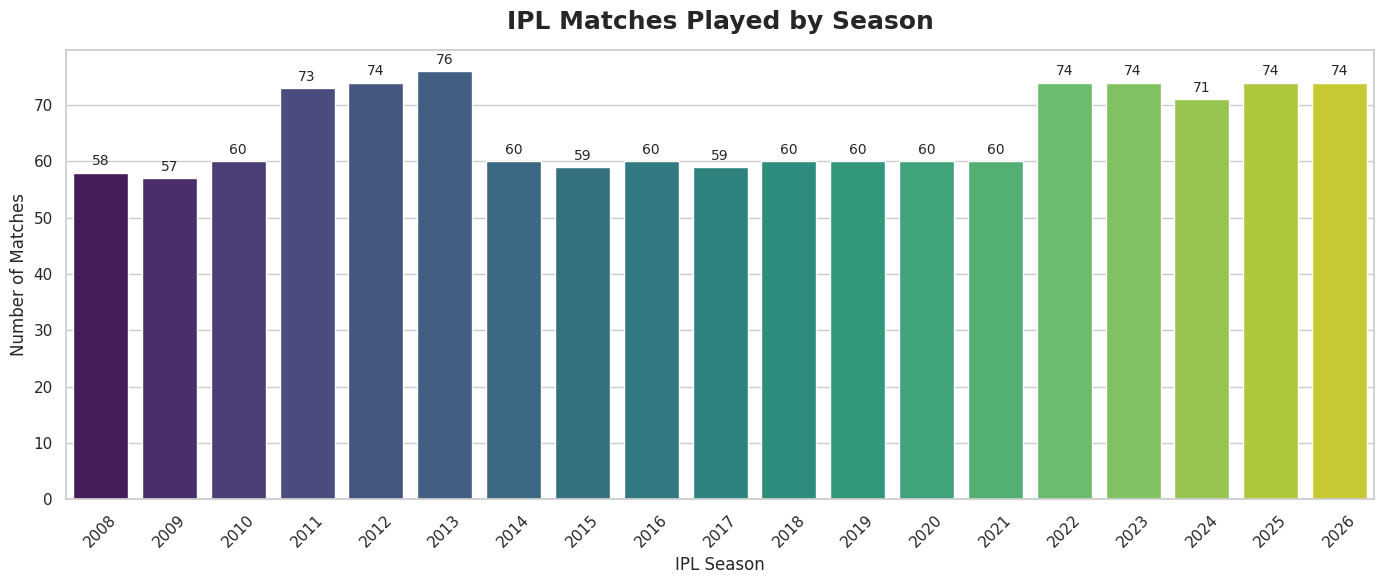

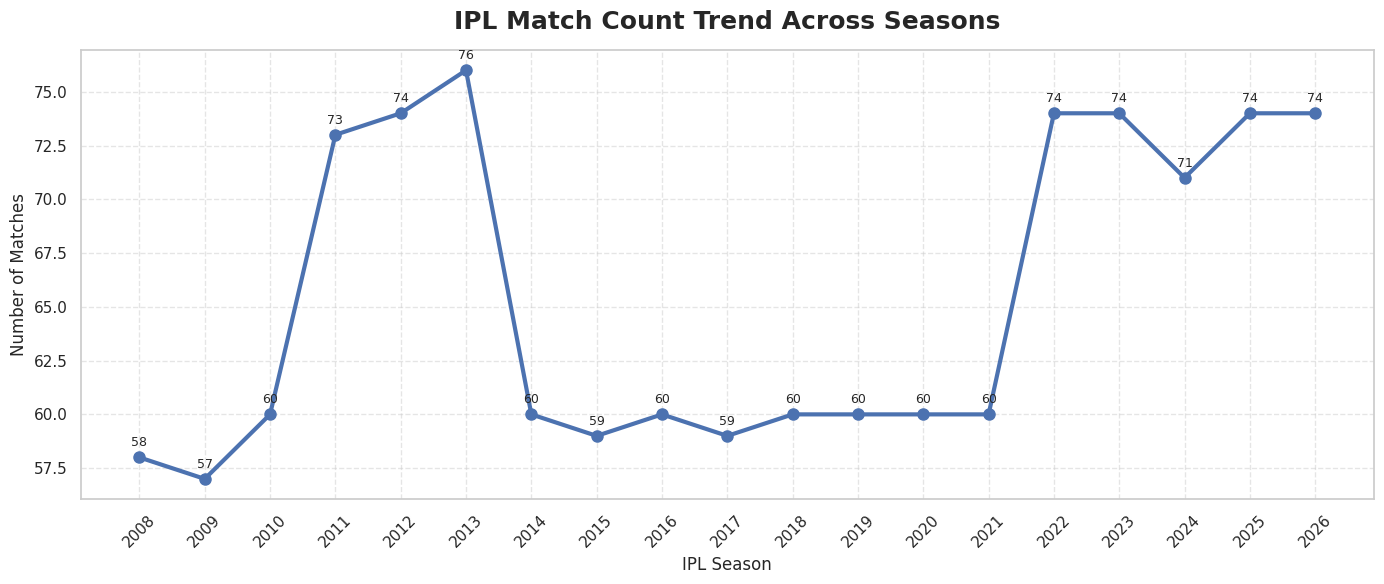

In [ ]:
# ============================================
# STEP 21 — SEASON-WISE VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set attractive visualization style
sns.set_theme(style="whitegrid")

# Make sure data is sorted
season_plot = season_matches.sort_values("season_year")

# --------------------------------------------
# 1. BAR CHART — MATCHES BY SEASON
# --------------------------------------------

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=season_plot,
    x="season_year",
    y="Number_of_Matches",
    palette="viridis"
)

plt.title(
    "IPL Matches Played by Season",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("IPL Season", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)

plt.xticks(rotation=45)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.show()


# --------------------------------------------
# 2. LINE CHART — SEASON TREND
# --------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    season_plot["season_year"],
    season_plot["Number_of_Matches"],
    marker="o",
    linewidth=3,
    markersize=8
)

plt.title(
    "IPL Match Count Trend Across Seasons",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("IPL Season", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)

plt.xticks(
    season_plot["season_year"],
    rotation=45
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

# Add values beside points
for x, y in zip(
    season_plot["season_year"],
    season_plot["Number_of_Matches"]
):
    plt.annotate(
        str(y),
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# STEP 22 — TEAM PERFORMANCE ANALYSIS
# ============================================

# Count appearances of each team
team1_counts = ipl_clean["team1"].value_counts()
team2_counts = ipl_clean["team2"].value_counts()

# Combine both sides of the match
team_matches = (
    team1_counts
    .add(team2_counts, fill_value=0)
    .sort_values(ascending=False)
    .reset_index()
)

team_matches.columns = ["Team", "Matches_Played"]

# Convert to integer
team_matches["Matches_Played"] = (
    team_matches["Matches_Played"].astype(int)
)

print("="*50)
print("TEAM MATCH PARTICIPATION")
print("="*50)

display(team_matches)

print("\nNumber of unique teams:", len(team_matches))

TEAM MATCH PARTICIPATION


,Team,Matches_Played
0,Mumbai Indians,291
1,Kolkata Knight Riders,278
2,Chennai Super Kings,266
3,Rajasthan Royals,251
4,Royal Challengers Bangalore,240
5,Sunrisers Hyderabad,211
6,Kings XI Punjab,190
7,Delhi Daredevils,161
8,Delhi Capitals,120
9,Punjab Kings,88



Number of unique teams: 19


/tmp/ipykernel_2666/1325879314.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


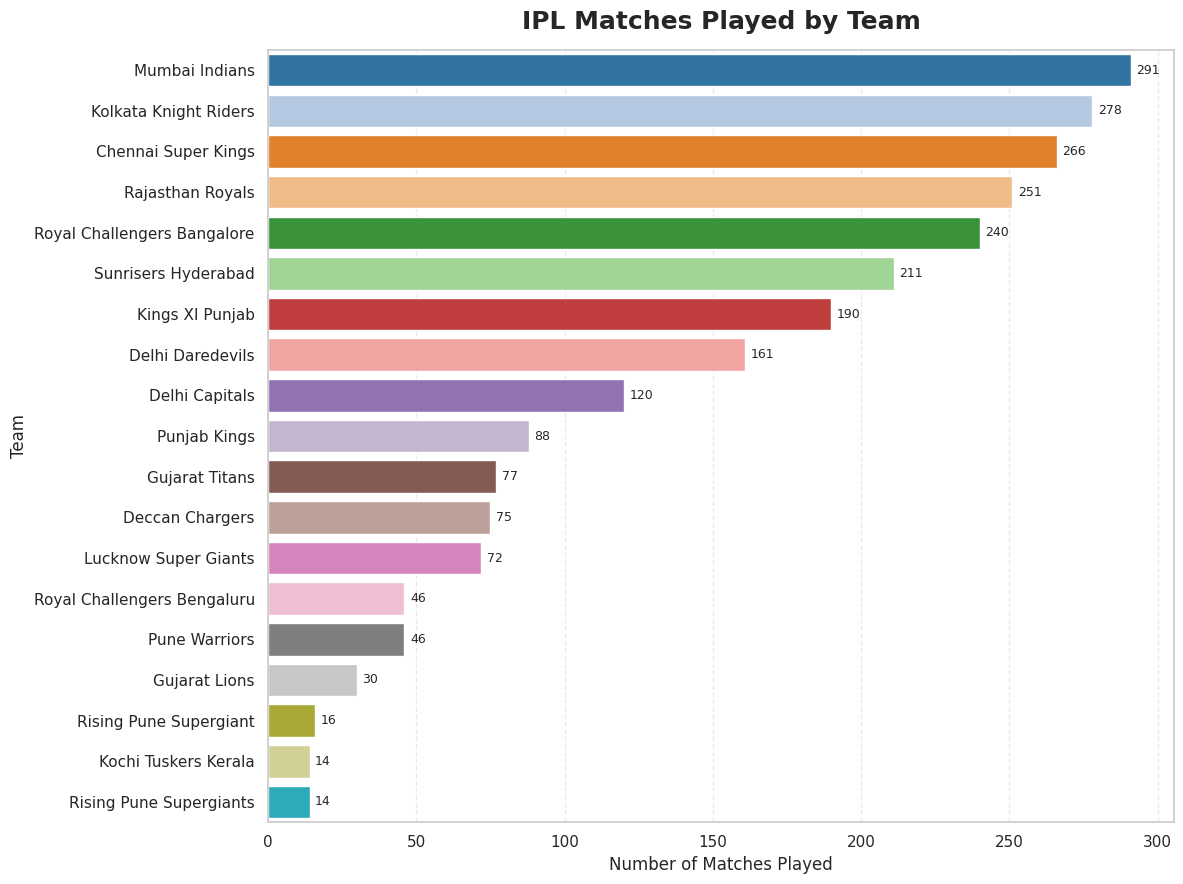

In [ ]:
# ============================================
# STEP 23 — TEAM MATCHES VISUALIZATION
# ============================================

plt.figure(figsize=(12, 9))

ax = sns.barplot(
    data=team_matches,
    x="Matches_Played",
    y="Team",
    palette="tab20"
)

plt.title(
    "IPL Matches Played by Team",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Matches Played", fontsize=12)
plt.ylabel("Team", fontsize=12)

# Add values at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=4,
        fontsize=9
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 24 — TEAM WINS & WIN PERCENTAGE
# ============================================

# Count wins for each team
team_wins = (
    ipl_clean[ipl_clean["winner"] != "No Winner"]["winner"]
    .value_counts()
    .rename("Wins")
)

# Add wins to matches played
team_performance = team_matches.set_index("Team").copy()

team_performance["Wins"] = (
    team_wins
    .reindex(team_performance.index)
    .fillna(0)
    .astype(int)
)

# Calculate win percentage
team_performance["Win_Percentage"] = (
    team_performance["Wins"]
    / team_performance["Matches_Played"]
    * 100
).round(2)

# Convert back to a normal DataFrame
team_performance = (
    team_performance
    .reset_index()
    .sort_values("Win_Percentage", ascending=False)
)

print("="*50)
print("TEAM PERFORMANCE")
print("="*50)

display(team_performance)

TEAM PERFORMANCE


,Team,Matches_Played,Wins,Win_Percentage
13,Royal Challengers Bengaluru,46,29,63.04
16,Rising Pune Supergiant,16,10,62.50
10,Gujarat Titans,77,47,61.04
2,Chennai Super Kings,266,148,55.64
0,Mumbai Indians,291,155,53.26
1,Kolkata Knight Riders,278,140,50.36
3,Rajasthan Royals,251,123,49.00
5,Sunrisers Hyderabad,211,102,48.34
8,Delhi Capitals,120,58,48.33
4,Royal Challengers Bangalore,240,114,47.50


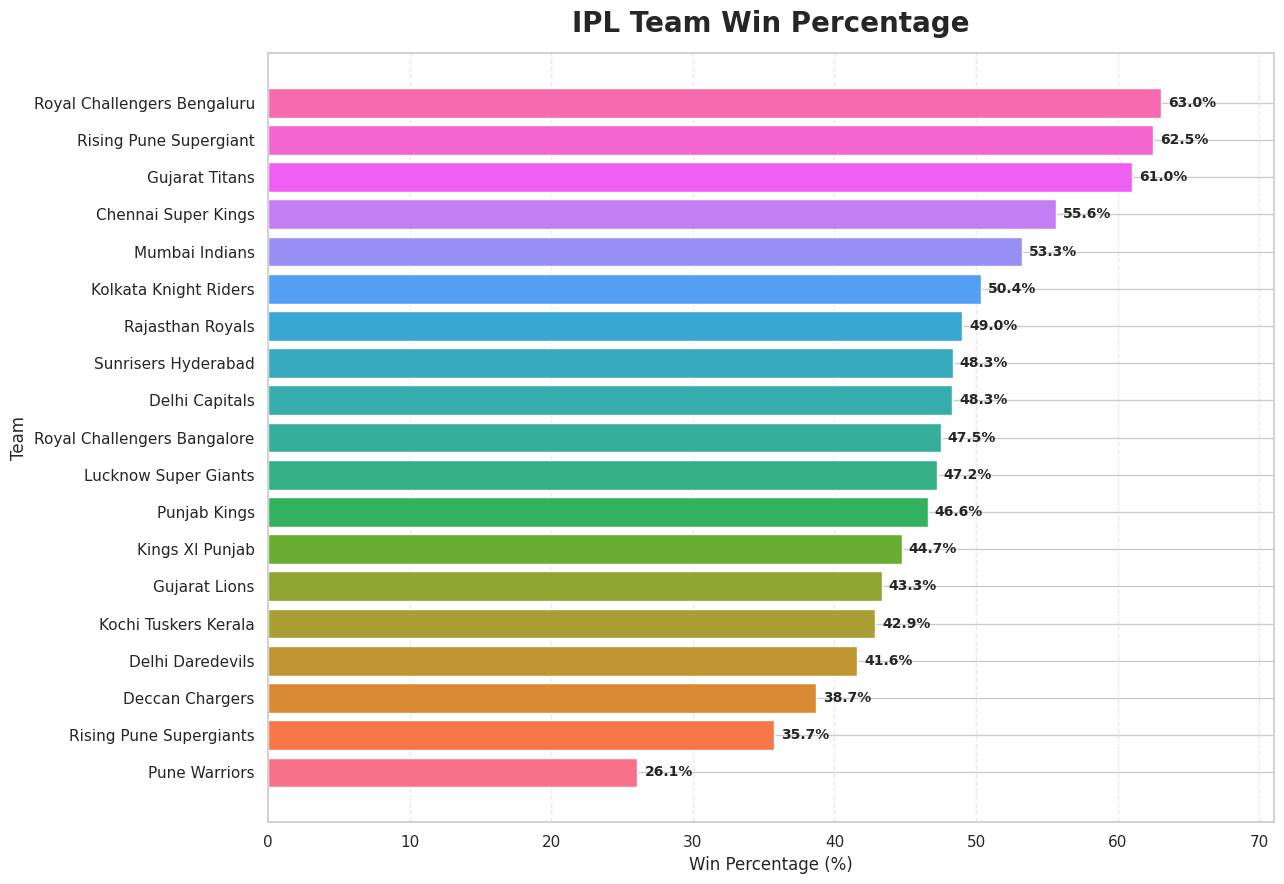

In [ ]:
# ============================================
# STEP 25 — TEAM WIN PERCENTAGE VISUALIZATION
# ============================================

# Sort teams by win percentage
team_win_plot = team_performance.sort_values(
    "Win_Percentage",
    ascending=True
)

plt.figure(figsize=(13, 9))

# Create different colors for each team
colors = sns.color_palette("husl", len(team_win_plot))

bars = plt.barh(
    team_win_plot["Team"],
    team_win_plot["Win_Percentage"],
    color=colors
)

plt.title(
    "IPL Team Win Percentage",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Win Percentage (%)",
    fontsize=12
)

plt.ylabel(
    "Team",
    fontsize=12
)

# Add percentage labels
for bar, value in zip(
    bars,
    team_win_plot["Win_Percentage"]
):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.xlim(
    0,
    max(team_win_plot["Win_Percentage"]) + 8
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 26 — TOSS vs MATCH RESULT
# ============================================

# Exclude matches where there was no winner
toss_analysis = ipl_clean[
    ipl_clean["toss_match_same"] != "Not Applicable"
].copy()

# Count toss winner vs match winner
toss_result = (
    toss_analysis["toss_match_same"]
    .value_counts()
    .reset_index()
)

toss_result.columns = [
    "Toss_Winner_Also_Match_Winner",
    "Number_of_Matches"
]

# Calculate percentage
toss_result["Percentage"] = (
    toss_result["Number_of_Matches"]
    / toss_result["Number_of_Matches"].sum()
    * 100
).round(2)

print("="*50)
print("TOSS WINNER vs MATCH WINNER")
print("="*50)

display(toss_result)

print("\nTotal decided matches analyzed:",
      len(toss_analysis))

TOSS WINNER vs MATCH WINNER


,Toss_Winner_Also_Match_Winner,Number_of_Matches,Percentage
0,Yes,628,51.56
1,No,590,48.44



Total decided matches analyzed: 1218


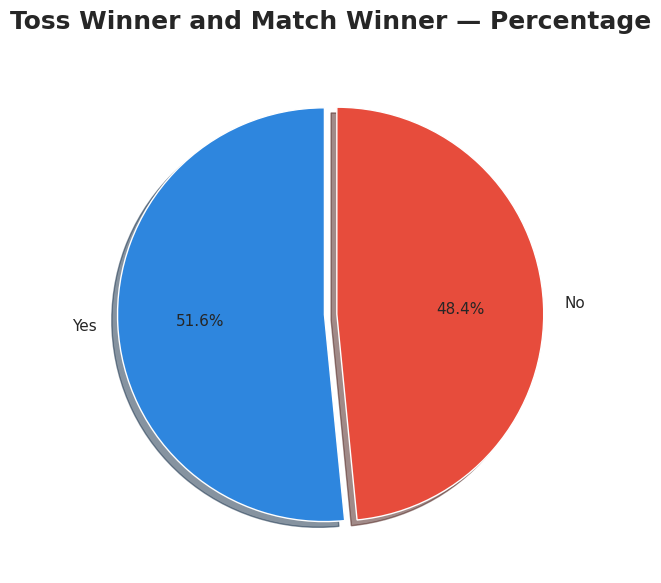

In [ ]:
# ============================================
# STEP 27 — TOSS RESULT VISUALIZATION
# ============================================

# Set visualization style
sns.set_theme(style="whitegrid")

# --------------------------------------------
#  PIE CHART — PERCENTAGE DISTRIBUTION
# --------------------------------------------

plt.figure(figsize=(6, 6))

plt.pie(
    toss_result["Number_of_Matches"],
    labels=toss_result["Toss_Winner_Also_Match_Winner"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=[0.03] * len(toss_result),
    shadow=True,
    textprops={"fontsize": 11}
)

plt.title(
    "Toss Winner and Match Winner — Percentage",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 28 — TOSS DECISION ANALYSIS
# ============================================

# Keep only matches with a valid winner
toss_decision_data = ipl_clean[
    ipl_clean["winner"] != "No Winner"
].copy()

# Check toss decisions
decision_counts = (
    toss_decision_data["toss_decision"]
    .value_counts()
    .reset_index()
)

decision_counts.columns = [
    "Toss_Decision",
    "Number_of_Matches"
]

# Calculate percentage
decision_counts["Percentage"] = (
    decision_counts["Number_of_Matches"]
    / decision_counts["Number_of_Matches"].sum()
    * 100
).round(2)

print("="*50)
print("TOSS DECISION DISTRIBUTION")
print("="*50)

display(decision_counts)

print("\nUnique toss decisions:")
print(toss_decision_data["toss_decision"].unique())

TOSS DECISION DISTRIBUTION


,Toss_Decision,Number_of_Matches,Percentage
0,field,810,66.5
1,bat,408,33.5



Unique toss decisions:
['field' 'bat']


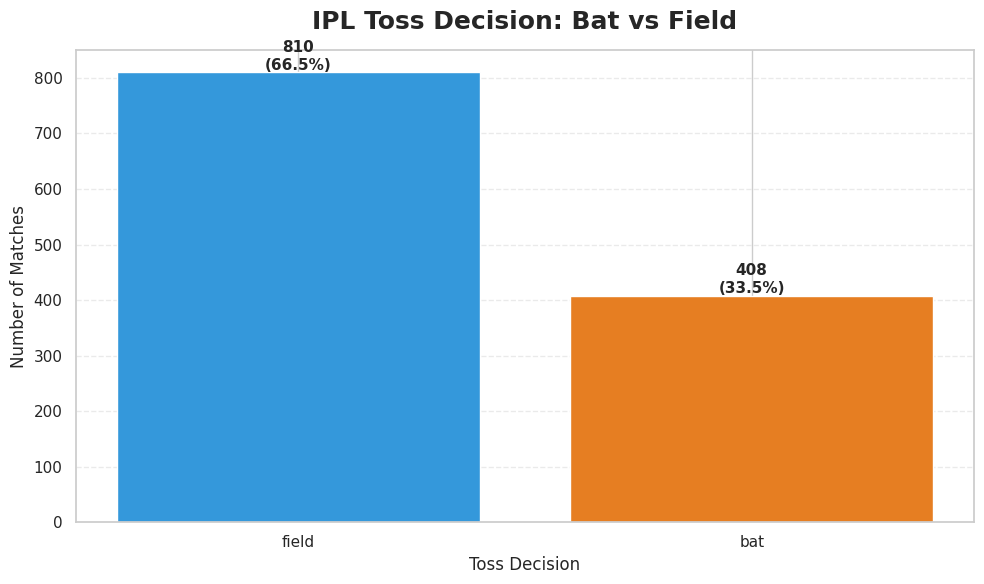

In [ ]:
# ============================================
# STEP 29 — TOSS DECISION VISUALIZATION
# ============================================

sns.set_theme(style="whitegrid")

# --------------------------------------------
# 1. BAR CHART
# --------------------------------------------

plt.figure(figsize=(10, 6))

colors = ["#3498DB", "#E67E22"]

bars = plt.bar(
    decision_counts["Toss_Decision"],
    decision_counts["Number_of_Matches"],
    color=colors
)

plt.title(
    "IPL Toss Decision: Bat vs Field",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Toss Decision", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)

for bar, count, percentage in zip(
    bars,
    decision_counts["Number_of_Matches"],
    decision_counts["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()




In [ ]:
# ============================================
# STEP 30 — TOSS DECISION vs MATCH OUTCOME
# ============================================

# Use only matches where a winner exists
toss_outcome = ipl_clean[
    ipl_clean["winner"] != "No Winner"
].copy()

# Create outcome of the toss-winning team
toss_outcome["Toss_Team_Result"] = np.where(
    toss_outcome["toss_winner"] == toss_outcome["winner"],
    "Won Match",
    "Lost Match"
)

# Create summary table
toss_decision_outcome = (
    toss_outcome
    .groupby(["toss_decision", "Toss_Team_Result"])
    .size()
    .reset_index(name="Number_of_Matches")
)

# Calculate percentage within each toss decision
toss_decision_outcome["Percentage"] = (
    toss_decision_outcome["Number_of_Matches"]
    /
    toss_decision_outcome
    .groupby("toss_decision")["Number_of_Matches"]
    .transform("sum")
    * 100
).round(2)

print("="*50)
print("TOSS DECISION vs MATCH OUTCOME")
print("="*50)

display(toss_decision_outcome)

TOSS DECISION vs MATCH OUTCOME


,toss_decision,Toss_Team_Result,Number_of_Matches,Percentage
0,bat,Lost Match,223,54.66
1,bat,Won Match,185,45.34
2,field,Lost Match,367,45.31
3,field,Won Match,443,54.69


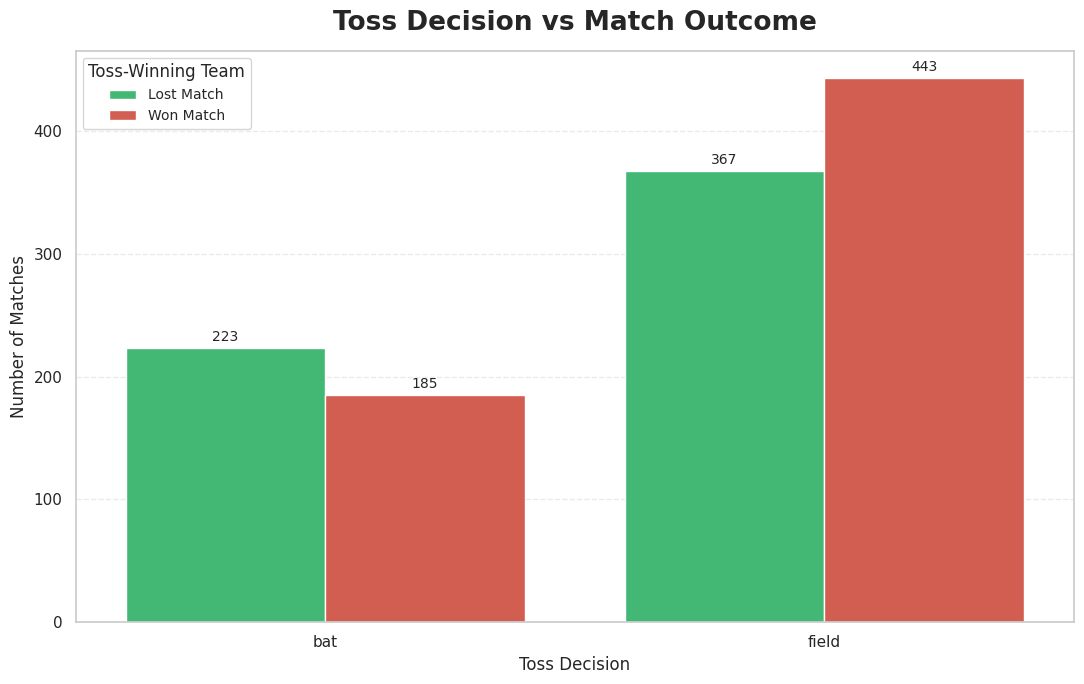

In [ ]:
# ============================================
# STEP 31 — TOSS DECISION vs MATCH OUTCOME
# ============================================

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=toss_decision_outcome,
    x="toss_decision",
    y="Number_of_Matches",
    hue="Toss_Team_Result",
    palette=["#2ECC71", "#E74C3C"]
)

plt.title(
    "Toss Decision vs Match Outcome",
    fontsize=19,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Toss Decision",
    fontsize=12
)

plt.ylabel(
    "Number of Matches",
    fontsize=12
)

plt.legend(
    title="Toss-Winning Team",
    fontsize=10
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=10
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 32 — VENUE ANALYSIS
# ============================================

# Count matches at each venue
venue_matches = (
    ipl_clean["venue"]
    .value_counts()
    .reset_index()
)

venue_matches.columns = [
    "Venue",
    "Number_of_Matches"
]

print("="*50)
print("TOP 15 IPL VENUES BY NUMBER OF MATCHES")
print("="*50)

display(venue_matches.head(15))

TOP 15 IPL VENUES BY NUMBER OF MATCHES


,Venue,Number_of_Matches
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Wankhede Stadium, Mumbai",59
5,"Rajiv Gandhi International Stadium, Uppal",49
6,"MA Chidambaram Stadium, Chepauk",48
7,Sawai Mansingh Stadium,47
8,Dubai International Cricket Stadium,46
9,"MA Chidambaram Stadium, Chepauk, Chennai",41


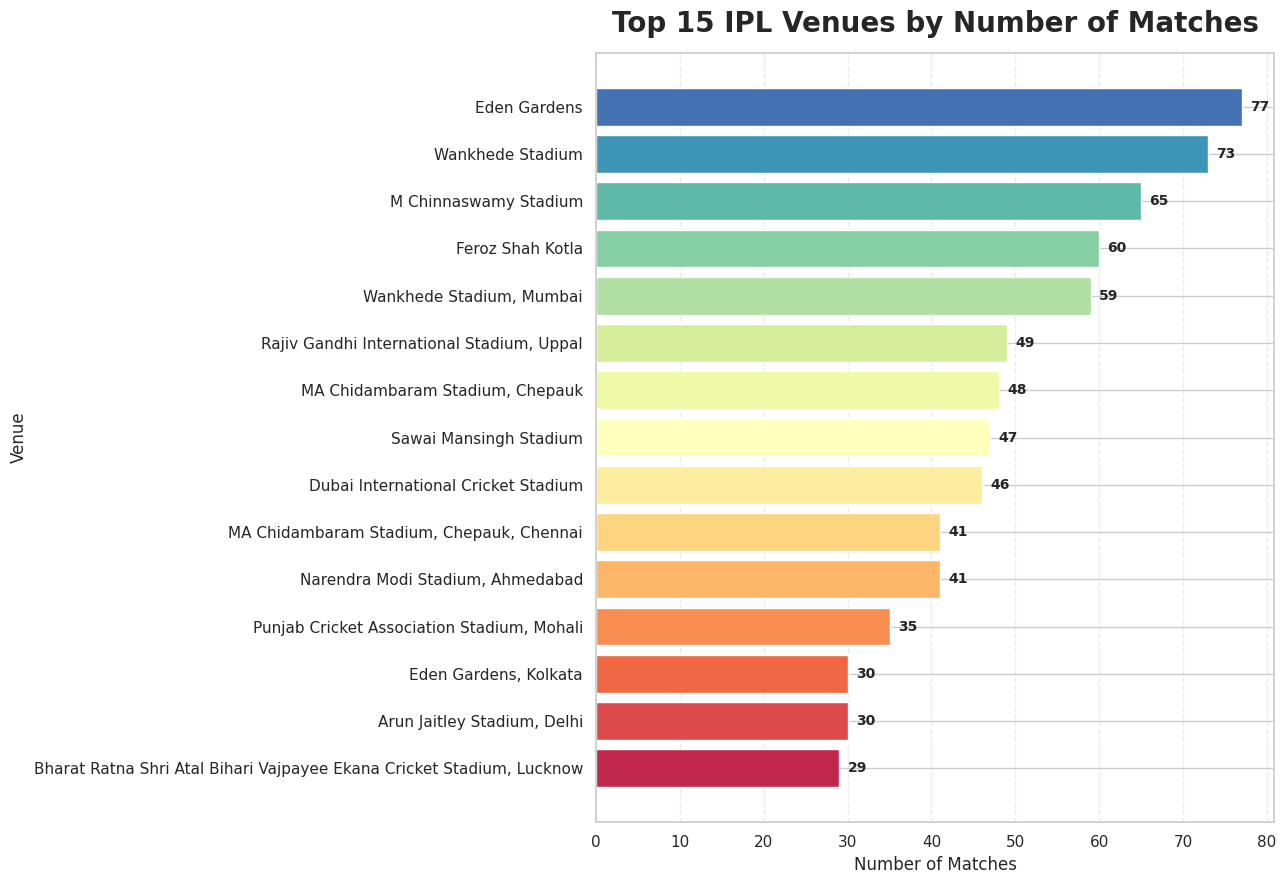

In [ ]:
# ============================================
# STEP 33 — VENUE VISUALIZATION
# ============================================

# Select top 15 venues
top_venues = venue_matches.head(15).sort_values(
    "Number_of_Matches",
    ascending=True
)

plt.figure(figsize=(13, 9))

# Create different colors for each venue
colors = sns.color_palette("Spectral", len(top_venues))

bars = plt.barh(
    top_venues["Venue"],
    top_venues["Number_of_Matches"],
    color=colors
)

plt.title(
    "Top 15 IPL Venues by Number of Matches",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Matches",
    fontsize=12
)

plt.ylabel(
    "Venue",
    fontsize=12
)

# Add values at the end of each bar
for bar, value in zip(
    bars,
    top_venues["Number_of_Matches"]
):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

RUNS SUMMARY
Total team innings analyzed: 2486
Average runs: 161.6
Median runs: 162.0
Minimum runs: 0
Maximum runs: 287

Top 10 highest team scores:


,Runs
1053,287
1096,286
1162,278
1031,277
1039,272
1058,266
2446,265
1203,264
352,263
2296,262


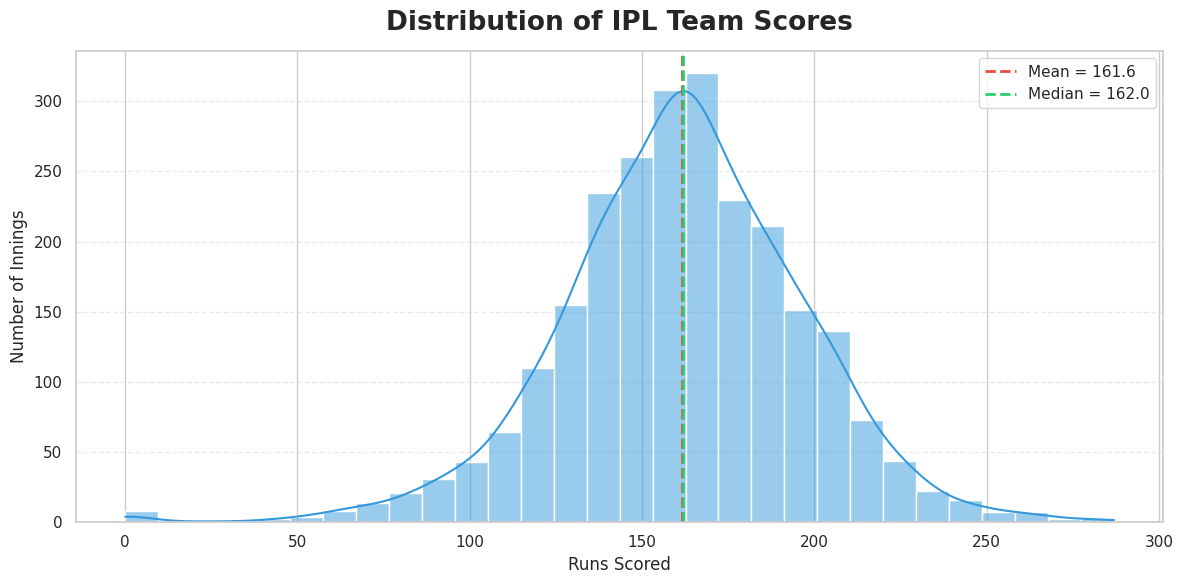

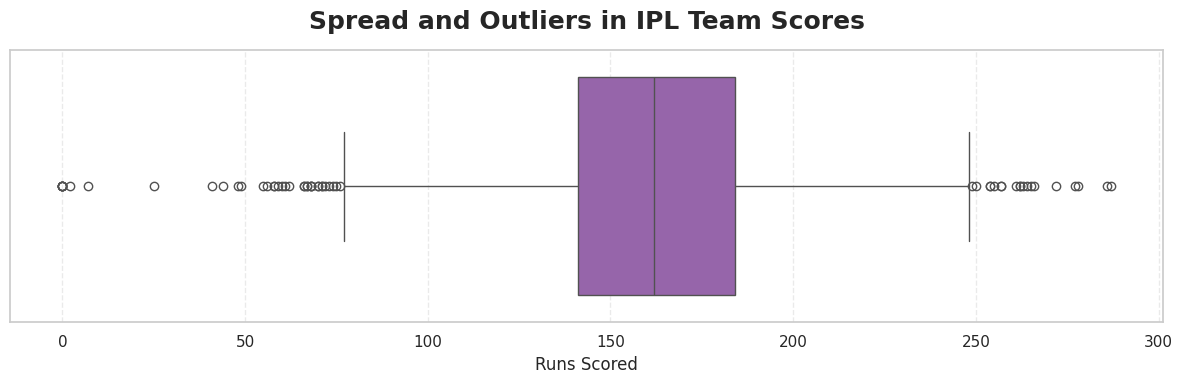

In [ ]:
# ============================================
# STEP 34 — RUNS ANALYSIS
# ============================================

# Combine runs scored by both teams
runs_data = pd.concat([
    ipl_clean[["team1_runs"]].rename(columns={"team1_runs": "Runs"}),
    ipl_clean[["team2_runs"]].rename(columns={"team2_runs": "Runs"})
], ignore_index=True)

# Convert to numeric
runs_data["Runs"] = pd.to_numeric(
    runs_data["Runs"],
    errors="coerce"
)

# Remove missing run values
runs_data = runs_data.dropna()

print("="*50)
print("RUNS SUMMARY")
print("="*50)

print("Total team innings analyzed:", len(runs_data))
print("Average runs:", round(runs_data["Runs"].mean(), 2))
print("Median runs:", round(runs_data["Runs"].median(), 2))
print("Minimum runs:", runs_data["Runs"].min())
print("Maximum runs:", runs_data["Runs"].max())

print("\nTop 10 highest team scores:")
display(
    runs_data
    .sort_values("Runs", ascending=False)
    .head(10)
)


# ============================================
# 1. HISTOGRAM
# ============================================

plt.figure(figsize=(12, 6))

sns.histplot(
    runs_data["Runs"],
    bins=30,
    kde=True,
    color="#3498DB"
)

plt.axvline(
    runs_data["Runs"].mean(),
    color="#E74C3C",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {runs_data['Runs'].mean():.1f}"
)

plt.axvline(
    runs_data["Runs"].median(),
    color="#2ECC71",
    linestyle="--",
    linewidth=2,
    label=f"Median = {runs_data['Runs'].median():.1f}"
)

plt.title(
    "Distribution of IPL Team Scores",
    fontsize=19,
    fontweight="bold",
    pad=15
)

plt.xlabel("Runs Scored", fontsize=12)
plt.ylabel("Number of Innings", fontsize=12)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================
# 2. BOX PLOT
# ============================================

plt.figure(figsize=(12, 4))

sns.boxplot(
    x=runs_data["Runs"],
    color="#9B59B6"
)

plt.title(
    "Spread and Outliers in IPL Team Scores",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Runs Scored",
    fontsize=12
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

TEAM 1 vs TEAM 2 RUN SUMMARY


,Team 1 Runs,Team 2 Runs
count,1243.00,1243.00
mean,165.85,157.35
std,35.49,34.61
min,2.00,0.00
25%,144.00,138.00
50%,165.00,160.00
75%,189.00,179.00
max,287.00,265.00


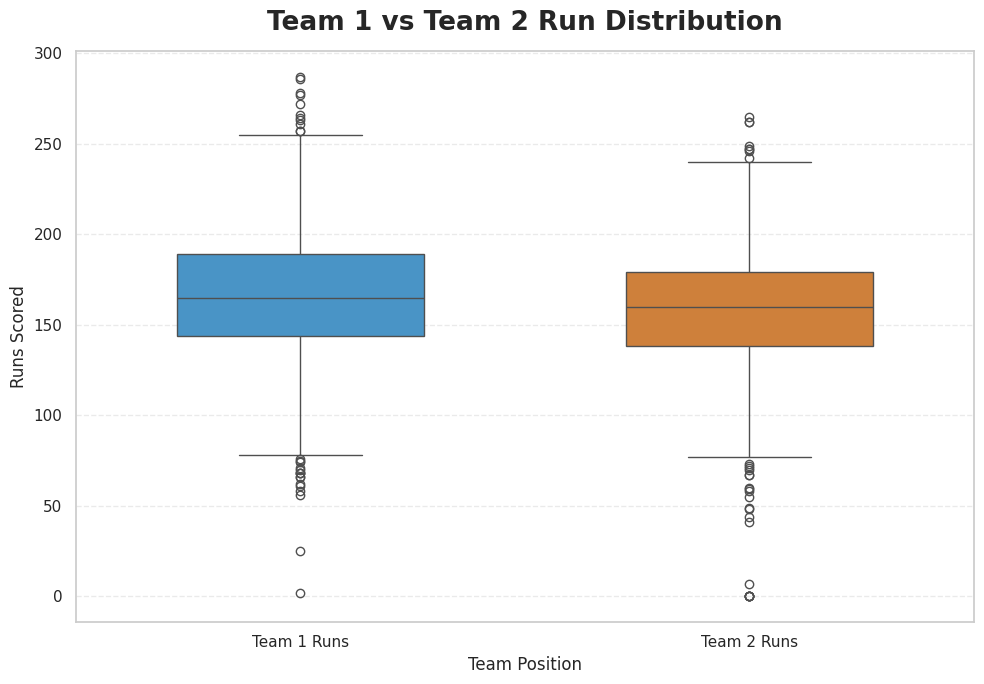

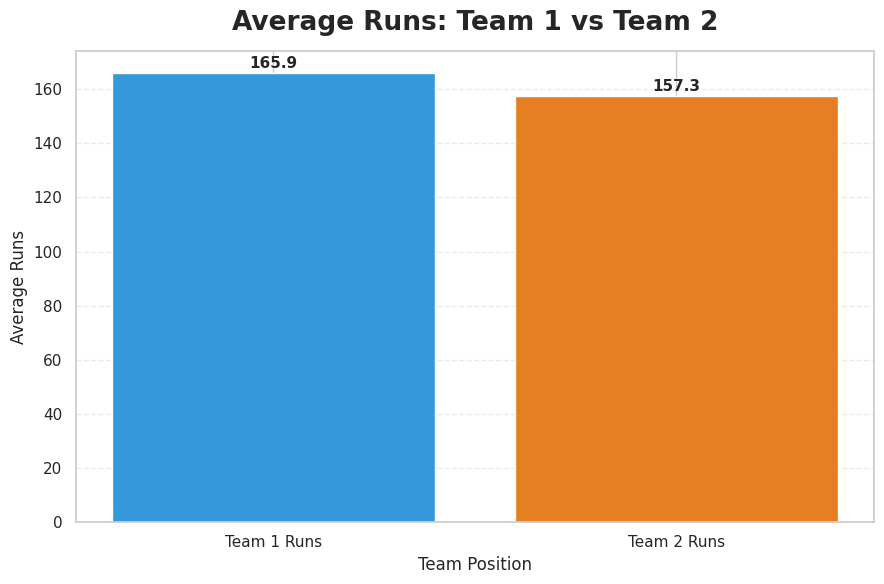

In [ ]:
# ============================================
# STEP 35 — TEAM 1 vs TEAM 2 RUN COMPARISON
# ============================================

run_comparison = pd.DataFrame({
    "Team 1 Runs": pd.to_numeric(
        ipl_clean["team1_runs"],
        errors="coerce"
    ),
    "Team 2 Runs": pd.to_numeric(
        ipl_clean["team2_runs"],
        errors="coerce"
    )
}).dropna()

print("="*50)
print("TEAM 1 vs TEAM 2 RUN SUMMARY")
print("="*50)

display(
    run_comparison.describe().round(2)
)


# ============================================
# BOX PLOT COMPARISON
# ============================================

plt.figure(figsize=(10, 7))

box = sns.boxplot(
    data=run_comparison,
    palette=["#3498DB", "#E67E22"],
    width=0.55
)

plt.title(
    "Team 1 vs Team 2 Run Distribution",
    fontsize=19,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Team Position",
    fontsize=12
)

plt.ylabel(
    "Runs Scored",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================
# AVERAGE RUN COMPARISON
# ============================================

avg_runs = (
    run_comparison.mean()
    .reset_index()
)

avg_runs.columns = [
    "Team_Position",
    "Average_Runs"
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    avg_runs["Team_Position"],
    avg_runs["Average_Runs"],
    color=["#3498DB", "#E67E22"]
)

plt.title(
    "Average Runs: Team 1 vs Team 2",
    fontsize=19,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Team Position",
    fontsize=12
)

plt.ylabel(
    "Average Runs",
    fontsize=12
)

for bar, value in zip(
    bars,
    avg_runs["Average_Runs"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{value:.1f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

WIN MARGIN SUMMARY


,Margin_Type,Number_of_Matches,Percentage
0,Wickets,660,53.10
1,Runs,558,44.89
2,No Margin,25,2.01


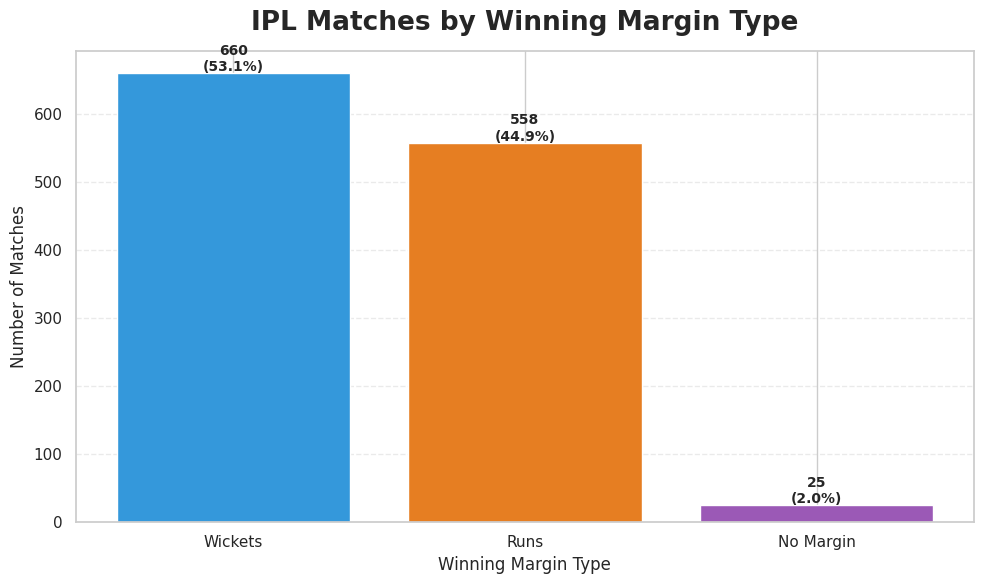

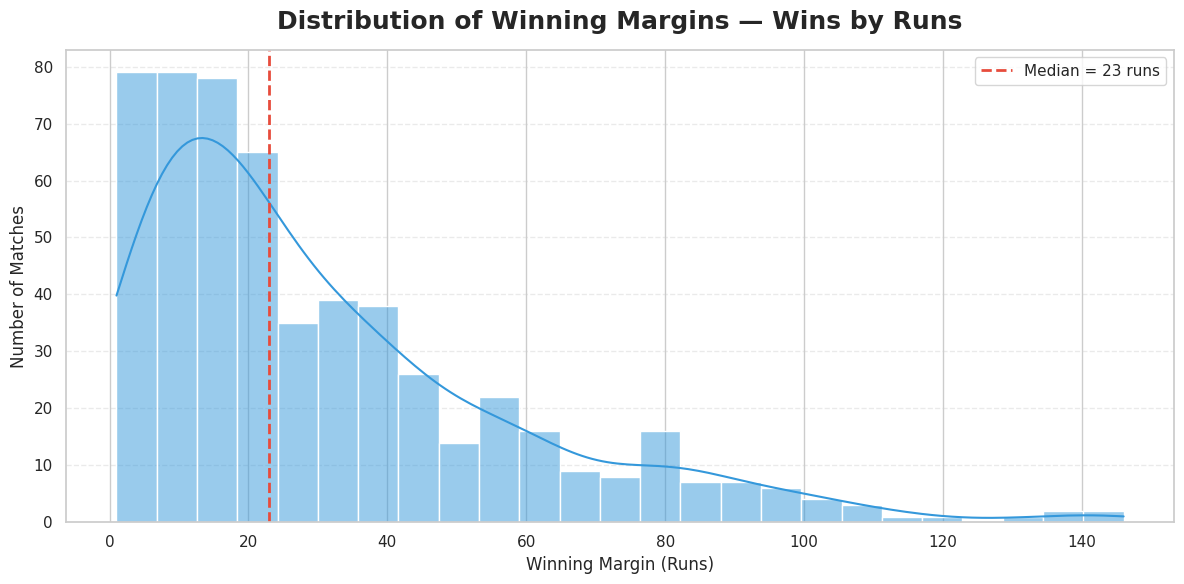

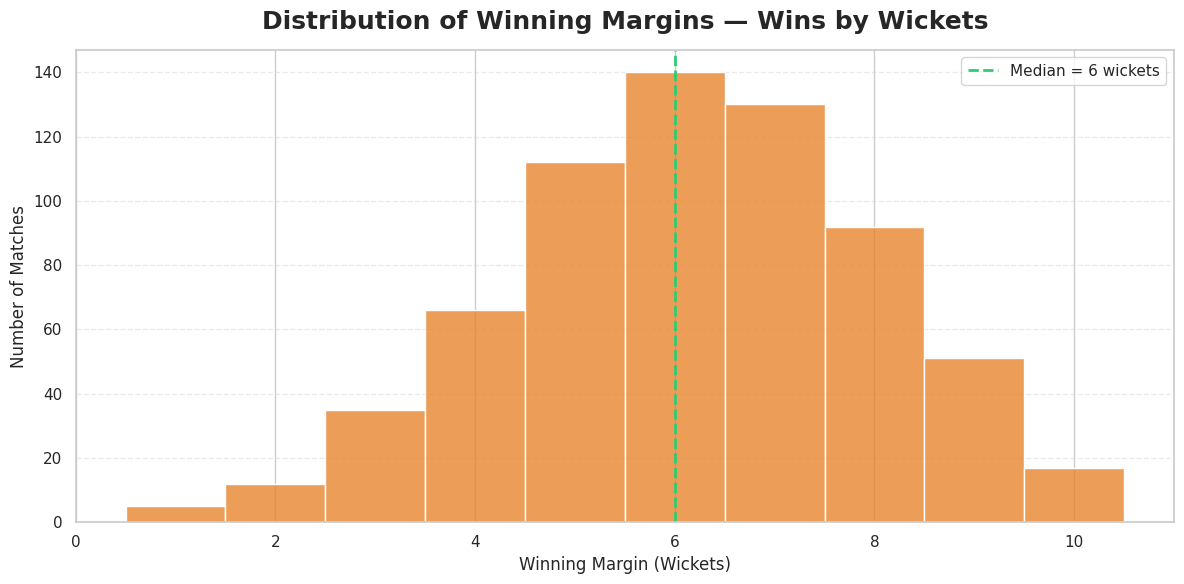

In [ ]:
# ============================================
# STEP 36 — WIN MARGIN ANALYSIS
# ============================================

print("="*50)
print("WIN MARGIN SUMMARY")
print("="*50)

# Count result types
margin_summary = (
    ipl_clean["margin_type"]
    .value_counts()
    .reset_index()
)

margin_summary.columns = [
    "Margin_Type",
    "Number_of_Matches"
]

margin_summary["Percentage"] = (
    margin_summary["Number_of_Matches"]
    / margin_summary["Number_of_Matches"].sum()
    * 100
).round(2)

display(margin_summary)


# ============================================
# 1. BAR CHART — MARGIN TYPE
# ============================================

plt.figure(figsize=(10, 6))

colors = ["#3498DB", "#E67E22", "#9B59B6"]

bars = plt.bar(
    margin_summary["Margin_Type"],
    margin_summary["Number_of_Matches"],
    color=colors[:len(margin_summary)]
)

plt.title(
    "IPL Matches by Winning Margin Type",
    fontsize=19,
    fontweight="bold",
    pad=15
)

plt.xlabel("Winning Margin Type", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)

for bar, count, percentage in zip(
    bars,
    margin_summary["Number_of_Matches"],
    margin_summary["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================
# 2. DISTRIBUTION OF WINS BY RUNS
# ============================================

runs_wins = pd.to_numeric(
    ipl_clean.loc[
        ipl_clean["win_by_runs"] > 0,
        "win_by_runs"
    ],
    errors="coerce"
).dropna()

plt.figure(figsize=(12, 6))

sns.histplot(
    runs_wins,
    bins=25,
    kde=True,
    color="#3498DB"
)

plt.axvline(
    runs_wins.median(),
    color="#E74C3C",
    linestyle="--",
    linewidth=2,
    label=f"Median = {runs_wins.median():.0f} runs"
)

plt.title(
    "Distribution of Winning Margins — Wins by Runs",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Winning Margin (Runs)", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================
# 3. DISTRIBUTION OF WINS BY WICKETS
# ============================================

wicket_wins = pd.to_numeric(
    ipl_clean.loc[
        ipl_clean["win_by_wickets"] > 0,
        "win_by_wickets"
    ],
    errors="coerce"
).dropna()

plt.figure(figsize=(12, 6))

sns.histplot(
    wicket_wins,
    bins=10,
    discrete=True,
    color="#E67E22"
)

plt.axvline(
    wicket_wins.median(),
    color="#2ECC71",
    linestyle="--",
    linewidth=2,
    label=f"Median = {wicket_wins.median():.0f} wickets"
)

plt.title(
    "Distribution of Winning Margins — Wins by Wickets",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Winning Margin (Wickets)", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

TOP 15 PLAYERS BY PLAYER OF THE MATCH AWARDS


,Player,Player_of_Match_Awards
0,AB de Villiers,25
1,CH Gayle,22
2,V Kohli,22
3,RG Sharma,21
4,SP Narine,18
5,DA Warner,18
6,MS Dhoni,18
7,RA Jadeja,17
8,KL Rahul,17
9,SR Watson,16


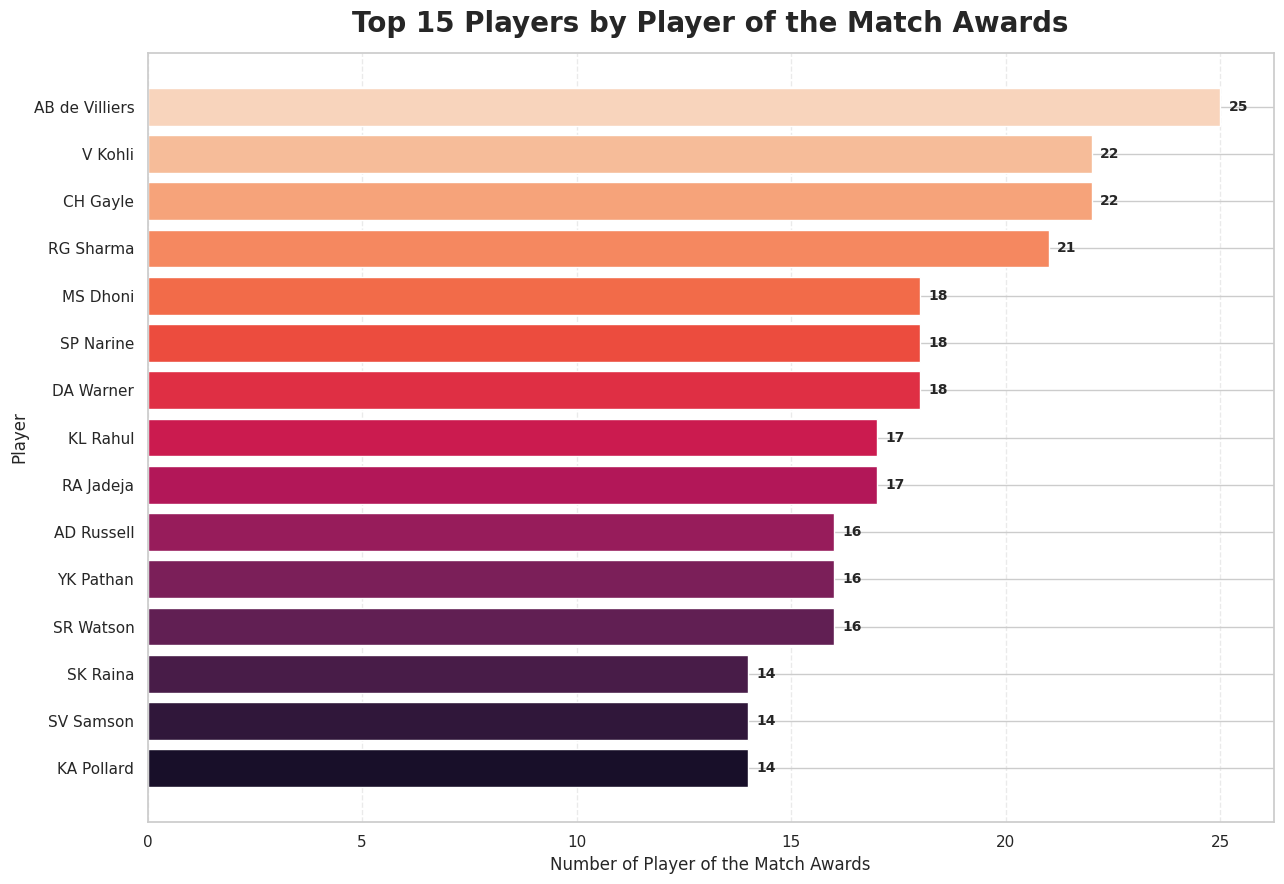

In [ ]:
# ============================================
# STEP 37 — PLAYER OF THE MATCH ANALYSIS
# ============================================

# Remove rows where Player of the Match was not awarded
pom_data = ipl_clean[
    ~ipl_clean["player_of_match"].isin(
        ["Not Awarded", "nan", "None"]
    )
].copy()

# Count Player of the Match awards
player_awards = (
    pom_data["player_of_match"]
    .value_counts()
    .reset_index()
)

player_awards.columns = [
    "Player",
    "Player_of_Match_Awards"
]

print("="*50)
print("TOP 15 PLAYERS BY PLAYER OF THE MATCH AWARDS")
print("="*50)

display(
    player_awards.head(15)
)


# ============================================
# VISUALIZATION
# ============================================

top_players = (
    player_awards
    .head(15)
    .sort_values(
        "Player_of_Match_Awards",
        ascending=True
    )
)

plt.figure(figsize=(13, 9))

colors = sns.color_palette(
    "rocket",
    len(top_players)
)

bars = plt.barh(
    top_players["Player"],
    top_players["Player_of_Match_Awards"],
    color=colors
)

plt.title(
    "Top 15 Players by Player of the Match Awards",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Player of the Match Awards",
    fontsize=12
)

plt.ylabel(
    "Player",
    fontsize=12
)

# Add values
for bar, value in zip(
    bars,
    top_players["Player_of_Match_Awards"]
):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

TOP 15 PLAYERS BY PLAYER OF THE MATCH AWARDS


,Player,Player_of_Match_Awards
0,AB de Villiers,25
1,CH Gayle,22
2,V Kohli,22
3,RG Sharma,21
4,SP Narine,18
5,DA Warner,18
6,MS Dhoni,18
7,RA Jadeja,17
8,KL Rahul,17
9,SR Watson,16


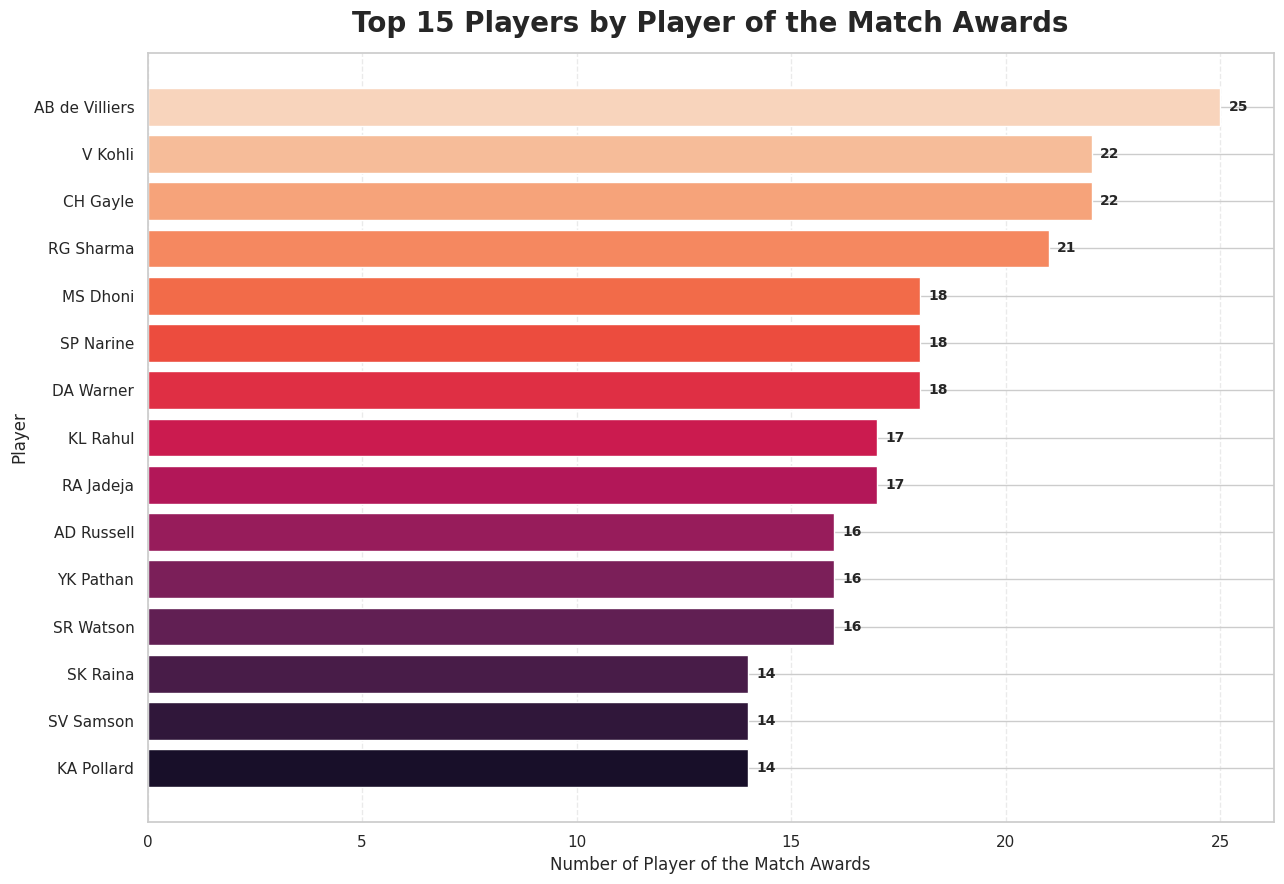

In [ ]:
# ============================================
# STEP 37 — PLAYER OF THE MATCH ANALYSIS
# ============================================

# Remove rows where Player of the Match was not awarded
pom_data = ipl_clean[
    ~ipl_clean["player_of_match"].isin(
        ["Not Awarded", "nan", "None"]
    )
].copy()

# Count Player of the Match awards
player_awards = (
    pom_data["player_of_match"]
    .value_counts()
    .reset_index()
)

player_awards.columns = [
    "Player",
    "Player_of_Match_Awards"
]

print("="*50)
print("TOP 15 PLAYERS BY PLAYER OF THE MATCH AWARDS")
print("="*50)

display(
    player_awards.head(15)
)


# ============================================
# VISUALIZATION
# ============================================

top_players = (
    player_awards
    .head(15)
    .sort_values(
        "Player_of_Match_Awards",
        ascending=True
    )
)

plt.figure(figsize=(13, 9))

colors = sns.color_palette(
    "rocket",
    len(top_players)
)

bars = plt.barh(
    top_players["Player"],
    top_players["Player_of_Match_Awards"],
    color=colors
)

plt.title(
    "Top 15 Players by Player of the Match Awards",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Player of the Match Awards",
    fontsize=12
)

plt.ylabel(
    "Player",
    fontsize=12
)

# Add values
for bar, value in zip(
    bars,
    top_players["Player_of_Match_Awards"]
):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 39 — INSPECT PLAYOFF / KNOCKOUT MATCHES
# ============================================

playoff_matches = ipl_clean[
    ipl_clean["match_stage"] == "Playoff / Knockout"
].copy()

print("="*60)
print("PLAYOFF / KNOCKOUT MATCHES")
print("="*60)

print("Number of playoff/knockout matches:",
      len(playoff_matches))

# Display the most useful columns for identifying the stage
playoff_columns = [
    "season",
    "date",
    "match_number",
    "city",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "winner",
    "result_type",
    "win_by_runs",
    "win_by_wickets",
    "player_of_match"
]

available_columns = [
    col for col in playoff_columns
    if col in playoff_matches.columns
]

display(
    playoff_matches[
        available_columns
    ].sort_values(
        ["season", "date"]
    )
)

PLAYOFF / KNOCKOUT MATCHES
Number of playoff/knockout matches: 74


,season,date,match_number,city,venue,team1,team2,toss_winner,toss_decision,winner,result_type,win_by_runs,win_by_wickets,player_of_match
55,2008,2008-05-30,NaN,Mumbai,Wankhede Stadium,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,field,Rajasthan Royals,complete,105,0,SR Watson
56,2008,2008-05-31,NaN,Mumbai,Wankhede Stadium,Chennai Super Kings,Kings XI Punjab,Kings XI Punjab,bat,Chennai Super Kings,complete,0,9,M Ntini
57,2008,2008-06-01,NaN,Mumbai,Dr DY Patil Sports Academy,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,complete,0,3,YK Pathan
112,2009,2009-05-22,NaN,Centurion,SuperSport Park,Delhi Daredevils,Deccan Chargers,Deccan Chargers,field,Deccan Chargers,complete,0,6,AC Gilchrist
113,2009,2009-05-23,NaN,Johannesburg,New Wanderers Stadium,Royal Challengers Bangalore,Chennai Super Kings,Royal Challengers Bangalore,field,Royal Challengers Bangalore,complete,0,6,MK Pandey
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168,2025,2025-06-03,NaN,Ahmedabad,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Punjab Kings,Punjab Kings,field,Royal Challengers Bengaluru,complete,6,0,KH Pandya
1239,2026,2026-05-26,NaN,Dharamsala,"Himachal Pradesh Cricket Association Stadium, ...",Royal Challengers Bengaluru,Gujarat Titans,Gujarat Titans,field,Royal Challengers Bengaluru,complete,92,0,RM Patidar
1240,2026,2026-05-27,NaN,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Rajasthan Royals,complete,47,0,V Suryavanshi
1241,2026,2026-05-29,NaN,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Gujarat Titans,Rajasthan Royals,bat,Gujarat Titans,complete,0,7,Shubman Gill


In [ ]:
# ============================================
# STEP 40 — CHECK PLAYOFF EVENT INFORMATION
# ============================================

playoff_events = (
    ipl_clean[
        ipl_clean["match_stage"] == "Playoff / Knockout"
    ]["event_name"]
    .value_counts(dropna=False)
    .reset_index()
)

playoff_events.columns = [
    "Event_Name",
    "Number_of_Matches"
]

print("="*60)
print("EVENT NAMES FOR PLAYOFF / KNOCKOUT MATCHES")
print("="*60)

display(playoff_events)

EVENT NAMES FOR PLAYOFF / KNOCKOUT MATCHES


,Event_Name,Number_of_Matches
0,Indian Premier League,74


MATCH OUTCOMES BY MATCH STAGE


,match_stage,result_category,Number_of_Matches
0,League,Other / No Result,25
1,League,Win by Runs,522
2,League,Win by Wickets,622
3,Playoff / Knockout,Win by Runs,36
4,Playoff / Knockout,Win by Wickets,38


<Figure size 1100x700 with 0 Axes>

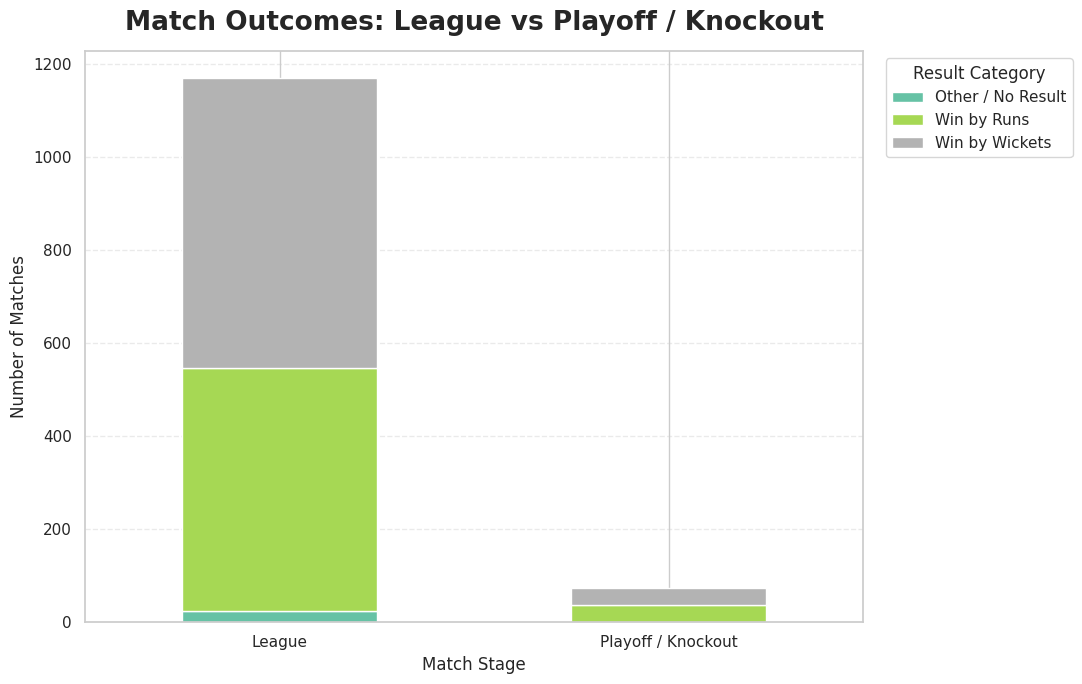

In [ ]:
# ============================================
# STEP 41 — MATCH OUTCOME BY STAGE
# ============================================

stage_result = (
    ipl_clean
    .groupby(["match_stage", "result_category"])
    .size()
    .reset_index(name="Number_of_Matches")
)

print("="*60)
print("MATCH OUTCOMES BY MATCH STAGE")
print("="*60)

display(stage_result)


# ============================================
# VISUALIZATION — STACKED BAR CHART
# ============================================

stage_pivot = stage_result.pivot(
    index="match_stage",
    columns="result_category",
    values="Number_of_Matches"
).fillna(0)

plt.figure(figsize=(11, 7))

ax = stage_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 7),
    colormap="Set2"
)

plt.title(
    "Match Outcomes: League vs Playoff / Knockout",
    fontsize=19,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Match Stage",
    fontsize=12
)

plt.ylabel(
    "Number of Matches",
    fontsize=12
)

plt.xticks(rotation=0)

plt.legend(
    title="Result Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 42A — STANDARDIZE TEAM NAMES
# ============================================

# Create a copy before standardizing team names
ipl_clean["team1_original"] = ipl_clean["team1"]
ipl_clean["team2_original"] = ipl_clean["team2"]
ipl_clean["toss_winner_original"] = ipl_clean["toss_winner"]
ipl_clean["winner_original"] = ipl_clean["winner"]

# Team name mapping
team_name_mapping = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
}

# Apply mapping to all relevant team columns
team_columns = [
    "team1",
    "team2",
    "toss_winner",
    "winner"
]

for col in team_columns:
    ipl_clean[col] = ipl_clean[col].replace(
        team_name_mapping
    )

print("="*60)
print("TEAM NAME STANDARDIZATION")
print("="*60)

print("Royal Challengers Bangalore → Royal Challengers Bengaluru")

print("\nCheck Team 1:")
print(
    ipl_clean["team1"]
    .value_counts()
    .loc[
        lambda x: x.index.isin([
            "Royal Challengers Bangalore",
            "Royal Challengers Bengaluru"
        ])
    ]
)

print("\nCheck Team 2:")
print(
    ipl_clean["team2"]
    .value_counts()
    .loc[
        lambda x: x.index.isin([
            "Royal Challengers Bangalore",
            "Royal Challengers Bengaluru"
        ])
    ]
)

print("\nUnique team names after standardization:")

all_teams = pd.concat([
    ipl_clean["team1"],
    ipl_clean["team2"]
]).dropna().unique()

for team in sorted(all_teams):
    print(team)

TEAM NAME STANDARDIZATION
Royal Challengers Bangalore → Royal Challengers Bengaluru

Check Team 1:
team1
Royal Challengers Bengaluru    159
Name: count, dtype: int64

Check Team 2:
team2
Royal Challengers Bengaluru    127
Name: count, dtype: int64

Unique team names after standardization:
Chennai Super Kings
Deccan Chargers
Delhi Capitals
Delhi Daredevils
Gujarat Lions
Gujarat Titans
Kings XI Punjab
Kochi Tuskers Kerala
Kolkata Knight Riders
Lucknow Super Giants
Mumbai Indians
Pune Warriors
Punjab Kings
Rajasthan Royals
Rising Pune Supergiant
Rising Pune Supergiants
Royal Challengers Bengaluru
Sunrisers Hyderabad


In [ ]:
# ============================================
# STEP 42D — STANDARDIZE ALL TEAM NAMES
# ============================================

team_name_mapping = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiants": "Rising Pune Supergiant",
    "Kings XI Punjab": "Punjab Kings",
    "Delhi Daredevils": "Delhi Capitals"
}

team_columns = [
    "team1",
    "team2",
    "toss_winner",
    "winner"
]

# Apply standardization
for col in team_columns:
    ipl_clean[col] = ipl_clean[col].replace(
        team_name_mapping
    )

print("="*60)
print("TEAM NAME STANDARDIZATION")
print("="*60)

for old_name, new_name in team_name_mapping.items():
    print(f"✓ {old_name} → {new_name}")


# --------------------------------------------
# VERIFY OLD NAMES ARE GONE
# --------------------------------------------

print("\n" + "="*60)
print("VERIFICATION")
print("="*60)

for old_name in team_name_mapping.keys():
    remaining = sum(
        (ipl_clean[col] == old_name).sum()
        for col in team_columns
    )

    print(f"{old_name}: {remaining} remaining")


# --------------------------------------------
# DISPLAY FINAL TEAM LIST
# --------------------------------------------

print("\n" + "="*60)
print("STANDARDIZED TEAM LIST")
print("="*60)

all_teams = pd.concat([
    ipl_clean["team1"],
    ipl_clean["team2"]
]).dropna().unique()

for team in sorted(all_teams):
    print(team)

print("\nTotal unique standardized teams:",
      len(all_teams))

TEAM NAME STANDARDIZATION
✓ Royal Challengers Bangalore → Royal Challengers Bengaluru
✓ Rising Pune Supergiants → Rising Pune Supergiant
✓ Kings XI Punjab → Punjab Kings
✓ Delhi Daredevils → Delhi Capitals

VERIFICATION
Royal Challengers Bangalore: 0 remaining
Rising Pune Supergiants: 0 remaining
Kings XI Punjab: 0 remaining
Delhi Daredevils: 0 remaining

STANDARDIZED TEAM LIST
Chennai Super Kings
Deccan Chargers
Delhi Capitals
Gujarat Lions
Gujarat Titans
Kochi Tuskers Kerala
Kolkata Knight Riders
Lucknow Super Giants
Mumbai Indians
Pune Warriors
Punjab Kings
Rajasthan Royals
Rising Pune Supergiant
Royal Challengers Bengaluru
Sunrisers Hyderabad

Total unique standardized teams: 15


In [ ]:
# ============================================
# STEP 42E — VERIFY FINAL TEAM LIST
# ============================================

# Combine all team appearances
all_team_names = pd.concat([
    ipl_clean["team1"],
    ipl_clean["team2"]
]).dropna()

# Count standardized team names
final_team_list = (
    all_team_names
    .value_counts()
    .reset_index()
)

final_team_list.columns = [
    "Team",
    "Number_of_Appearances"
]

print("="*60)
print("FINAL STANDARDIZED TEAM LIST")
print("="*60)

display(final_team_list)

print("\nTotal standardized teams:",
      len(final_team_list))

print("\nTotal team appearances:",
      final_team_list["Number_of_Appearances"].sum())

FINAL STANDARDIZED TEAM LIST


,Team,Number_of_Appearances
0,Mumbai Indians,291
1,Royal Challengers Bengaluru,286
2,Delhi Capitals,281
3,Punjab Kings,278
4,Kolkata Knight Riders,278
5,Chennai Super Kings,266
6,Rajasthan Royals,251
7,Sunrisers Hyderabad,211
8,Gujarat Titans,77
9,Deccan Chargers,75



Total standardized teams: 15

Total team appearances: 2486


In [ ]:
# ============================================
# STEP 42F — RECALCULATE TEAM PERFORMANCE
# ============================================

# --------------------------------------------
# 1. CREATE TEAM PARTICIPATION DATA
# --------------------------------------------

team1_data = ipl_clean[
    ["match_stage", "team1", "winner"]
].copy()

team1_data.columns = [
    "match_stage",
    "Team",
    "winner"
]

team2_data = ipl_clean[
    ["match_stage", "team2", "winner"]
].copy()

team2_data.columns = [
    "match_stage",
    "Team",
    "winner"
]

# Combine both teams from every match
team_stage_data = pd.concat(
    [team1_data, team2_data],
    ignore_index=True
)


# --------------------------------------------
# 2. MATCHES PLAYED
# --------------------------------------------

stage_team_matches = (
    team_stage_data
    .groupby(["Team", "match_stage"])
    .size()
    .reset_index(name="Matches_Played")
)


# --------------------------------------------
# 3. IDENTIFY ACTUAL WINNING TEAM
# --------------------------------------------

team_stage_data["Won_Match"] = (
    team_stage_data["Team"] == team_stage_data["winner"]
)

# No winner = no team win
team_stage_data.loc[
    team_stage_data["winner"] == "No Winner",
    "Won_Match"
] = False


# --------------------------------------------
# 4. COUNT WINS
# --------------------------------------------

stage_team_wins = (
    team_stage_data[
        team_stage_data["Won_Match"]
    ]
    .groupby(["Team", "match_stage"])
    .size()
    .reset_index(name="Wins")
)


# --------------------------------------------
# 5. MERGE MATCHES + WINS
# --------------------------------------------

stage_team_performance = stage_team_matches.merge(
    stage_team_wins,
    on=["Team", "match_stage"],
    how="left"
)

stage_team_performance["Wins"] = (
    stage_team_performance["Wins"]
    .fillna(0)
    .astype(int)
)


# --------------------------------------------
# 6. CALCULATE WIN PERCENTAGE
# --------------------------------------------

stage_team_performance["Win_Percentage"] = (
    stage_team_performance["Wins"]
    / stage_team_performance["Matches_Played"]
    * 100
).round(2)


# --------------------------------------------
# 7. SORT DATA
# --------------------------------------------

stage_team_performance = (
    stage_team_performance
    .sort_values(
        ["match_stage", "Win_Percentage"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


# --------------------------------------------
# 8. DISPLAY
# --------------------------------------------

print("="*65)
print("TEAM PERFORMANCE BY MATCH STAGE")
print("="*65)

display(stage_team_performance)

TEAM PERFORMANCE BY MATCH STAGE


,Team,match_stage,Matches_Played,Wins,Win_Percentage
0,Gujarat Titans,League,68,43,63.24
1,Chennai Super Kings,League,240,131,54.58
2,Mumbai Indians,League,269,141,52.42
3,Rising Pune Supergiant,League,28,14,50.00
4,Royal Challengers Bengaluru,League,266,133,50.00
5,Kolkata Knight Riders,League,263,130,49.43
6,Rajasthan Royals,League,238,117,49.16
7,Sunrisers Hyderabad,League,196,96,48.98
8,Lucknow Super Giants,League,70,34,48.57
9,Gujarat Lions,League,28,13,46.43


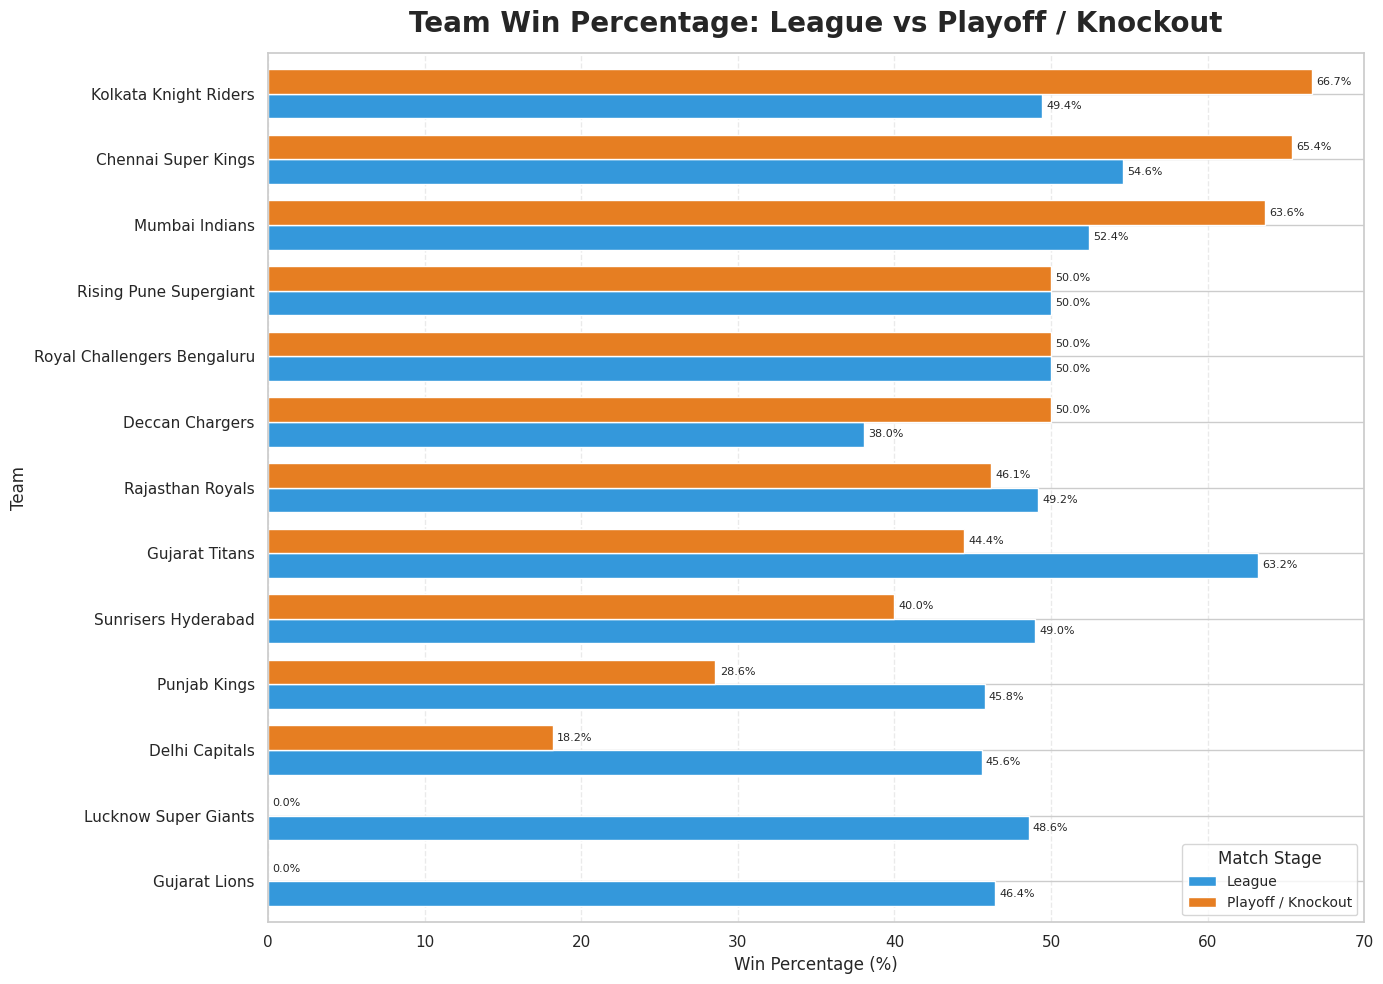

In [ ]:
# ============================================
# STEP 43 — TEAM PERFORMANCE BY MATCH STAGE
# ============================================

# Keep teams that have playoff/knockout records
playoff_teams = stage_team_performance[
    stage_team_performance["match_stage"] == "Playoff / Knockout"
]["Team"].unique()

plot_data = stage_team_performance[
    stage_team_performance["Team"].isin(playoff_teams)
].copy()

# Pivot for visualization
plot_pivot = plot_data.pivot(
    index="Team",
    columns="match_stage",
    values="Win_Percentage"
).fillna(0)

# Sort by playoff/knockout percentage
if "Playoff / Knockout" in plot_pivot.columns:
    plot_pivot = plot_pivot.sort_values(
        "Playoff / Knockout",
        ascending=True
    )

# --------------------------------------------
# VISUALIZATION
# --------------------------------------------

ax = plot_pivot.plot(
    kind="barh",
    figsize=(14, 10),
    color=["#3498DB", "#E67E22"],
    width=0.75
)

plt.title(
    "Team Win Percentage: League vs Playoff / Knockout",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Win Percentage (%)",
    fontsize=12
)

plt.ylabel(
    "Team",
    fontsize=12
)

plt.legend(
    title="Match Stage",
    fontsize=10
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [ ]:
# STEP 44: Season-wise Team Performance

# Create a team-season dataset from both team1 and team2
season_team = pd.concat([
    ipl_clean[["season_year", "team1", "winner"]].rename(
        columns={"team1": "Team"}
    ),
    ipl_clean[["season_year", "team2", "winner"]].rename(
        columns={"team2": "Team"}
    )
], ignore_index=True)

# Count matches played
season_team_performance = (
    season_team
    .groupby(["season_year", "Team"])
    .agg(
        Matches_Played=("Team", "size"),
        Wins=("winner", lambda x: (x == season_team.loc[x.index, "Team"]).sum())
    )
    .reset_index()
)

# Calculate win percentage
season_team_performance["Win_Percentage"] = (
    season_team_performance["Wins"]
    / season_team_performance["Matches_Played"]
    * 100
).round(2)

# Display results
season_team_performance = season_team_performance.sort_values(
    ["season_year", "Win_Percentage"],
    ascending=[True, False]
)

display(season_team_performance.head(20))

,season_year,Team,Matches_Played,Wins,Win_Percentage
6,2008,Rajasthan Royals,16,13,81.25
5,2008,Punjab Kings,15,10,66.67
0,2008,Chennai Super Kings,16,9,56.25
2,2008,Delhi Capitals,14,7,50.00
4,2008,Mumbai Indians,14,7,50.00
3,2008,Kolkata Knight Riders,13,6,46.15
7,2008,Royal Challengers Bengaluru,14,4,28.57
1,2008,Deccan Chargers,14,2,14.29
10,2009,Delhi Capitals,15,10,66.67
8,2009,Chennai Super Kings,14,8,57.14


In [ ]:
# STEP 44A: Find all unique team names

team_names = pd.concat([
    ipl_clean["team1"],
    ipl_clean["team2"],
    ipl_clean["toss_winner"],
    ipl_clean["winner"]
]).dropna()

team_names = sorted(team_names.unique())

print("Total unique team names:", len(team_names))
print("\nAll team names in the dataset:\n")

for i, team in enumerate(team_names, start=1):
    print(f"{i}. {team}")

Total unique team names: 16

All team names in the dataset:

1. Chennai Super Kings
2. Deccan Chargers
3. Delhi Capitals
4. Gujarat Lions
5. Gujarat Titans
6. Kochi Tuskers Kerala
7. Kolkata Knight Riders
8. Lucknow Super Giants
9. Mumbai Indians
10. No Winner
11. Pune Warriors
12. Punjab Kings
13. Rajasthan Royals
14. Rising Pune Supergiant
15. Royal Challengers Bengaluru
16. Sunrisers Hyderabad


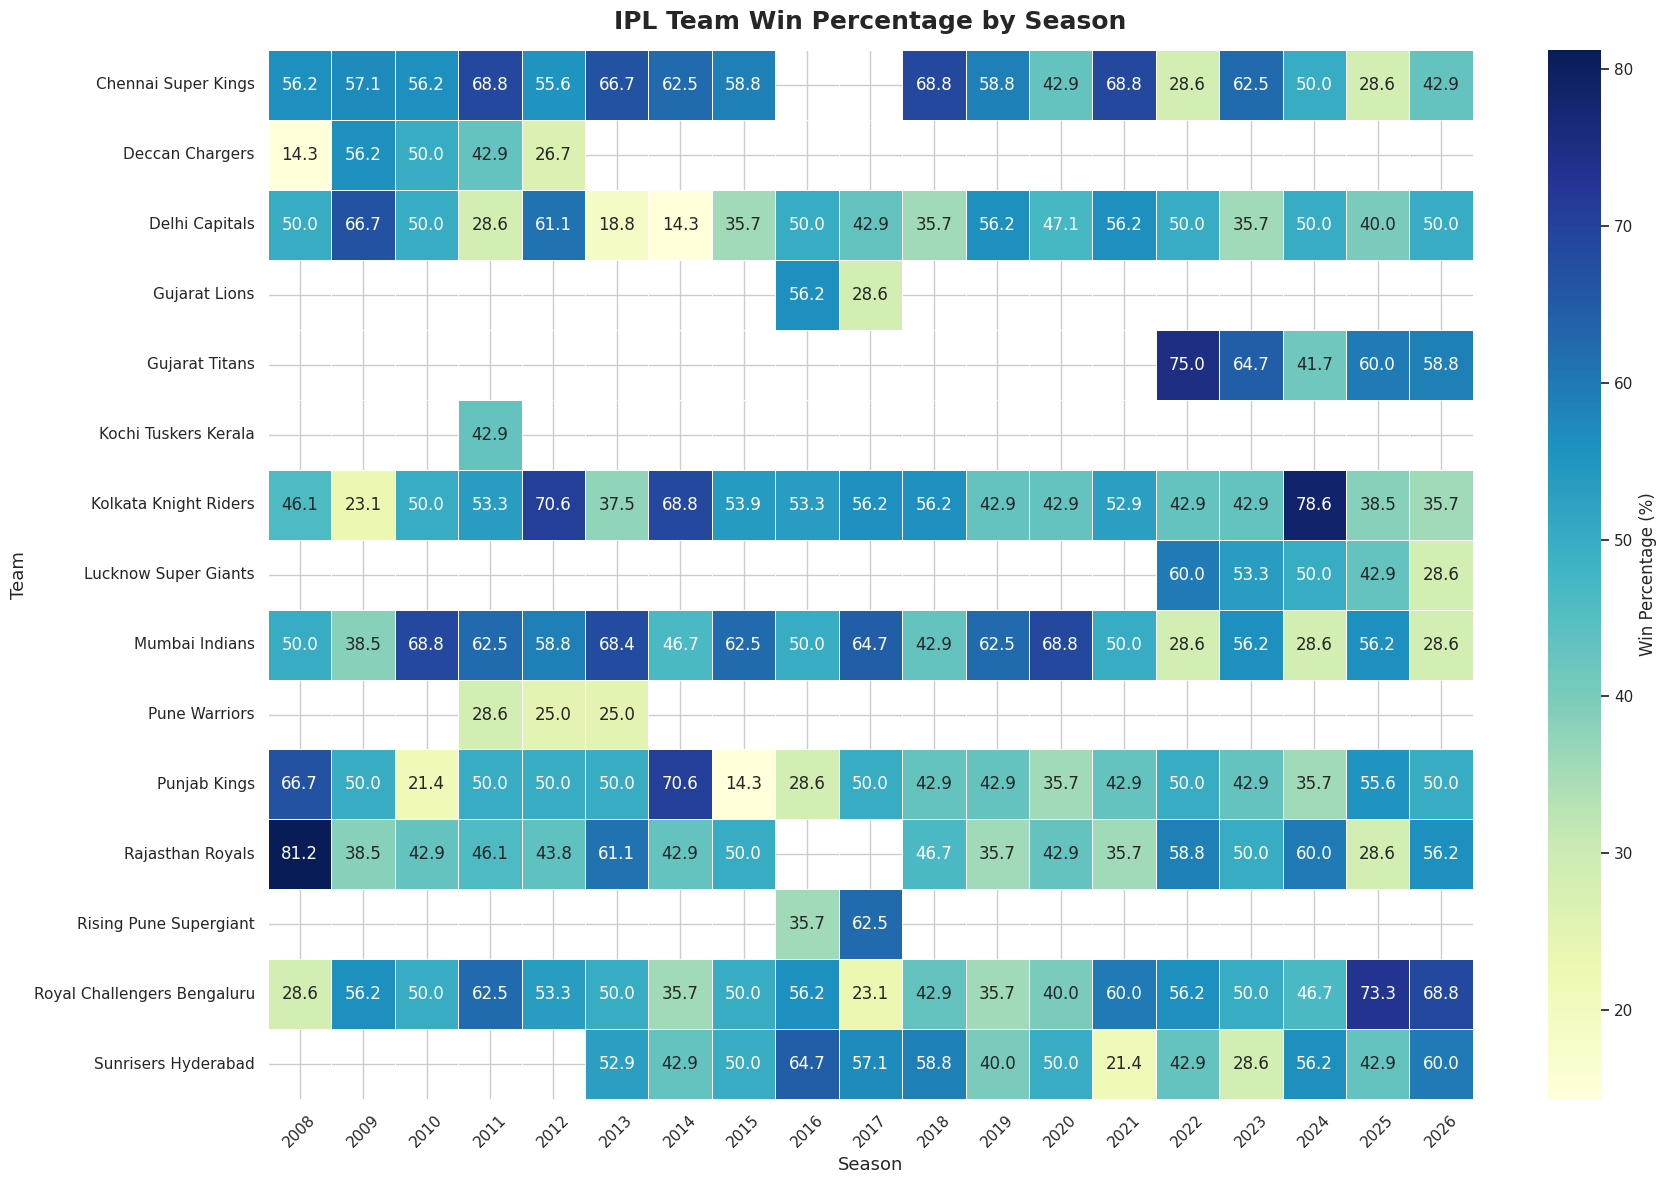

In [ ]:
# STEP 45: Season-wise Team Win Percentage Heatmap

# Create a Season × Team matrix
season_team_pivot = season_team_performance.pivot(
    index="Team",
    columns="season_year",
    values="Win_Percentage"
)

# Create heatmap
plt.figure(figsize=(18, 12))

sns.heatmap(
    season_team_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Win Percentage (%)"}
)

plt.title(
    "IPL Team Win Percentage by Season",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Season", fontsize=13)
plt.ylabel("Team", fontsize=13)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 46: Team participation across IPL seasons

# Combine both team columns
team_seasons = pd.concat([
    ipl_clean[["season_year", "team1"]].rename(columns={"team1": "Team"}),
    ipl_clean[["season_year", "team2"]].rename(columns={"team2": "Team"})
], ignore_index=True)

# Remove duplicate team-season combinations
team_seasons = team_seasons.drop_duplicates()

# Count seasons participated in by each team
team_participation = (
    team_seasons
    .groupby("Team")
    .agg(
        Seasons_Played=("season_year", "nunique"),
        First_Season=("season_year", "min"),
        Last_Season=("season_year", "max")
    )
    .reset_index()
    .sort_values("Seasons_Played", ascending=False)
)

display(team_participation)

,Team,Seasons_Played,First_Season,Last_Season
2,Delhi Capitals,19,2008,2026
6,Kolkata Knight Riders,19,2008,2026
8,Mumbai Indians,19,2008,2026
10,Punjab Kings,19,2008,2026
13,Royal Challengers Bengaluru,19,2008,2026
11,Rajasthan Royals,17,2008,2026
0,Chennai Super Kings,17,2008,2026
14,Sunrisers Hyderabad,14,2013,2026
7,Lucknow Super Giants,5,2022,2026
4,Gujarat Titans,5,2022,2026


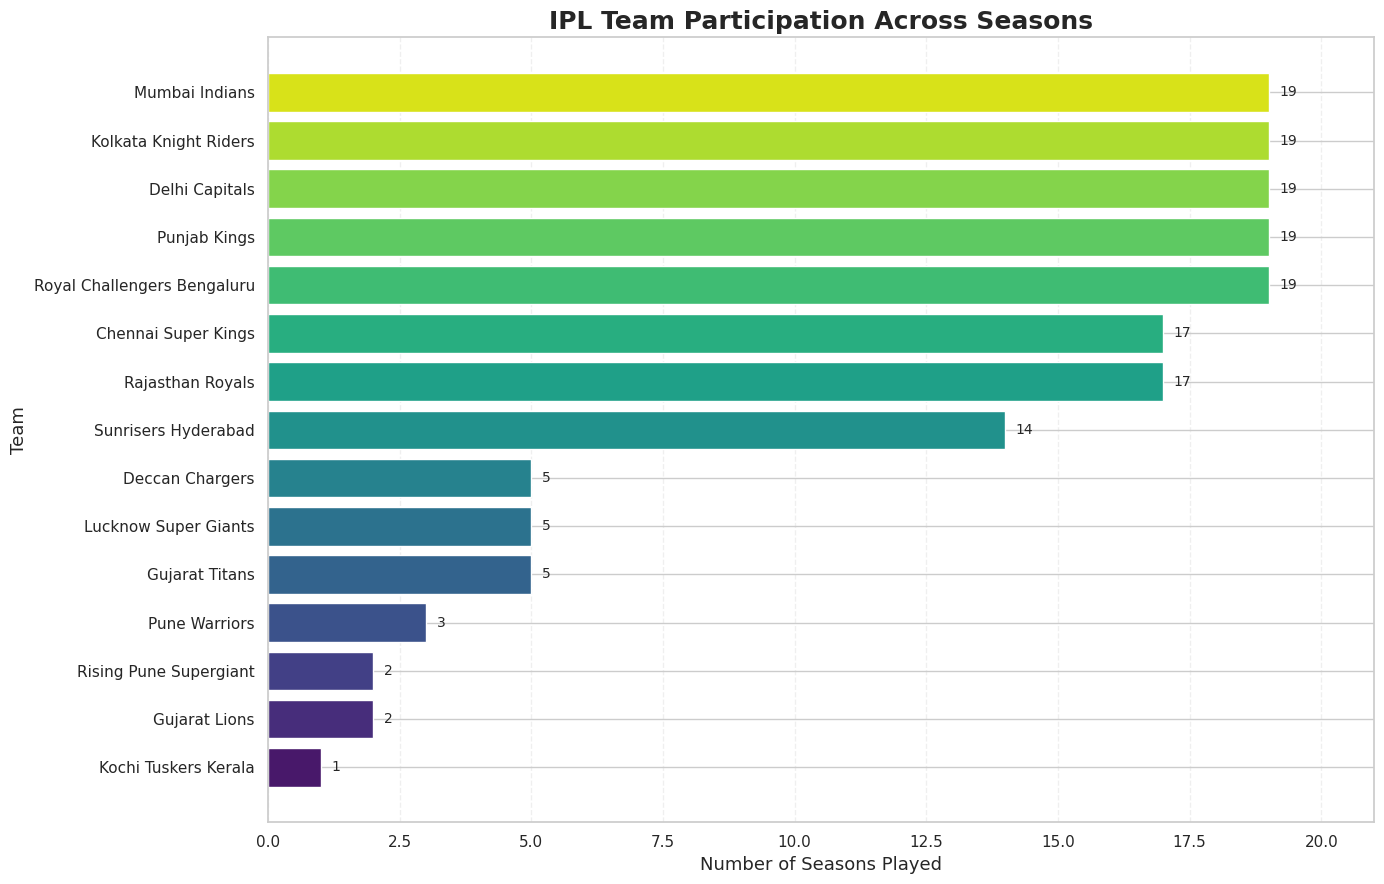

In [ ]:
# STEP 47: Visualize team participation across IPL seasons

plot_data = team_participation.sort_values(
    "Seasons_Played",
    ascending=True
)

plt.figure(figsize=(14, 9))

bars = plt.barh(
    plot_data["Team"],
    plot_data["Seasons_Played"],
    color=sns.color_palette("viridis", len(plot_data))
)

# Add values at the end of each bar
for bar, value in zip(bars, plot_data["Seasons_Played"]):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontsize=10
    )

plt.title(
    "IPL Team Participation Across Seasons",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Seasons Played", fontsize=13)
plt.ylabel("Team", fontsize=13)

plt.xlim(0, plot_data["Seasons_Played"].max() + 2)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 48: Season-wise team wins

# Keep only matches that have a winner
team_wins_by_season = (
    ipl_clean[ipl_clean["winner"] != "No Winner"]
    .groupby(["season_year", "winner"])
    .size()
    .reset_index(name="Wins")
)

# Rename winner column
team_wins_by_season = team_wins_by_season.rename(
    columns={"winner": "Team"}
)

# Sort by season and number of wins
team_wins_by_season = team_wins_by_season.sort_values(
    ["season_year", "Wins"],
    ascending=[True, False]
)

display(team_wins_by_season.head(30))

,season_year,Team,Wins
6,2008,Rajasthan Royals,13
5,2008,Punjab Kings,10
0,2008,Chennai Super Kings,9
2,2008,Delhi Capitals,7
4,2008,Mumbai Indians,7
3,2008,Kolkata Knight Riders,6
7,2008,Royal Challengers Bengaluru,4
1,2008,Deccan Chargers,2
10,2009,Delhi Capitals,10
9,2009,Deccan Chargers,9


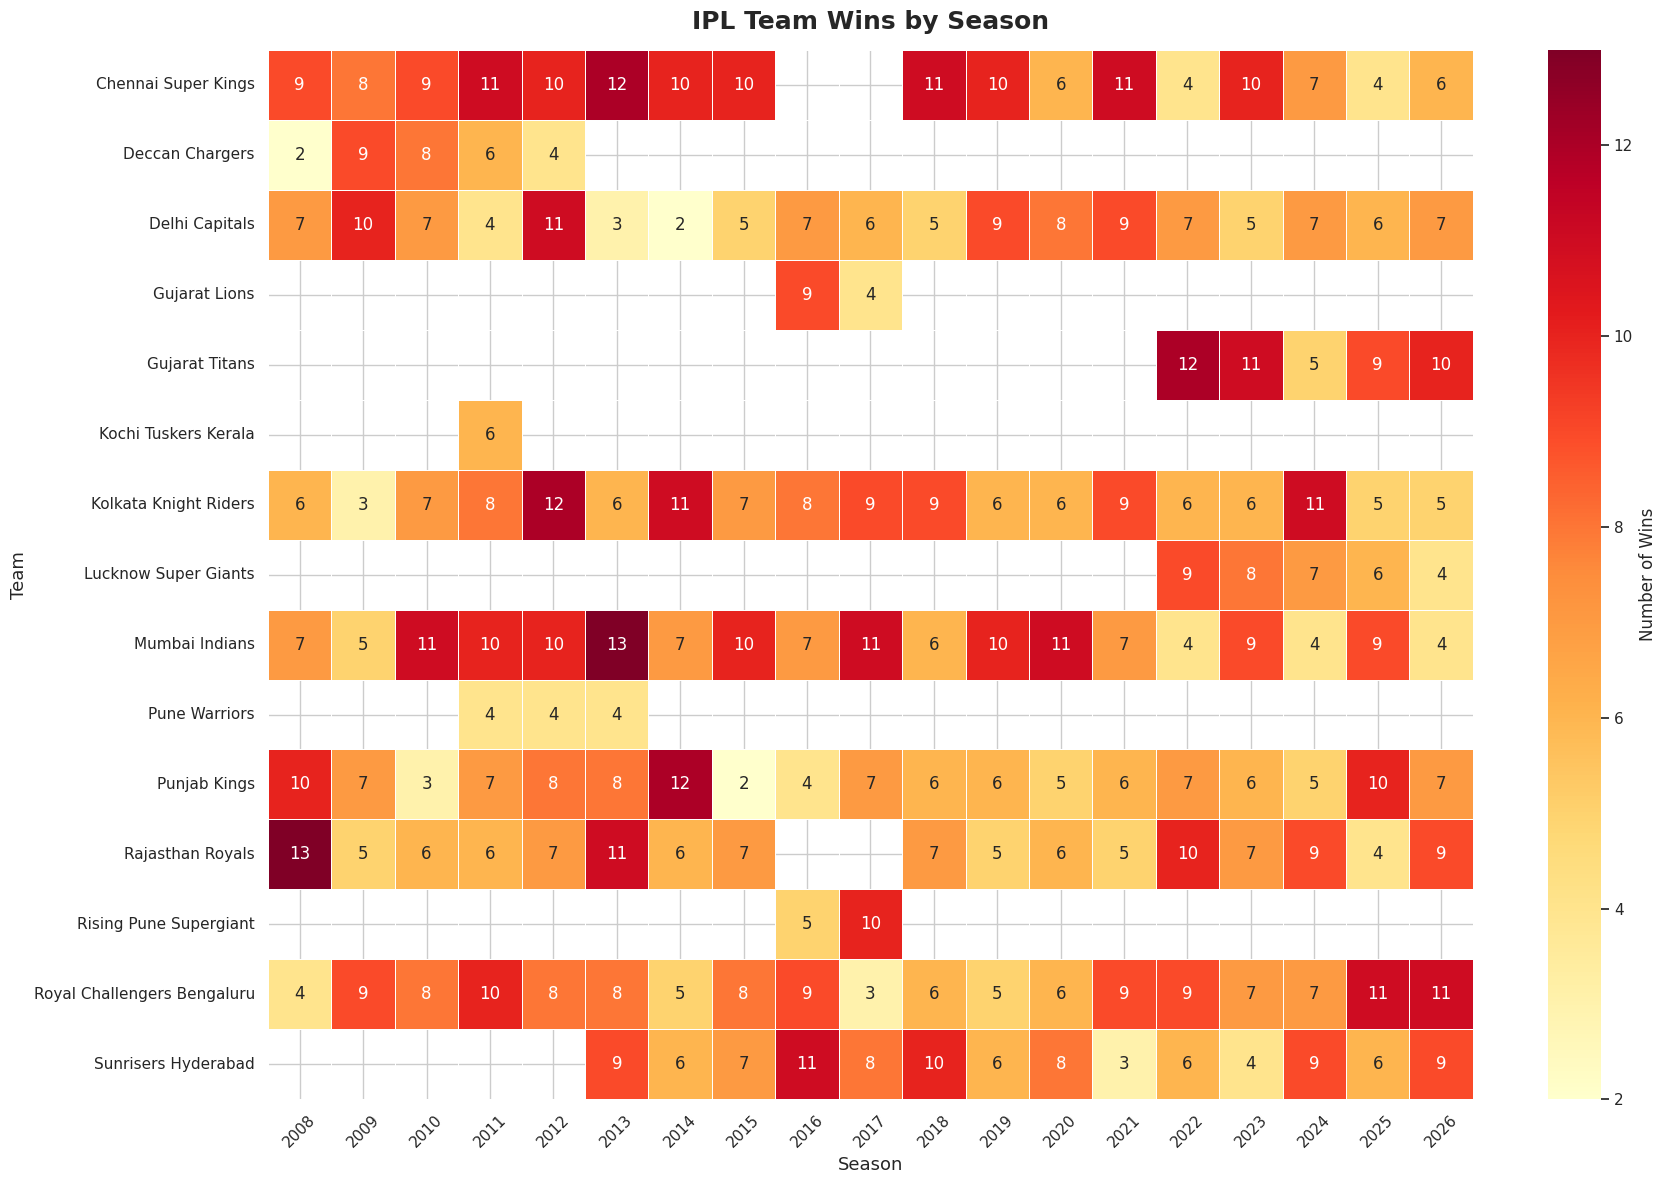

In [ ]:
# STEP 49: Season-wise Team Wins Heatmap

# Convert data into Season × Team format
wins_pivot = team_wins_by_season.pivot(
    index="Team",
    columns="season_year",
    values="Wins"
)

# Create the heatmap
plt.figure(figsize=(18, 12))

sns.heatmap(
    wins_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Number of Wins"}
)

plt.title(
    "IPL Team Wins by Season",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Season", fontsize=13)
plt.ylabel("Team", fontsize=13)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 50: Complete season-wise team performance

# Create one row for each team participating in each match
team_matches_season = pd.concat([
    ipl_clean[
        ["season_year", "team1", "winner"]
    ].rename(columns={"team1": "Team"}),

    ipl_clean[
        ["season_year", "team2", "winner"]
    ].rename(columns={"team2": "Team"})
], ignore_index=True)

# Matches played
season_performance = (
    team_matches_season
    .groupby(["season_year", "Team"])
    .agg(
        Matches_Played=("Team", "size"),
        Wins=("winner", lambda x: (x == team_matches_season.loc[x.index, "Team"]).sum()),
        No_Result=("winner", lambda x: (x == "No Winner").sum())
    )
    .reset_index()
)

# Calculate losses
season_performance["Losses"] = (
    season_performance["Matches_Played"]
    - season_performance["Wins"]
    - season_performance["No_Result"]
)

# Calculate win percentage excluding no-result matches
season_performance["Win_Percentage"] = (
    season_performance["Wins"]
    / (
        season_performance["Matches_Played"]
        - season_performance["No_Result"]
    )
    * 100
).round(2)

# Arrange columns
season_performance = season_performance[
    [
        "season_year",
        "Team",
        "Matches_Played",
        "Wins",
        "Losses",
        "No_Result",
        "Win_Percentage"
    ]
]

# Sort results
season_performance = season_performance.sort_values(
    ["season_year", "Win_Percentage"],
    ascending=[True, False]
)

display(season_performance.head(30))

,season_year,Team,Matches_Played,Wins,Losses,No_Result,Win_Percentage
6,2008,Rajasthan Royals,16,13,3,0,81.25
5,2008,Punjab Kings,15,10,5,0,66.67
0,2008,Chennai Super Kings,16,9,7,0,56.25
2,2008,Delhi Capitals,14,7,7,0,50.00
4,2008,Mumbai Indians,14,7,7,0,50.00
3,2008,Kolkata Knight Riders,13,6,7,0,46.15
7,2008,Royal Challengers Bengaluru,14,4,10,0,28.57
1,2008,Deccan Chargers,14,2,12,0,14.29
10,2009,Delhi Capitals,15,10,5,0,66.67
8,2009,Chennai Super Kings,14,8,6,0,57.14


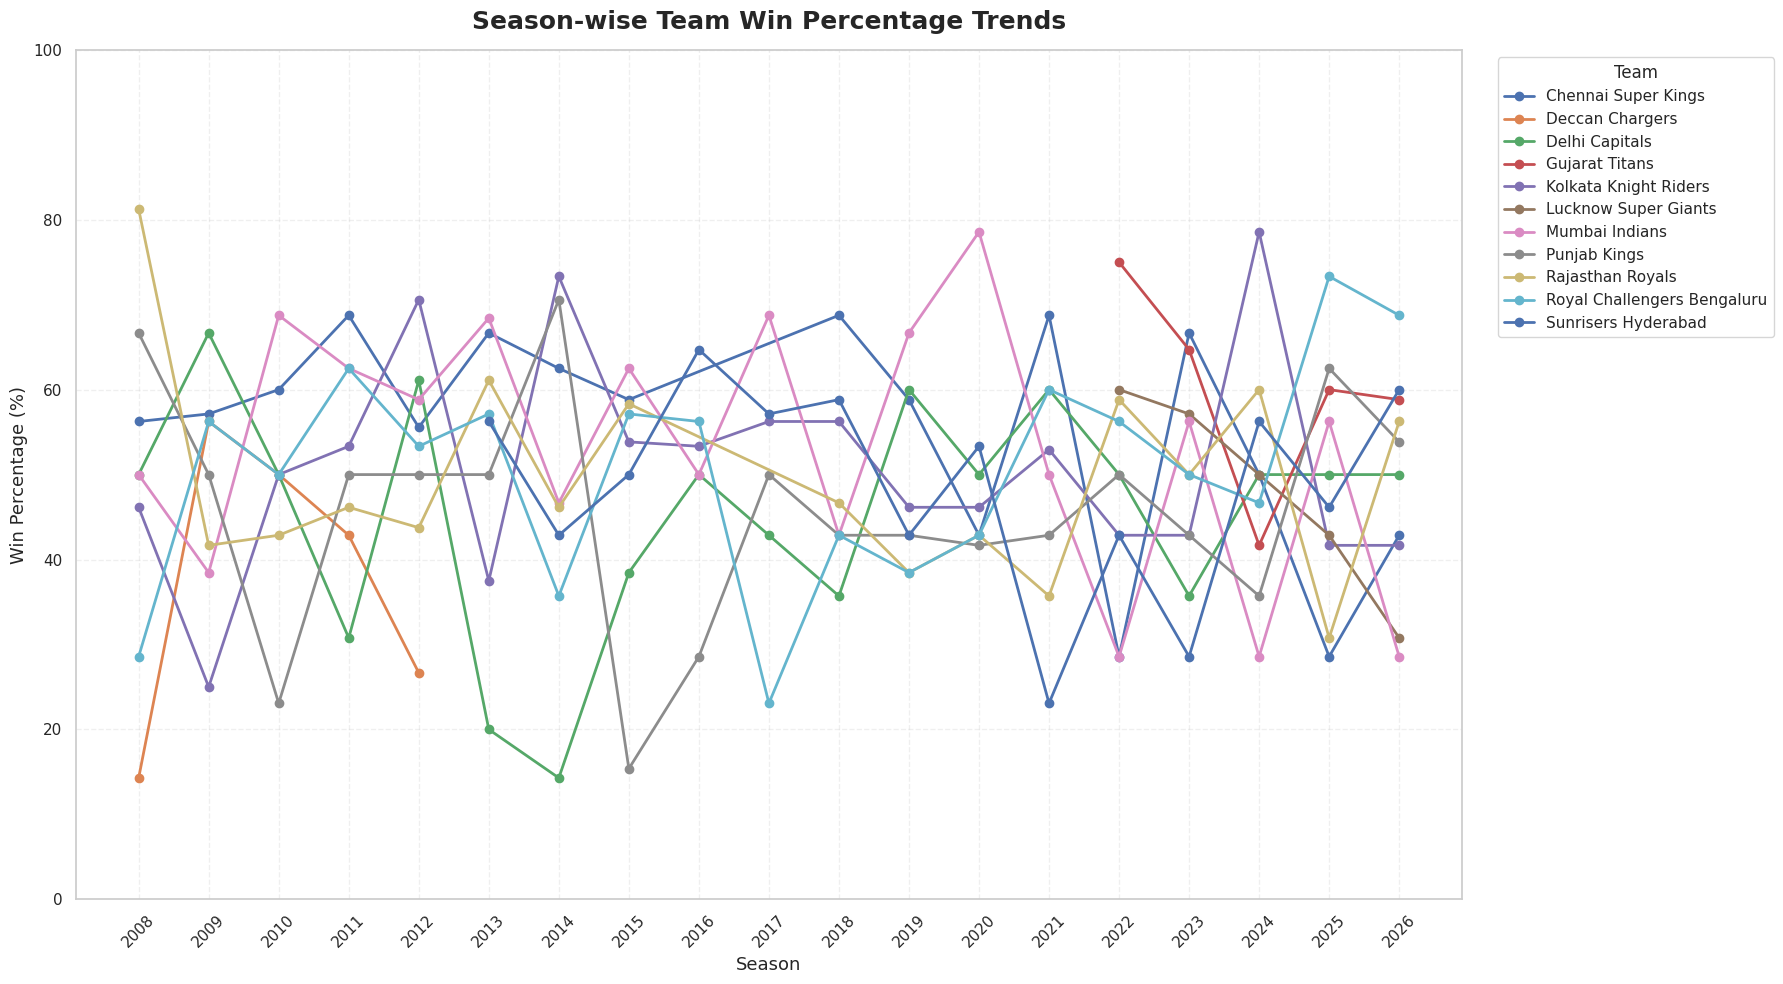

In [ ]:
# STEP 51: Season-wise team win percentage trend

# Find teams that participated in at least 5 seasons
regular_teams = (
    season_performance.groupby("Team")["season_year"]
    .nunique()
)

regular_teams = regular_teams[
    regular_teams >= 5
].index

plot_data = season_performance[
    season_performance["Team"].isin(regular_teams)
].copy()

# Create line chart
plt.figure(figsize=(18, 10))

for team in sorted(plot_data["Team"].unique()):
    team_data = plot_data[
        plot_data["Team"] == team
    ].sort_values("season_year")

    plt.plot(
        team_data["season_year"],
        team_data["Win_Percentage"],
        marker="o",
        linewidth=2,
        label=team
    )

plt.title(
    "Season-wise Team Win Percentage Trends",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Season", fontsize=13)
plt.ylabel("Win Percentage (%)", fontsize=13)

plt.xticks(sorted(plot_data["season_year"].unique()), rotation=45)

plt.ylim(0, 100)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Team"
)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 52: Match result type analysis

result_type_counts = (
    ipl_clean["result_category"]
    .value_counts()
    .reset_index()
)

result_type_counts.columns = [
    "Result_Type",
    "Matches"
]

# Calculate percentage
result_type_counts["Percentage"] = (
    result_type_counts["Matches"]
    / result_type_counts["Matches"].sum()
    * 100
).round(2)

display(result_type_counts)

,Result_Type,Matches,Percentage
0,Win by Wickets,660,53.10
1,Win by Runs,558,44.89
2,Other / No Result,25,2.01


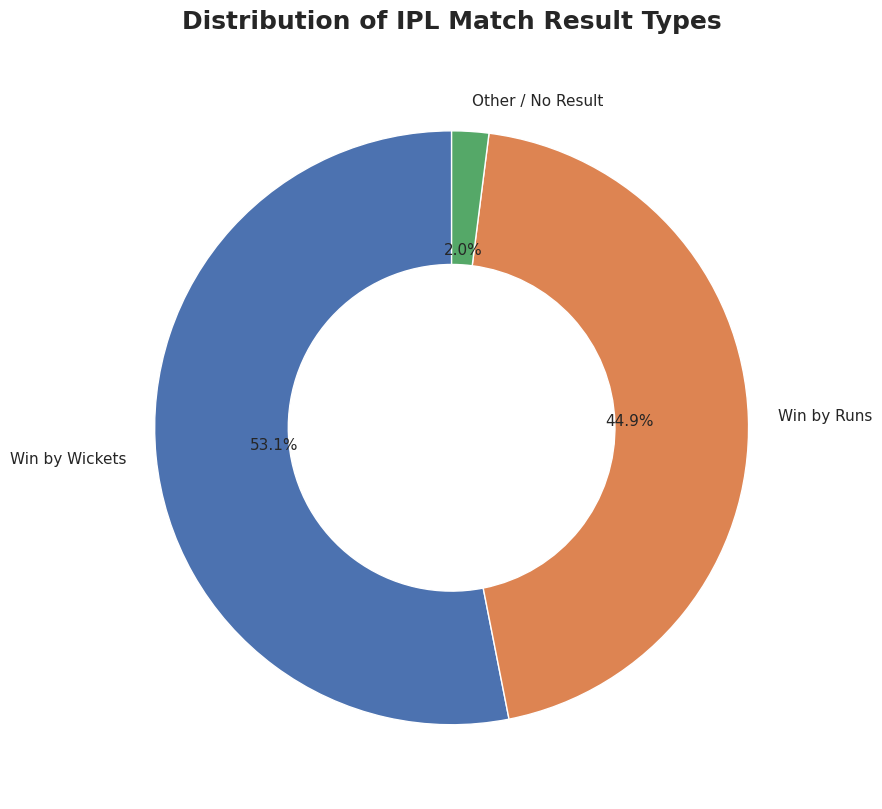

In [ ]:
# STEP 53: Match result type visualization

labels = result_type_counts["Result_Type"]
values = result_type_counts["Matches"]

plt.figure(figsize=(9, 9))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor="white"),
    textprops={"fontsize": 11}
)

plt.title(
    "Distribution of IPL Match Result Types",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 54: Win margin analysis

# Run-margin matches
run_margin_data = ipl_clean[
    ipl_clean["win_by_runs"] > 0
]["win_by_runs"].dropna()

# Wicket-margin matches
wicket_margin_data = ipl_clean[
    ipl_clean["win_by_wickets"] > 0
]["win_by_wickets"].dropna()

# Summary statistics
margin_summary = pd.DataFrame({
    "Margin_Type": ["Runs", "Wickets"],
    "Matches": [
        len(run_margin_data),
        len(wicket_margin_data)
    ],
    "Average_Margin": [
        round(run_margin_data.mean(), 2),
        round(wicket_margin_data.mean(), 2)
    ],
    "Median_Margin": [
        run_margin_data.median(),
        wicket_margin_data.median()
    ],
    "Minimum_Margin": [
        run_margin_data.min(),
        wicket_margin_data.min()
    ],
    "Maximum_Margin": [
        run_margin_data.max(),
        wicket_margin_data.max()
    ]
})

display(margin_summary)

,Margin_Type,Matches,Average_Margin,Median_Margin,Minimum_Margin,Maximum_Margin
0,Runs,558,31.04,23.0,1,146
1,Wickets,660,6.17,6.0,1,10


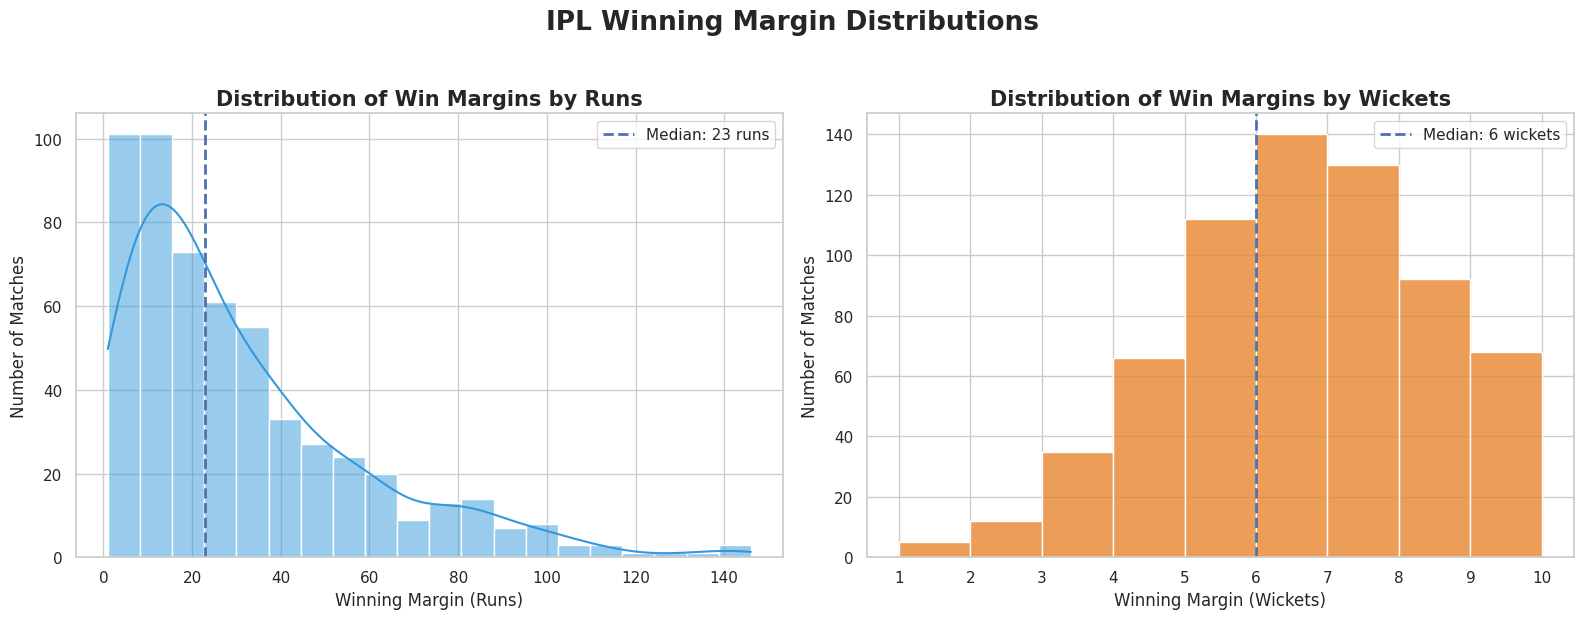

In [ ]:
# STEP 55: Visualize winning margin distributions

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------
# 1. Distribution of run margins
# -------------------------------
sns.histplot(
    run_margin_data,
    bins=20,
    kde=True,
    ax=axes[0],
    color="#3498DB"
)

axes[0].axvline(
    run_margin_data.median(),
    linestyle="--",
    linewidth=2,
    label=f"Median: {run_margin_data.median():.0f} runs"
)

axes[0].set_title(
    "Distribution of Win Margins by Runs",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Winning Margin (Runs)")
axes[0].set_ylabel("Number of Matches")
axes[0].legend()


# --------------------------------
# 2. Distribution of wicket margins
# --------------------------------
sns.histplot(
    wicket_margin_data,
    bins=9,
    kde=False,
    ax=axes[1],
    color="#E67E22"
)

axes[1].axvline(
    wicket_margin_data.median(),
    linestyle="--",
    linewidth=2,
    label=f"Median: {wicket_margin_data.median():.0f} wickets"
)

axes[1].set_title(
    "Distribution of Win Margins by Wickets",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Winning Margin (Wickets)")
axes[1].set_ylabel("Number of Matches")
axes[1].set_xticks(range(1, 11))
axes[1].legend()

plt.suptitle(
    "IPL Winning Margin Distributions",
    fontsize=19,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 56: Player of the Match analysis

pom_data = (
    ipl_clean[
        (ipl_clean["player_of_match"].notna()) &
        (ipl_clean["player_of_match"] != "Not Awarded")
    ]
    .groupby("player_of_match")
    .size()
    .reset_index(name="Awards")
)

# Calculate percentage of all awarded matches
pom_data["Percentage"] = (
    pom_data["Awards"]
    / pom_data["Awards"].sum()
    * 100
).round(2)

# Sort by number of awards
pom_data = pom_data.sort_values(
    "Awards",
    ascending=False
).reset_index(drop=True)

display(pom_data.head(20))

,player_of_match,Awards,Percentage
0,AB de Villiers,25,2.03
1,V Kohli,22,1.78
2,CH Gayle,22,1.78
3,RG Sharma,21,1.70
4,MS Dhoni,18,1.46
5,SP Narine,18,1.46
6,DA Warner,18,1.46
7,RA Jadeja,17,1.38
8,KL Rahul,17,1.38
9,SR Watson,16,1.30


In [ ]:
# STEP 58: Player of the Match awards by season

pom_season = (
    ipl_clean[
        ipl_clean["player_of_match"] != "Not Awarded"
    ]
    .groupby(["season_year", "player_of_match"])
    .size()
    .reset_index(name="Awards")
)

# Find the top 5 players in each season
pom_top_by_season = (
    pom_season
    .sort_values(
        ["season_year", "Awards"],
        ascending=[True, False]
    )
    .groupby("season_year")
    .head(5)
    .reset_index(drop=True)
)

display(pom_top_by_season)

,season_year,player_of_match,Awards
0,2008,SE Marsh,5
1,2008,SR Watson,4
2,2008,YK Pathan,4
3,2008,AC Gilchrist,2
4,2008,M Ntini,2
...,...,...,...
90,2026,Ishan Kishan,3
91,2026,SV Samson,3
92,2026,V Kohli,3
93,2026,V Suryavanshi,3


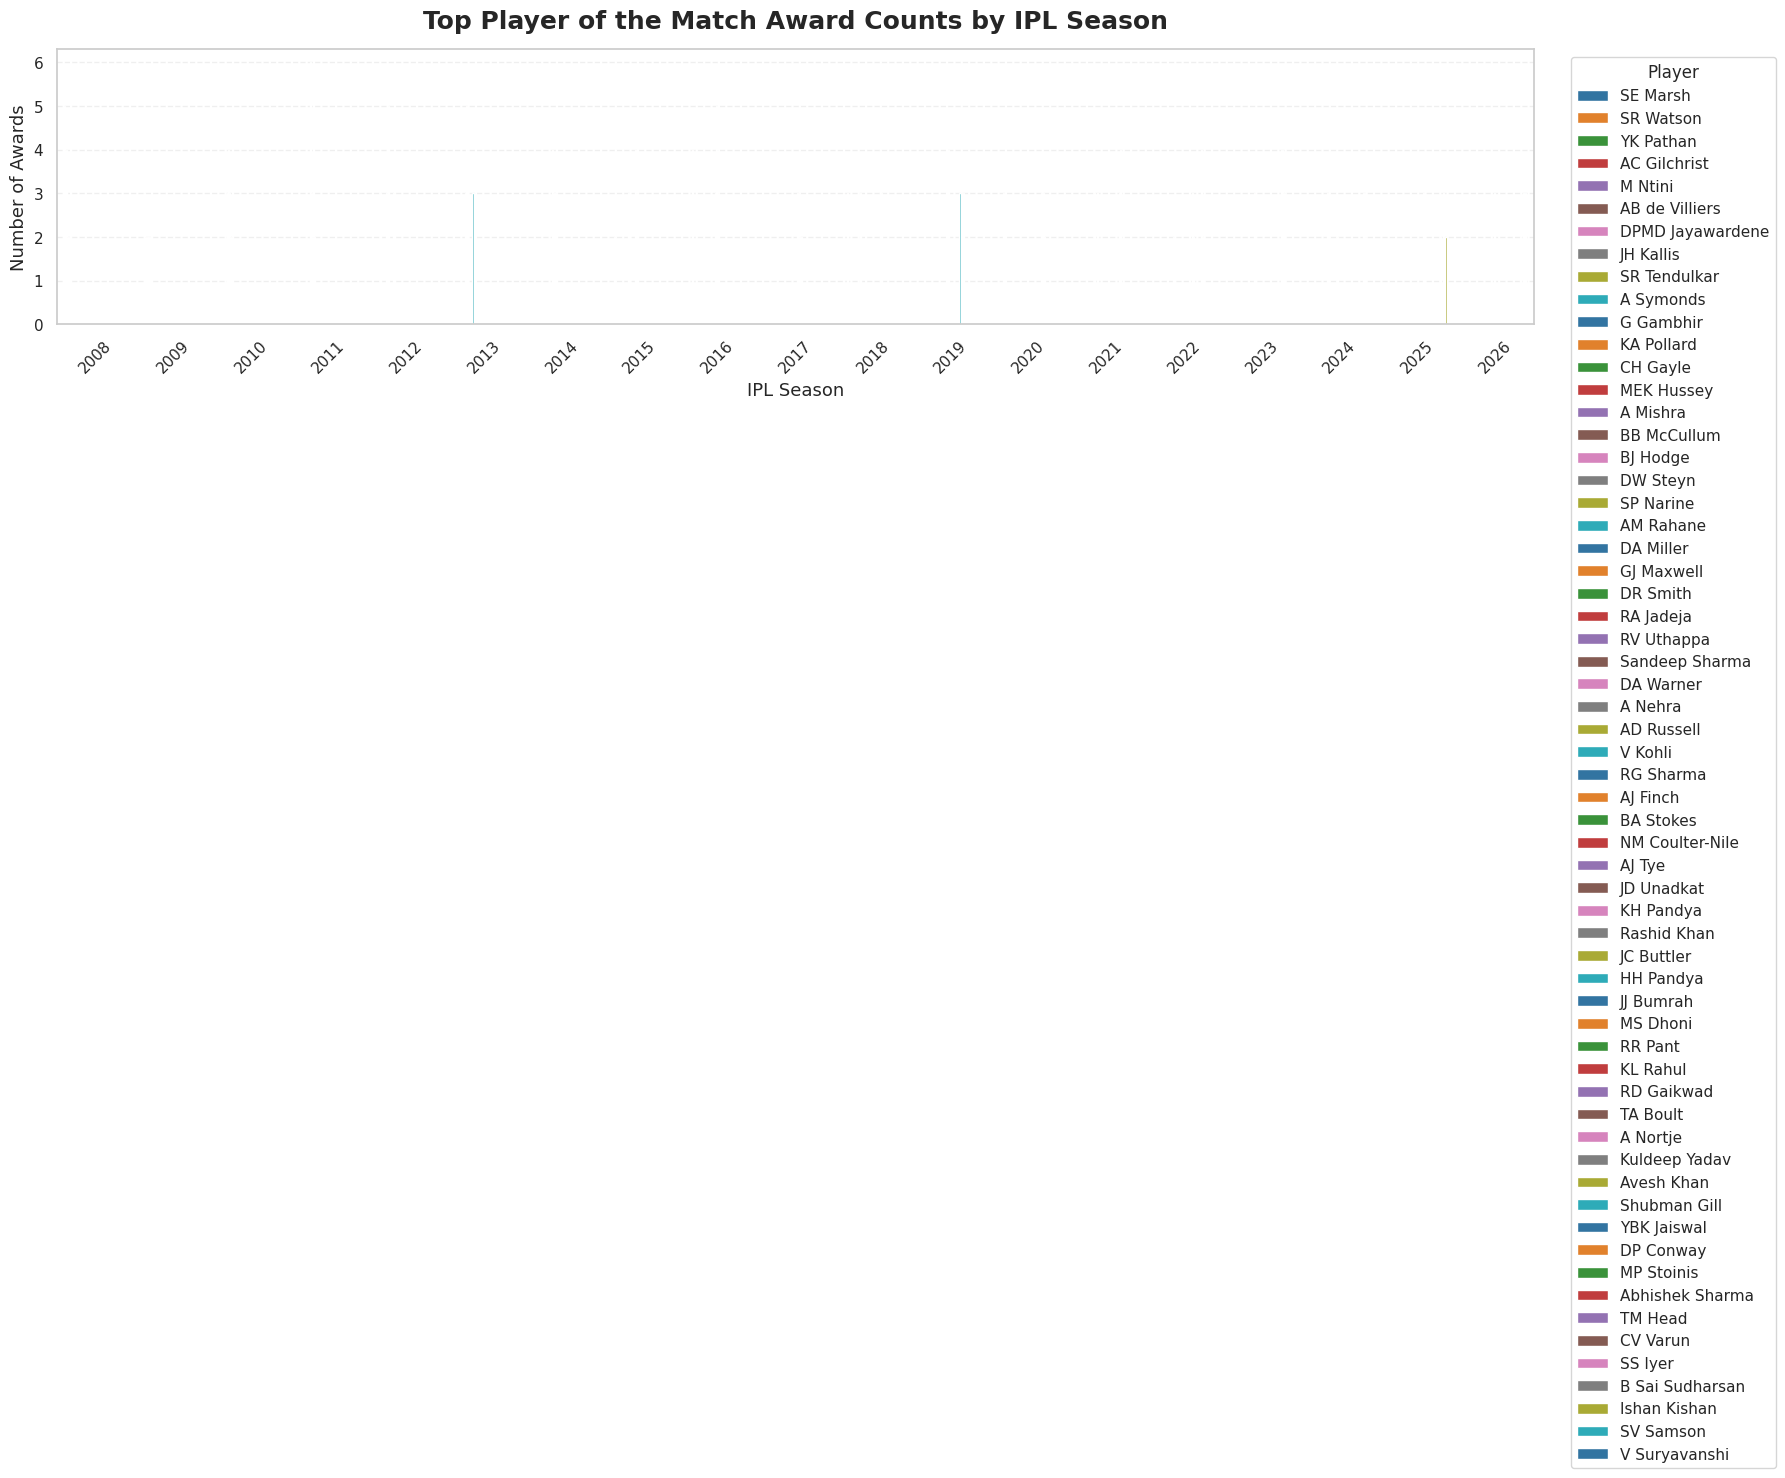

In [ ]:
# STEP 59: Season-wise Player of the Match visualization

# Keep only seasons that have Player of the Match data
plot_data = pom_top_by_season.copy()

plt.figure(figsize=(18, 10))

sns.barplot(
    data=plot_data,
    x="season_year",
    y="Awards",
    hue="player_of_match",
    palette="tab10"
)

plt.title(
    "Top Player of the Match Award Counts by IPL Season",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("IPL Season", fontsize=13)
plt.ylabel("Number of Awards", fontsize=13)

plt.xticks(rotation=45)

plt.legend(
    title="Player",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 60: Venue analysis

venue_analysis = (
    ipl_clean["venue"]
    .value_counts()
    .reset_index()
)

venue_analysis.columns = [
    "Venue",
    "Matches"
]

# Calculate percentage of total matches
venue_analysis["Percentage"] = (
    venue_analysis["Matches"]
    / venue_analysis["Matches"].sum()
    * 100
).round(2)

display(venue_analysis.head(20))

,Venue,Matches,Percentage
0,Eden Gardens,77,6.19
1,Wankhede Stadium,73,5.87
2,M Chinnaswamy Stadium,65,5.23
3,Feroz Shah Kotla,60,4.83
4,"Wankhede Stadium, Mumbai",59,4.75
5,"Rajiv Gandhi International Stadium, Uppal",49,3.94
6,"MA Chidambaram Stadium, Chepauk",48,3.86
7,Sawai Mansingh Stadium,47,3.78
8,Dubai International Cricket Stadium,46,3.70
9,"MA Chidambaram Stadium, Chepauk, Chennai",41,3.30


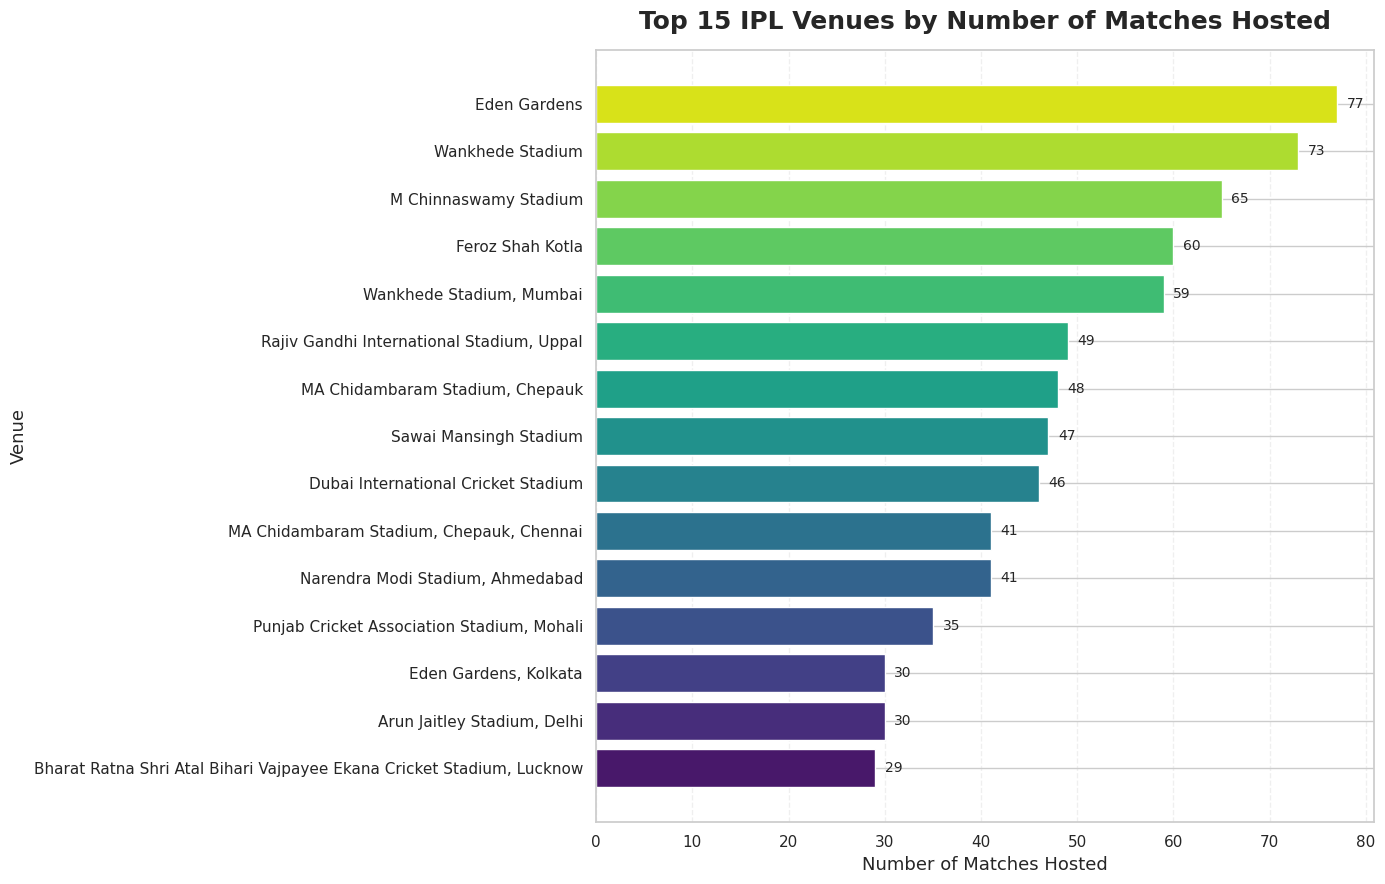

In [ ]:
# STEP 61: Top 15 IPL venues by matches hosted

top_venues = (
    venue_analysis
    .head(15)
    .sort_values("Matches", ascending=True)
)

plt.figure(figsize=(14, 9))

bars = plt.barh(
    top_venues["Venue"],
    top_venues["Matches"],
    color=sns.color_palette("viridis", len(top_venues))
)

# Add match counts
for bar, value in zip(bars, top_venues["Matches"]):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontsize=10
    )

plt.title(
    "Top 15 IPL Venues by Number of Matches Hosted",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Matches Hosted", fontsize=13)
plt.ylabel("Venue", fontsize=13)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()


In [ ]:
# STEP 62: Toss decision vs match result

# Recalculate this feature after team-name standardization
toss_analysis = ipl_clean.copy()

toss_analysis["Toss_Match_Result"] = np.where(
    toss_analysis["toss_winner"] == "No Winner",
    "Not Applicable",
    np.where(
        toss_analysis["toss_winner"] == toss_analysis["winner"],
        "Toss Winner Won",
        "Toss Winner Lost"
    )
)

# Remove matches where there was no winner
toss_result_analysis = toss_analysis[
    toss_analysis["Toss_Match_Result"] != "Not Applicable"
].copy()

# Create summary
toss_result_summary = pd.crosstab(
    toss_result_analysis["toss_decision"],
    toss_result_analysis["Toss_Match_Result"]
)

# Add percentages within each toss decision
toss_result_percentage = (
    pd.crosstab(
        toss_result_analysis["toss_decision"],
        toss_result_analysis["Toss_Match_Result"],
        normalize="index"
    ) * 100
).round(2)

print("Toss Decision vs Match Result — Counts")
display(toss_result_summary)

print("\nToss Decision vs Match Result — Percentages")
display(toss_result_percentage)


Toss Decision vs Match Result — Counts


Toss_Match_Result,Toss Winner Lost,Toss Winner Won
toss_decision,,
bat,233,185
field,382,443



Toss Decision vs Match Result — Percentages


Toss_Match_Result,Toss Winner Lost,Toss Winner Won
toss_decision,,
bat,55.74,44.26
field,46.30,53.70


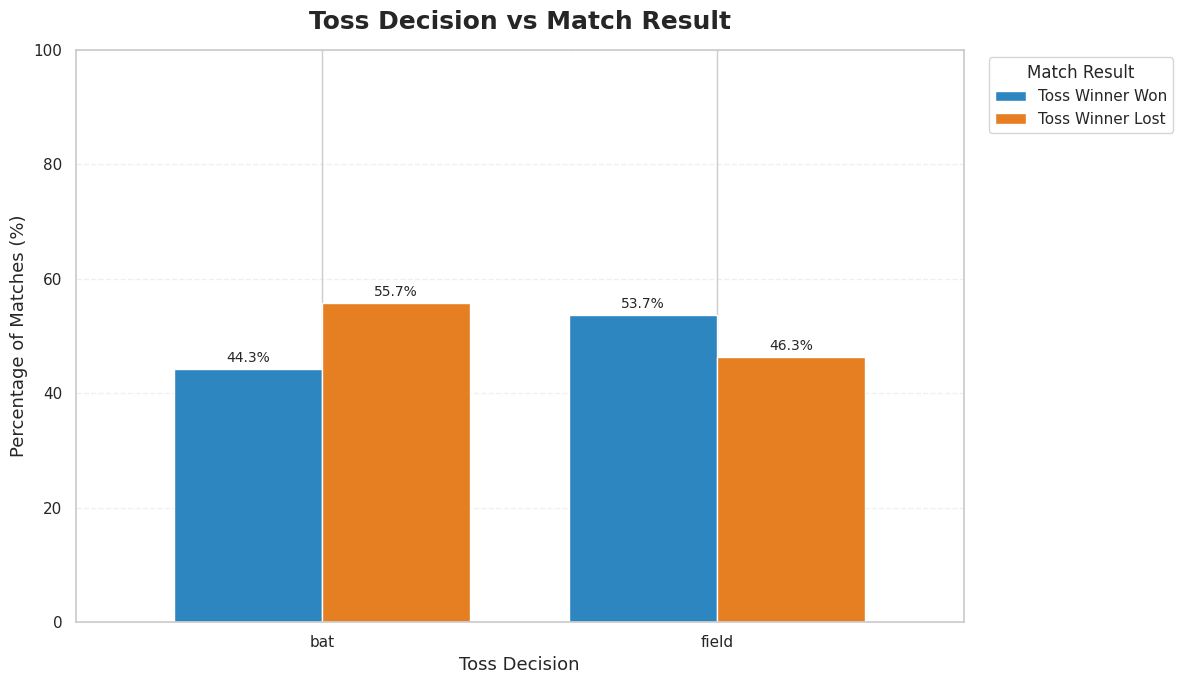

In [ ]:
# STEP 63: Toss decision vs match result visualization

plot_data = toss_result_percentage.reset_index()

# Keep only the two relevant outcomes
outcome_columns = [
    "Toss Winner Won",
    "Toss Winner Lost"
]

plot_data = plot_data[
    ["toss_decision"] + outcome_columns
]

ax = plot_data.set_index("toss_decision").plot(
    kind="bar",
    figsize=(12, 7),
    color=["#2E86C1", "#E67E22"],
    width=0.75
)

plt.title(
    "Toss Decision vs Match Result",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Toss Decision", fontsize=13)
plt.ylabel("Percentage of Matches (%)", fontsize=13)

plt.xticks(rotation=0)
plt.ylim(0, 100)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10
    )

plt.legend(
    title="Match Result",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 64: Batting first vs fielding first

# Work only with matches having a recorded winner
bat_field_data = ipl_clean[
    ipl_clean["winner"] != "No Winner"
].copy()

# Check whether toss winner won the match
bat_field_data["Toss_Winner_Won"] = (
    bat_field_data["toss_winner"] == bat_field_data["winner"]
)

# Aggregate results by toss decision
bat_field_summary = (
    bat_field_data
    .groupby("toss_decision")
    .agg(
        Matches=("toss_decision", "size"),
        Toss_Winner_Wins=("Toss_Winner_Won", "sum")
    )
    .reset_index()
)

# Calculate losses
bat_field_summary["Toss_Winner_Losses"] = (
    bat_field_summary["Matches"]
    - bat_field_summary["Toss_Winner_Wins"]
)

# Calculate win percentage
bat_field_summary["Win_Percentage"] = (
    bat_field_summary["Toss_Winner_Wins"]
    / bat_field_summary["Matches"]
    * 100
).round(2)

display(bat_field_summary)

,toss_decision,Matches,Toss_Winner_Wins,Toss_Winner_Losses,Win_Percentage
0,bat,408,185,223,45.34
1,field,810,443,367,54.69


In [ ]:
# STEP 65: Season-wise scoring trends

# Calculate total runs scored in each match
ipl_clean["total_match_runs"] = (
    ipl_clean["team1_runs"].fillna(0)
    + ipl_clean["team2_runs"].fillna(0)
)

# Aggregate scoring by season
season_scoring = (
    ipl_clean
    .groupby("season_year")
    .agg(
        Matches=("season_year", "size"),
        Total_Runs=("total_match_runs", "sum"),
        Average_Runs_Per_Match=("total_match_runs", "mean")
    )
    .reset_index()
)

# Round average
season_scoring["Average_Runs_Per_Match"] = (
    season_scoring["Average_Runs_Per_Match"]
    .round(2)
)

display(season_scoring)

,season_year,Matches,Total_Runs,Average_Runs_Per_Match
0,2008,58,17937,309.26
1,2009,57,16353,286.89
2,2010,60,18883,314.72
3,2011,73,21154,289.78
4,2012,74,22453,303.42
5,2013,76,22602,297.39
6,2014,60,18931,315.52
7,2015,59,18353,311.07
8,2016,60,18862,314.37
9,2017,59,18786,318.41


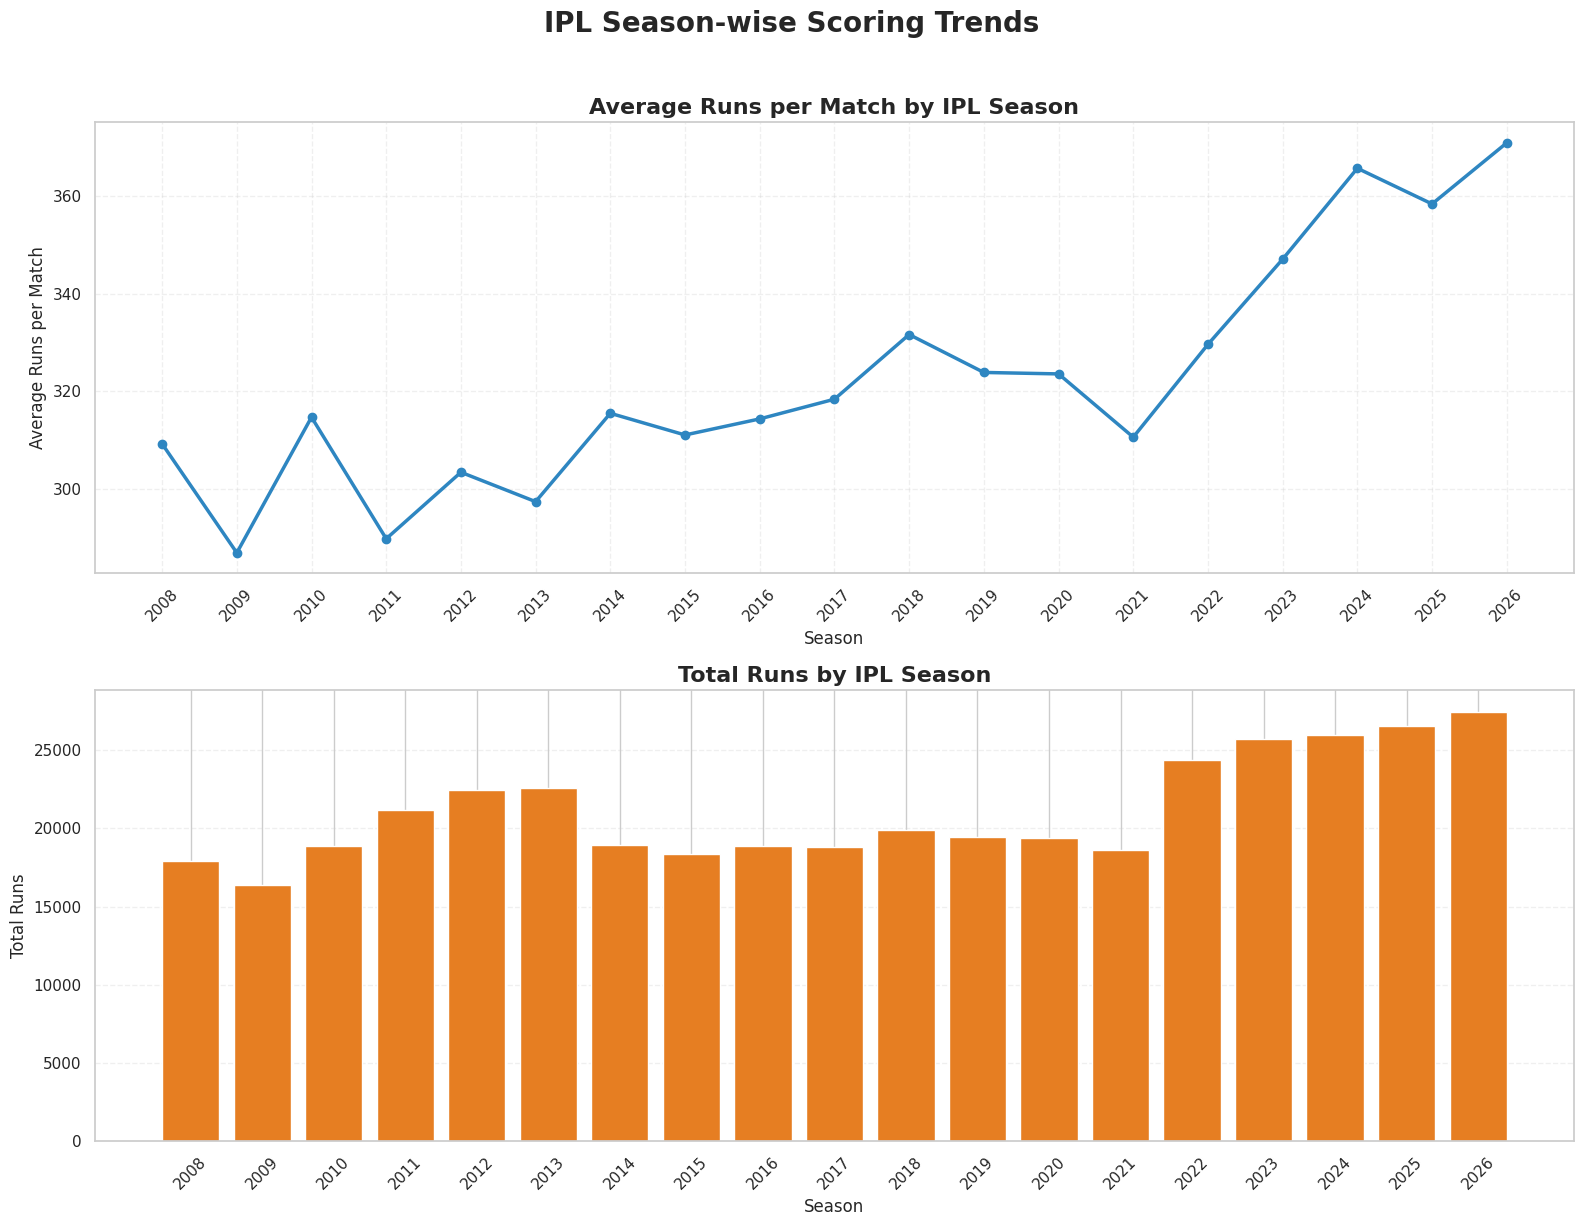

In [ ]:
# STEP 66: Season-wise scoring visualization

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# -----------------------------------
# 1. Average runs per match
# -----------------------------------
axes[0].plot(
    season_scoring["season_year"],
    season_scoring["Average_Runs_Per_Match"],
    marker="o",
    linewidth=2.5,
    color="#2E86C1"
)

axes[0].set_title(
    "Average Runs per Match by IPL Season",
    fontsize=16,
    fontweight="bold"
)

axes[0].set_xlabel("Season")
axes[0].set_ylabel("Average Runs per Match")

axes[0].grid(
    linestyle="--",
    alpha=0.3
)

axes[0].set_xticks(
    season_scoring["season_year"]
)

axes[0].tick_params(axis="x", rotation=45)


# -----------------------------------
# 2. Total runs
# -----------------------------------
axes[1].bar(
    season_scoring["season_year"],
    season_scoring["Total_Runs"],
    color="#E67E22"
)

axes[1].set_title(
    "Total Runs by IPL Season",
    fontsize=16,
    fontweight="bold"
)

axes[1].set_xlabel("Season")
axes[1].set_ylabel("Total Runs")

axes[1].set_xticks(
    season_scoring["season_year"]
)

axes[1].tick_params(axis="x", rotation=45)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.suptitle(
    "IPL Season-wise Scoring Trends",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 67: Team-wise scoring performance

# Create batting records for both teams
team_scoring = pd.concat([
    ipl_clean[
        ["team1", "team1_runs"]
    ].rename(
        columns={
            "team1": "Team",
            "team1_runs": "Runs"
        }
    ),

    ipl_clean[
        ["team2", "team2_runs"]
    ].rename(
        columns={
            "team2": "Team",
            "team2_runs": "Runs"
        }
    )
], ignore_index=True)

# Calculate team-level scoring statistics
team_scoring_summary = (
    team_scoring
    .groupby("Team")
    .agg(
        Matches=("Team", "size"),
        Total_Runs=("Runs", "sum"),
        Average_Runs_Per_Match=("Runs", "mean")
    )
    .reset_index()
)

# Round average runs
team_scoring_summary["Average_Runs_Per_Match"] = (
    team_scoring_summary["Average_Runs_Per_Match"]
    .round(2)
)

# Sort by average runs per match
team_scoring_summary = team_scoring_summary.sort_values(
    "Average_Runs_Per_Match",
    ascending=False
).reset_index(drop=True)

display(team_scoring_summary)

,Team,Matches,Total_Runs,Average_Runs_Per_Match
0,Gujarat Titans,77,13743,178.48
1,Lucknow Super Giants,72,12754,177.14
2,Sunrisers Hyderabad,211,34640,164.17
3,Punjab Kings,278,45573,163.93
4,Chennai Super Kings,266,43600,163.91
5,Mumbai Indians,291,47641,163.71
6,Gujarat Lions,30,4862,162.07
7,Royal Challengers Bengaluru,286,46332,162.00
8,Rajasthan Royals,251,40437,161.10
9,Delhi Capitals,281,44255,157.49


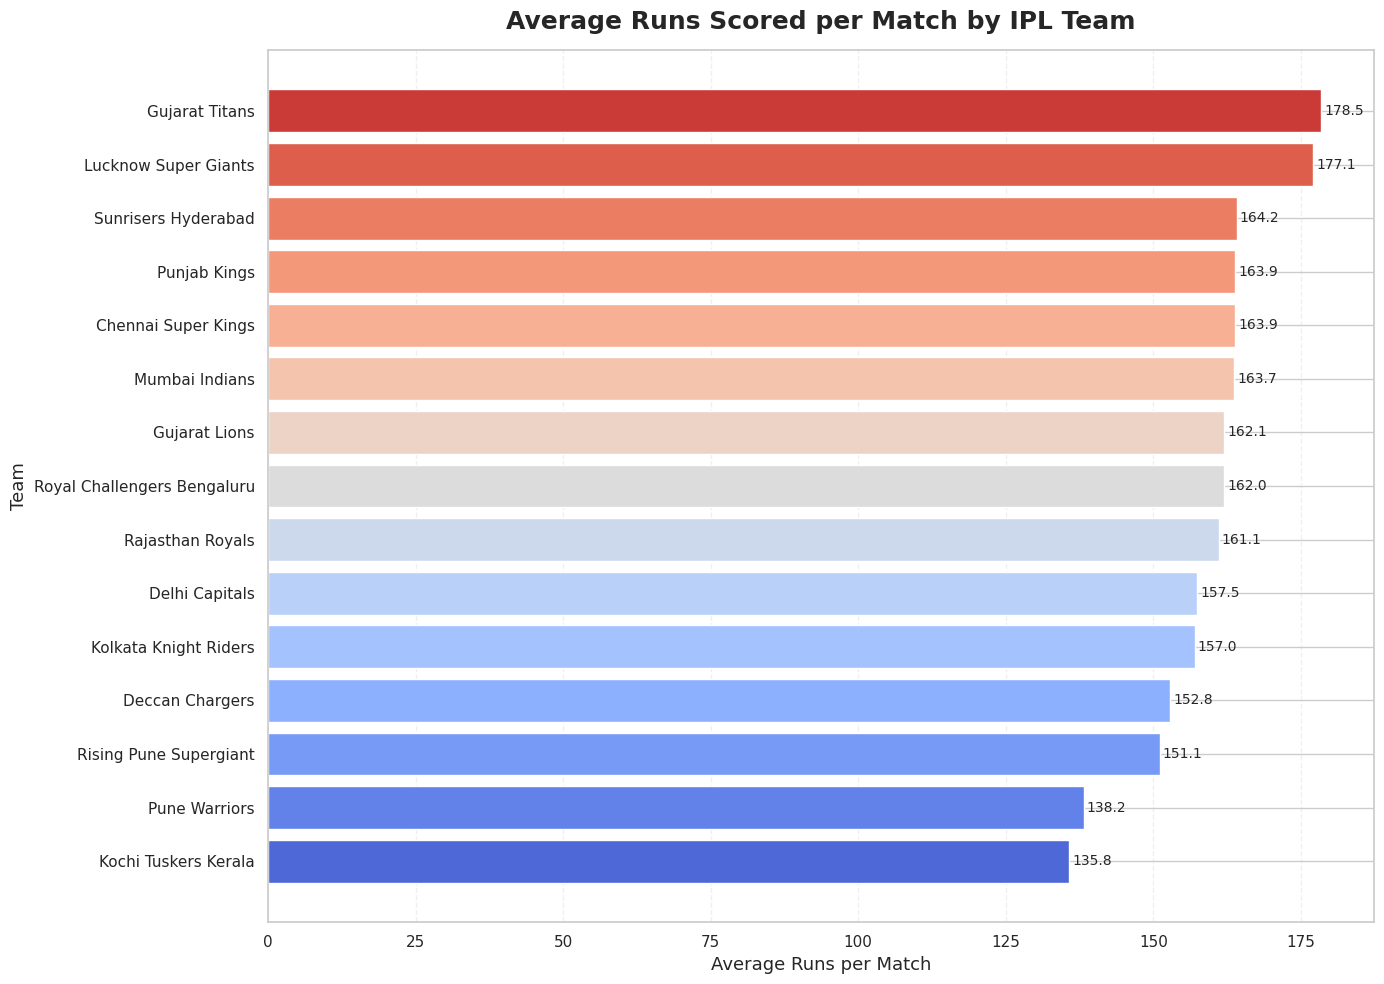

In [ ]:
# STEP 68: Team-wise average scoring visualization

plot_data = (
    team_scoring_summary
    .sort_values("Average_Runs_Per_Match", ascending=True)
)

plt.figure(figsize=(14, 10))

bars = plt.barh(
    plot_data["Team"],
    plot_data["Average_Runs_Per_Match"],
    color=sns.color_palette("coolwarm", len(plot_data))
)

# Add average values to bars
for bar, value in zip(
    bars,
    plot_data["Average_Runs_Per_Match"]
):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Average Runs Scored per Match by IPL Team",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Average Runs per Match",
    fontsize=13
)

plt.ylabel(
    "Team",
    fontsize=13
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 69: Generate key statistical insights

# Overall statistics
total_matches = len(ipl_clean)

total_seasons = ipl_clean["season_year"].nunique()

total_teams = len(
    pd.unique(
        pd.concat([
            ipl_clean["team1"],
            ipl_clean["team2"]
        ])
    )
)

total_venues = ipl_clean["venue"].nunique()

# Most frequently used venue
most_used_venue = venue_analysis.iloc[0]

# Most Player of the Match awards
top_pom = pom_data.iloc[0]

# Most frequent result type
most_common_result = result_type_counts.iloc[0]

# Average runs per match
overall_avg_runs = ipl_clean["total_match_runs"].mean()

# Toss analysis
toss_overall = (
    toss_result_analysis["Toss_Match_Result"]
    .value_counts(normalize=True)
    * 100
)

toss_winner_win_pct = round(
    toss_overall.get("Toss Winner Won", 0),
    2
)

# Highest average team scoring
highest_scoring_team = team_scoring_summary.iloc[0]

# Create summary table
key_statistics = pd.DataFrame({
    "Metric": [
        "Total Matches",
        "Total Seasons",
        "Total Teams",
        "Total Venues",
        "Most Used Venue",
        "Most Common Result Type",
        "Overall Average Runs per Match",
        "Toss Winner Match Win %",
        "Most Player of the Match Awards",
        "Highest Average Team Runs per Match"
    ],

    "Value": [
        total_matches,
        total_seasons,
        total_teams,
        total_venues,
        f"{most_used_venue['Venue']} ({most_used_venue['Matches']} matches)",
        f"{most_common_result['Result_Type']} ({most_common_result['Matches']} matches)",
        round(overall_avg_runs, 2),
        f"{toss_winner_win_pct}%",
        f"{top_pom['player_of_match']} ({top_pom['Awards']} awards)",
        f"{highest_scoring_team['Team']} ({highest_scoring_team['Average_Runs_Per_Match']:.2f})"
    ]
})

display(key_statistics)

,Metric,Value
0,Total Matches,1243
1,Total Seasons,19
2,Total Teams,15
3,Total Venues,60
4,Most Used Venue,Eden Gardens (77 matches)
5,Most Common Result Type,Win by Wickets (660 matches)
6,Overall Average Runs per Match,323.2
7,Toss Winner Match Win %,50.52%
8,Most Player of the Match Awards,AB de Villiers (25 awards)
9,Highest Average Team Runs per Match,Gujarat Titans (178.48)


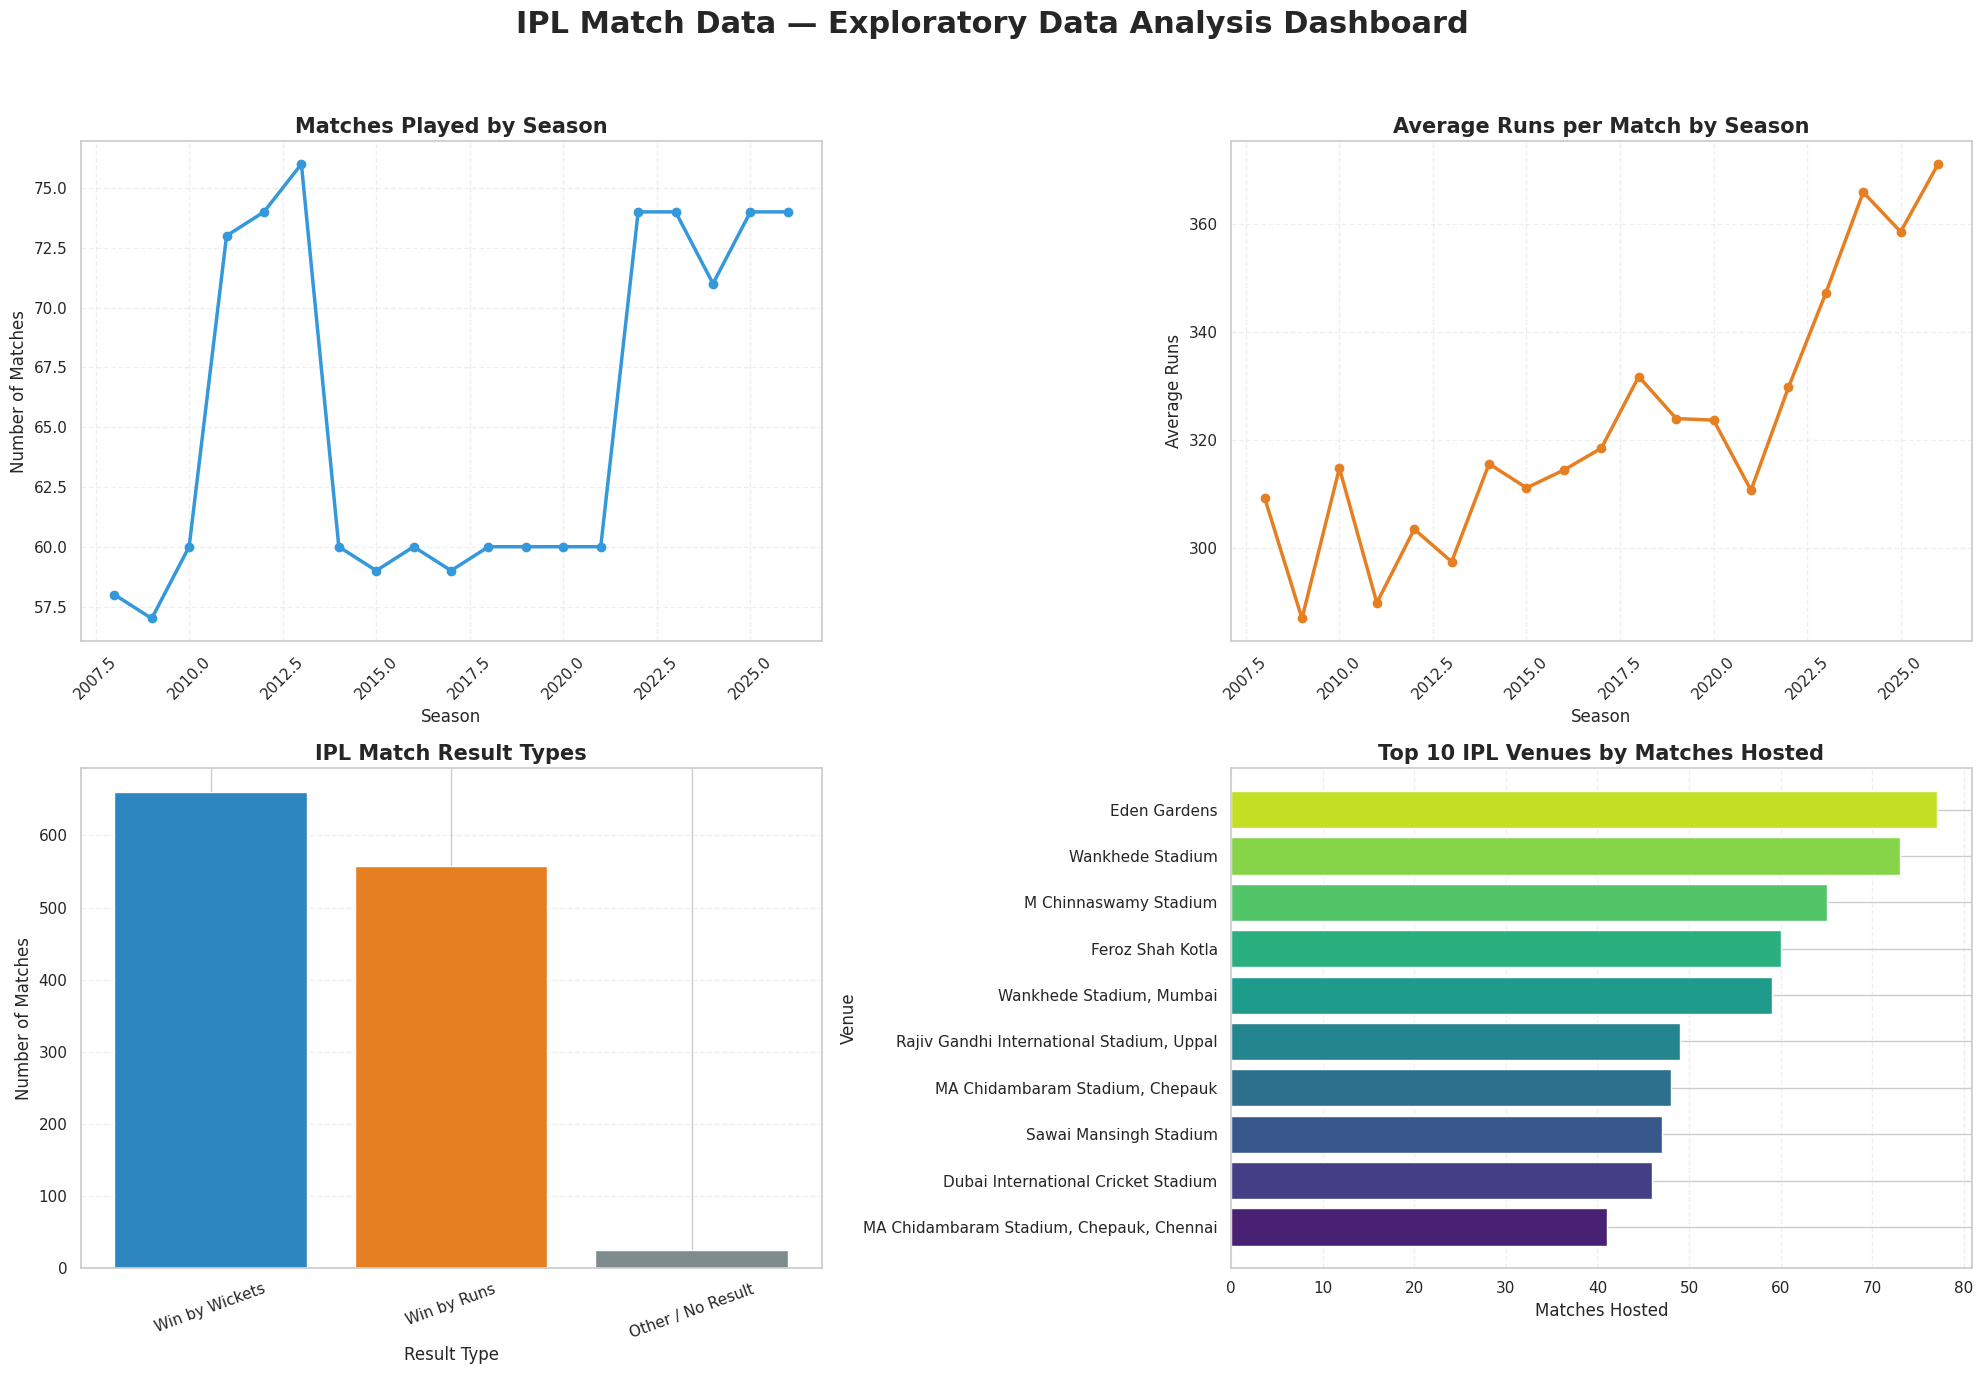

In [ ]:
# STEP 70: Final IPL EDA Dashboard

fig = plt.figure(figsize=(20, 14))

# ------------------------------------------------
# 1. Matches by Season
# ------------------------------------------------
ax1 = plt.subplot(2, 2, 1)

ax1.plot(
    season_scoring["season_year"],
    season_scoring["Matches"],
    marker="o",
    linewidth=2.5,
    color="#3498DB"
)

ax1.set_title(
    "Matches Played by Season",
    fontsize=15,
    fontweight="bold"
)

ax1.set_xlabel("Season")
ax1.set_ylabel("Number of Matches")

ax1.grid(
    linestyle="--",
    alpha=0.3
)

ax1.tick_params(axis="x", rotation=45)


# ------------------------------------------------
# 2. Average Runs per Match
# ------------------------------------------------
ax2 = plt.subplot(2, 2, 2)

ax2.plot(
    season_scoring["season_year"],
    season_scoring["Average_Runs_Per_Match"],
    marker="o",
    linewidth=2.5,
    color="#E67E22"
)

ax2.set_title(
    "Average Runs per Match by Season",
    fontsize=15,
    fontweight="bold"
)

ax2.set_xlabel("Season")
ax2.set_ylabel("Average Runs")

ax2.grid(
    linestyle="--",
    alpha=0.3
)

ax2.tick_params(axis="x", rotation=45)


# ------------------------------------------------
# 3. Match Result Types
# ------------------------------------------------
ax3 = plt.subplot(2, 2, 3)

result_plot = result_type_counts.copy()

ax3.bar(
    result_plot["Result_Type"],
    result_plot["Matches"],
    color=["#2E86C1", "#E67E22", "#7F8C8D"]
)

ax3.set_title(
    "IPL Match Result Types",
    fontsize=15,
    fontweight="bold"
)

ax3.set_xlabel("Result Type")
ax3.set_ylabel("Number of Matches")

ax3.tick_params(axis="x", rotation=20)

ax3.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


# ------------------------------------------------
# 4. Top 10 Venues
# ------------------------------------------------
ax4 = plt.subplot(2, 2, 4)

top10_venues = (
    venue_analysis
    .head(10)
    .sort_values("Matches", ascending=True)
)

ax4.barh(
    top10_venues["Venue"],
    top10_venues["Matches"],
    color=sns.color_palette(
        "viridis",
        len(top10_venues)
    )
)

ax4.set_title(
    "Top 10 IPL Venues by Matches Hosted",
    fontsize=15,
    fontweight="bold"
)

ax4.set_xlabel("Matches Hosted")
ax4.set_ylabel("Venue")

ax4.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)


# ------------------------------------------------
# Dashboard title
# ------------------------------------------------
fig.suptitle(
    "IPL Match Data — Exploratory Data Analysis Dashboard",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

In [ ]:
# ============================================================
# IPL DATA ANALYSIS — ADVANCED INTERACTIVE DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------

# Make sure total match runs exist
ipl_clean["total_match_runs"] = (
    ipl_clean["team1_runs"].fillna(0)
    + ipl_clean["team2_runs"].fillna(0)
)

# ------------------------------------------------------------
# Season statistics
# ------------------------------------------------------------

season_stats = (
    ipl_clean
    .groupby("season_year")
    .agg(
        Matches=("season_year", "size"),
        Total_Runs=("total_match_runs", "sum"),
        Average_Runs=("total_match_runs", "mean")
    )
    .reset_index()
)

season_stats["Average_Runs"] = season_stats["Average_Runs"].round(2)


# ------------------------------------------------------------
# Team wins
# ------------------------------------------------------------

team_wins = (
    ipl_clean[
        ipl_clean["winner"] != "No Winner"
    ]["winner"]
    .value_counts()
    .reset_index()
)

team_wins.columns = ["Team", "Wins"]


# ------------------------------------------------------------
# Team performance
# ------------------------------------------------------------

team_performance_dashboard = pd.concat([
    ipl_clean[["team1", "winner"]].rename(
        columns={"team1": "Team"}
    ),
    ipl_clean[["team2", "winner"]].rename(
        columns={"team2": "Team"}
    )
], ignore_index=True)

team_summary = (
    team_performance_dashboard
    .groupby("Team")
    .agg(
        Matches=("Team", "size"),
        Wins=("winner", lambda x: (
            x == team_performance_dashboard.loc[x.index, "Team"]
        ).sum())
    )
    .reset_index()
)

team_summary["Win_Percentage"] = (
    team_summary["Wins"]
    / team_summary["Matches"]
    * 100
).round(2)


# ------------------------------------------------------------
# Toss analysis
# ------------------------------------------------------------

toss_data = ipl_clean[
    ipl_clean["winner"] != "No Winner"
].copy()

toss_data["Toss_Winner_Won"] = (
    toss_data["toss_winner"] == toss_data["winner"]
)

toss_decision_counts = (
    ipl_clean["toss_decision"]
    .value_counts()
    .reset_index()
)

toss_decision_counts.columns = [
    "Decision",
    "Matches"
]

toss_success = (
    toss_data["Toss_Winner_Won"]
    .value_counts()
    .rename(index={
        True: "Toss Winner Won",
        False: "Toss Winner Lost"
    })
    .reset_index()
)

toss_success.columns = [
    "Result",
    "Matches"
]


# ------------------------------------------------------------
# Result type
# ------------------------------------------------------------

result_counts = (
    ipl_clean["result_category"]
    .value_counts()
    .reset_index()
)

result_counts.columns = [
    "Result",
    "Matches"
]


# ------------------------------------------------------------
# Player of Match
# ------------------------------------------------------------

pom_dashboard = (
    ipl_clean[
        ipl_clean["player_of_match"] != "Not Awarded"
    ]["player_of_match"]
    .value_counts()
    .head(10)
    .reset_index()
)

pom_dashboard.columns = [
    "Player",
    "Awards"
]


# ------------------------------------------------------------
# Venue
# ------------------------------------------------------------

venue_dashboard = (
    ipl_clean["venue"]
    .value_counts()
    .head(10)
    .reset_index()
)

venue_dashboard.columns = [
    "Venue",
    "Matches"
]


# ------------------------------------------------------------
# Win margin
# ------------------------------------------------------------

run_margins = ipl_clean[
    ipl_clean["win_by_runs"] > 0
]["win_by_runs"].dropna()

wicket_margins = ipl_clean[
    ipl_clean["win_by_wickets"] > 0
]["win_by_wickets"].dropna()


# ------------------------------------------------------------
# Match stage
# ------------------------------------------------------------

stage_counts = (
    ipl_clean["match_stage"]
    .value_counts()
    .reset_index()
)

stage_counts.columns = [
    "Stage",
    "Matches"
]


# ============================================================
# DASHBOARD
# ============================================================

fig = make_subplots(

    rows=5,
    cols=4,

    specs=[

        # KPI row
        [
            {"type": "indicator"},
            {"type": "indicator"},
            {"type": "indicator"},
            {"type": "indicator"}
        ],

        # Row 2
        [
            {"type": "xy", "colspan": 2},
            None,
            {"type": "xy", "colspan": 2},
            None
        ],

        # Row 3
        [
            {"type": "xy"},
            {"type": "xy"},
            {"type": "domain"},
            {"type": "domain"}
        ],

        # Row 4
        [
            {"type": "xy", "colspan": 2},
            None,
            {"type": "xy", "colspan": 2},
            None
        ],

        # Row 5
        [
            {"type": "xy"},
            {"type": "xy"},
            {"type": "domain"},
            {"type": "xy"}
        ]
    ],

    vertical_spacing=0.07,
    horizontal_spacing=0.04
)


# ============================================================
# KPI CARDS
# ============================================================

total_matches = len(ipl_clean)

total_seasons = ipl_clean["season_year"].nunique()

total_teams = len(
    pd.unique(
        pd.concat([
            ipl_clean["team1"],
            ipl_clean["team2"]
        ])
    )
)

total_venues = ipl_clean["venue"].nunique()


fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_matches,
        title={"text": "🏏<br><b>Total Matches</b>"},
        number={"font": {"size": 30}}
    ),
    row=1, col=1
)

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_seasons,
        title={"text": "📅<br><b>Seasons</b>"},
        number={"font": {"size": 30}}
    ),
    row=1, col=2
)

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_teams,
        title={"text": "👥<br><b>Teams</b>"},
        number={"font": {"size": 30}}
    ),
    row=1, col=3
)

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_venues,
        title={"text": "🏟️<br><b>Venues</b>"},
        number={"font": {"size": 30}}
    ),
    row=1, col=4
)


# ============================================================
# ROW 2 — SEASON TRENDS
# ============================================================

# Matches by season
fig.add_trace(
    go.Scatter(
        x=season_stats["season_year"],
        y=season_stats["Matches"],
        mode="lines+markers",
        line=dict(width=3, color="#00D4FF"),
        marker=dict(size=7),
        hovertemplate=
            "Season: %{x}<br>"
            "Matches: %{y}<extra></extra>",
        name="Matches"
    ),
    row=2, col=1
)


# Average runs
fig.add_trace(
    go.Scatter(
        x=season_stats["season_year"],
        y=season_stats["Average_Runs"],
        mode="lines+markers",
        line=dict(width=3, color="#FFB000"),
        marker=dict(size=7),
        hovertemplate=
            "Season: %{x}<br>"
            "Average Runs: %{y:.2f}<extra></extra>",
        name="Average Runs"
    ),
    row=2, col=3
)


# ============================================================
# ROW 3 — TEAM / TOSS / RESULT
# ============================================================

# Team wins
top_team_wins = team_wins.head(10).sort_values("Wins")

fig.add_trace(
    go.Bar(
        x=top_team_wins["Wins"],
        y=top_team_wins["Team"],
        orientation="h",
        marker=dict(
            color=top_team_wins["Wins"],
            colorscale="Turbo"
        ),
        text=top_team_wins["Wins"],
        textposition="outside",
        hovertemplate=
            "%{y}<br>"
            "Wins: %{x}<extra></extra>",
        name="Team Wins"
    ),
    row=3, col=1
)


# Win percentage
top_win_pct = (
    team_summary
    .sort_values("Win_Percentage", ascending=False)
    .head(10)
    .sort_values("Win_Percentage")
)

fig.add_trace(
    go.Bar(
        x=top_win_pct["Win_Percentage"],
        y=top_win_pct["Team"],
        orientation="h",
        marker=dict(
            color=top_win_pct["Win_Percentage"],
            colorscale="Plasma"
        ),
        text=top_win_pct["Win_Percentage"].round(1),
        textposition="outside",
        hovertemplate=
            "%{y}<br>"
            "Win %: %{x:.2f}%%<br>"
            "Matches: %{customdata}<extra></extra>",
        customdata=top_win_pct["Matches"],
        name="Win Percentage"
    ),
    row=3, col=2
)


# Toss decision donut
fig.add_trace(
    go.Pie(
        labels=toss_decision_counts["Decision"],
        values=toss_decision_counts["Matches"],
        hole=0.60,
        textinfo="percent",
        hovertemplate=
            "%{label}<br>"
            "Matches: %{value}<br>"
            "%{percent}<extra></extra>",
        marker=dict(
            colors=["#FF6B35", "#4DA3FF"]
        ),
        name="Toss Decision"
    ),
    row=3, col=3
)


# Result type donut
fig.add_trace(
    go.Pie(
        labels=result_counts["Result"],
        values=result_counts["Matches"],
        hole=0.60,
        textinfo="percent",
        hovertemplate=
            "%{label}<br>"
            "Matches: %{value}<br>"
            "%{percent}<extra></extra>",
        marker=dict(
            colors=[
                "#00C896",
                "#FFB000",
                "#8E9AAF"
            ]
        ),
        name="Result Type"
    ),
    row=3, col=4
)


# ============================================================
# ROW 4 — PLAYER + VENUE
# ============================================================

# Player of Match
pom_plot = pom_dashboard.sort_values("Awards")

fig.add_trace(
    go.Bar(
        x=pom_plot["Awards"],
        y=pom_plot["Player"],
        orientation="h",
        marker=dict(
            color=pom_plot["Awards"],
            colorscale="Sunset"
        ),
        text=pom_plot["Awards"],
        textposition="outside",
        hovertemplate=
            "%{y}<br>"
            "Awards: %{x}<extra></extra>",
        name="Player Awards"
    ),
    row=4, col=1
)


# Venues
venue_plot = venue_dashboard.sort_values("Matches")

fig.add_trace(
    go.Bar(
        x=venue_plot["Matches"],
        y=venue_plot["Venue"],
        orientation="h",
        marker=dict(
            color=venue_plot["Matches"],
            colorscale="Viridis"
        ),
        text=venue_plot["Matches"],
        textposition="outside",
        hovertemplate=
            "%{y}<br>"
            "Matches: %{x}<extra></extra>",
        name="Venue Matches"
    ),
    row=4, col=3
)


# ============================================================
# ROW 5 — MORE ANALYSIS
# ============================================================

# Run margin distribution
fig.add_trace(
    go.Histogram(
        x=run_margins,
        nbinsx=25,
        marker_color="#00D4FF",
        opacity=0.85,
        hovertemplate=
            "Run Margin: %{x}<br>"
            "Matches: %{y}<extra></extra>",
        name="Run Margins"
    ),
    row=5, col=1
)


# Wicket margin distribution
fig.add_trace(
    go.Histogram(
        x=wicket_margins,
        xbins=dict(
            start=0.5,
            end=10.5,
            size=1
        ),
        marker_color="#FF6B35",
        opacity=0.85,
        hovertemplate=
            "Wicket Margin: %{x}<br>"
            "Matches: %{y}<extra></extra>",
        name="Wicket Margins"
    ),
    row=5, col=2
)


# Match stage
fig.add_trace(
    go.Pie(
        labels=stage_counts["Stage"],
        values=stage_counts["Matches"],
        hole=0.55,
        textinfo="percent",
        marker=dict(
            colors=["#4DA3FF", "#FFB000"]
        ),
        hovertemplate=
            "%{label}<br>"
            "Matches: %{value}<br>"
            "%{percent}<extra></extra>",
        name="Match Stage"
    ),
    row=5, col=3
)


# Average scoring by team
top_scoring = (
    team_scoring_summary
    .sort_values(
        "Average_Runs_Per_Match",
        ascending=False
    )
    .head(10)
    .sort_values(
        "Average_Runs_Per_Match"
    )
)

fig.add_trace(
    go.Bar(
        x=top_scoring["Average_Runs_Per_Match"],
        y=top_scoring["Team"],
        orientation="h",
        marker=dict(
            color=top_scoring["Average_Runs_Per_Match"],
            colorscale="RdYlBu"
        ),
        text=top_scoring["Average_Runs_Per_Match"].round(1),
        textposition="outside",
        hovertemplate=
            "%{y}<br>"
            "Average Runs: %{x:.2f}<extra></extra>",
        name="Average Scoring"
    ),
    row=5, col=4
)


# ============================================================
# TITLES
# ============================================================

fig.update_xaxes(
    title_text="Season",
    row=2, col=1
)

fig.update_yaxes(
    title_text="Matches",
    row=2, col=1
)

fig.update_xaxes(
    title_text="Season",
    row=2, col=3
)

fig.update_yaxes(
    title_text="Average Runs",
    row=2, col=3
)


# ============================================================
# DASHBOARD SECTION TITLES
# ============================================================

fig.add_annotation(
    text="<b>SEASON TRENDS</b>",
    x=0.01, y=0.805,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=13, color="#00D4FF")
)

fig.add_annotation(
    text="<b>TEAM & TOSS ANALYSIS</b>",
    x=0.01, y=0.585,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=13, color="#FFB000")
)

fig.add_annotation(
    text="<b>PLAYER & VENUE ANALYSIS</b>",
    x=0.01, y=0.365,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=13, color="#00C896")
)

fig.add_annotation(
    text="<b>MATCH CHARACTERISTICS</b>",
    x=0.01, y=0.165,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=13, color="#FF6B35")
)


# ============================================================
# LAYOUT
# ============================================================

fig.update_layout(

    title=dict(
        text=(
            "🏏 <b>IPL DATA ANALYSIS DASHBOARD</b>"
            "<br><sup>2008–2026 | Interactive Exploratory Data Analysis</sup>"
        ),
        x=0.5,
        xanchor="center",
        font=dict(
            size=27,
            color="white"
        )
    ),

    height=1500,

    paper_bgcolor="#061B33",
    plot_bgcolor="#082F57",

    font=dict(
        family="Arial",
        color="white",
        size=11
    ),

    margin=dict(
        l=50,
        r=50,
        t=110,
        b=50
    ),

    showlegend=False,

    hoverlabel=dict(
        bgcolor="#102A43",
        font_size=13,
        font_color="white"
    )
)


# ============================================================
# AXIS STYLING
# ============================================================

fig.update_xaxes(
    showgrid=True,
    gridcolor="rgba(255,255,255,0.08)",
    zeroline=False,
    tickfont=dict(color="#DCE6F1")
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    tickfont=dict(color="#DCE6F1")
)


# ============================================================
# SHOW DASHBOARD
# ============================================================

fig.show()
